In [1]:
pip install openai pandas

   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   ---------------------------------------- 1.1/1.1 MB 7.4 MB/s eta 0:00:00

   -------------------- ------------------- 1/2 [openai]
   -------------------- ------------------- 1/2 [openai]
   -------------------- ------------------- 1/2 [openai]
   -------------------- ------------------- 1/2 [openai]
   -------------------- ------------------- 1/2 [openai]
   -------------------- ------------------- 1/2 [openai]
   -------------------- ------------------- 1/2 [openai]
   -------------------- ------------------- 1/2 [openai]
   -------------------- ------------------- 1/2 [openai]
   -------------------- ------------------- 1/2 [openai]
   -------------------- ------------------- 1/2 [openai]
   -------------------- ------------------- 1/2 [openai]
   -------------------- ------------------- 1/2 [openai]
   -------------------- ------------------- 1/2 [openai]
   -------------------- ------------------- 1/2 [openai]

# LIGHT MODELS

# TEMP 0

## openAI

### blank

In [3]:
# !pip install openai pandas python-dotenv  # uncomment and run once

import os, re, time
import pandas as pd
from openai import OpenAI
from dotenv import load_dotenv

BASE_DIR = r"C:\Users\Admin\OneDrive - Université Libre de Bruxelles\Leo\Insta\UMONS\svet paper"

load_dotenv(os.path.join(BASE_DIR, ".env"))
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
print("Client ready ✓")

Client ready ✓


In [4]:
QUIZ_PATH = os.path.join(BASE_DIR, "SVET QUIZ.txt")

def parse_quiz(path):
    with open(path, "r", encoding="utf-8") as f:
        text = f.read()

    questions = []
    blocks = re.split(r'\n(?=\d{1,2}\.)', text)

    for block in blocks:
        block = block.strip()
        if not block:
            continue

        q_match   = re.match(r'^(\d{1,2})\.\s+(.*?)(?=\nA\.)', block, re.DOTALL)
        a_match   = re.search(r'A\.\s+(.*?)(?=\nB\.)',          block, re.DOTALL)
        b_match   = re.search(r'B\.\s+(.*?)(?=\nC\.)',          block, re.DOTALL)
        c_match   = re.search(r'C\.\s+(.*?)(?=\nCorrect:)',      block, re.DOTALL)
        ans_match = re.search(r'Correct:\s*([ABC])',             block)

        if not all([q_match, a_match, b_match, c_match, ans_match]):
            print(f"⚠️  Skipped block — parsing issue")
            continue

        questions.append({
            "question_id"    : int(q_match.group(1)),
            "question_text"  : q_match.group(2).strip().replace('\n', ' '),
            "option_a"       : a_match.group(1).strip(),
            "option_b"       : b_match.group(1).strip(),
            "option_c"       : c_match.group(1).strip(),
            "correct_answer" : ans_match.group(1).strip()
        })

    return sorted(questions, key=lambda x: x["question_id"])

questions = parse_quiz(QUIZ_PATH)
print(f"Loaded {len(questions)} questions ✓")

# Sanity check — print first and last
for q in [questions[0], questions[-1]]:
    print(f"\nQ{q['question_id']}: {q['question_text'][:60]}...")
    print(f"  A) {q['option_a']}")
    print(f"  B) {q['option_b']}")
    print(f"  C) {q['option_c']}")
    print(f"  ✓  {q['correct_answer']}")

⚠️  Skipped block — parsing issue
Loaded 50 questions ✓

Q1: What does the SVET probe primarily measure above a sample su...
  A) Local pH changes
  B) Local ionic current density
  C) Bulk electrolyte resistance
  ✓  B

Q50: Which sample types particularly benefit from SVET because th...
  A) Galvanized steel plates
  B) Naturally active or biological samples
  C) Polished alloys with low noise
  ✓  B


In [5]:
SYSTEM_PROMPT = (
    "You are an expert in the Scanning Vibrating Electrode Technique (SVET), "
    "a specialized electrochemical characterization method used in corrosion research. "
    "Answer the following multiple-choice question by responding ONLY with the letter "
    "of the correct answer (A, B, or C). Do not explain your reasoning."
)

def build_user_prompt(q: dict) -> str:
    return (
        f"{q['question_text']}\n\n"
        f"A) {q['option_a']}\n"
        f"B) {q['option_b']}\n"
        f"C) {q['option_c']}\n\n"
        f"Answer:"
    )

def parse_answer(raw: str) -> str:
    match = re.search(r'\b([ABC])\b', raw.strip().upper())
    return match.group(1) if match else "PARSE_ERROR"

def query_openai(q: dict, model: str, temperature: float, run: int,
                 rag_condition: str = "RAG-", context: str = None) -> dict:

    system = SYSTEM_PROMPT
    if rag_condition == "RAG+" and context:
        system += f"\n\nRelevant context:\n{context}"

    try:
        response = client.chat.completions.create(
            model       = model,
            temperature = temperature,
            max_tokens  = 10,
            messages    = [
                {"role": "system", "content": system},
                {"role": "user",   "content": build_user_prompt(q)}
            ]
        )
        raw = response.choices[0].message.content.strip()

    except Exception as e:
        raw = f"API_ERROR: {str(e)}"

    parsed = parse_answer(raw)

    return {
        "question_id"    : q["question_id"],
        "model_family"   : "openai",
        "model_version"  : model,
        "rag_condition"  : rag_condition,
        "temperature"    : temperature,
        "run_number"     : run,
        "raw_output"     : raw,
        "parsed_answer"  : parsed,
        "correct_answer" : q["correct_answer"],
        "is_correct"     : int(parsed == q["correct_answer"])
    }

print("Functions defined ✓")

Functions defined ✓


In [6]:
MODEL = "gpt-4o-mini"   # swap to "gpt-5-mini" once you confirm access on your key
TEMP  = 0.0

print(f"Model: {MODEL} | Temp: {TEMP} | Condition: RAG-\n")
print(f"{'Q':>3} | {'Parsed':>6} | {'Correct':>7} | {'OK':>4}")
print("-" * 28)

dry_results = []
for q in questions[:5]:
    row = query_openai(q, MODEL, TEMP, run=1)
    dry_results.append(row)
    mark = "✓" if row["is_correct"] else "✗"
    print(f"Q{row['question_id']:02d} | {row['parsed_answer']:>6} | {row['correct_answer']:>7} | {mark}")
    time.sleep(0.5)

acc = sum(r["is_correct"] for r in dry_results)
print(f"\nDry run: {acc}/5 correct")
print("\nRaw outputs:")
for r in dry_results:
    print(f"  Q{r['question_id']:02d}: '{r['raw_output']}'")

Model: gpt-4o-mini | Temp: 0.0 | Condition: RAG-

  Q | Parsed | Correct |   OK
----------------------------
Q01 |      B |       B | ✓
Q02 |      B |       B | ✓
Q03 |      B |       B | ✓
Q04 |      B |       B | ✓
Q05 |      C |       C | ✓

Dry run: 5/5 correct

Raw outputs:
  Q01: 'B'
  Q02: 'B'
  Q03: 'B'
  Q04: 'B'
  Q05: 'C'


In [7]:
# ✋ Only run after Cell 4 looks correct

OUTPUT_PATH = os.path.join(BASE_DIR, f"results_openai_{MODEL}_T0_RAGminus.csv")

print(f"Running {len(questions)} questions...\n")
all_results = []

for i, q in enumerate(questions):
    row = query_openai(q, MODEL, TEMP, run=1)
    all_results.append(row)
    mark = "✓" if row["is_correct"] else "✗"
    print(f"[{i+1:02d}/50] Q{row['question_id']:02d} | "
          f"parsed={row['parsed_answer']} | correct={row['correct_answer']} | {mark}")
    time.sleep(0.3)

df = pd.DataFrame(all_results)
df.to_csv(OUTPUT_PATH, index=False)

accuracy = df["is_correct"].mean() * 100
errors   = df[df["parsed_answer"] == "PARSE_ERROR"]

print(f"\n{'='*40}")
print(f"Model    : {MODEL}")
print(f"Condition: RAG-  |  Temp: {TEMP}")
print(f"Accuracy : {accuracy:.1f}%  ({df['is_correct'].sum()}/50 correct)")
print(f"Parse errors: {len(errors)}")
print(f"Saved → {OUTPUT_PATH}")

Running 50 questions...

[01/50] Q01 | parsed=B | correct=B | ✓
[02/50] Q02 | parsed=B | correct=B | ✓
[03/50] Q03 | parsed=B | correct=B | ✓
[04/50] Q04 | parsed=B | correct=B | ✓
[05/50] Q05 | parsed=C | correct=C | ✓
[06/50] Q06 | parsed=B | correct=B | ✓
[07/50] Q07 | parsed=A | correct=A | ✓
[08/50] Q08 | parsed=B | correct=C | ✗
[09/50] Q09 | parsed=B | correct=B | ✓
[10/50] Q10 | parsed=B | correct=B | ✓
[11/50] Q11 | parsed=B | correct=B | ✓
[12/50] Q12 | parsed=B | correct=B | ✓
[13/50] Q13 | parsed=C | correct=C | ✓
[14/50] Q14 | parsed=B | correct=B | ✓
[15/50] Q15 | parsed=B | correct=B | ✓
[16/50] Q16 | parsed=C | correct=C | ✓
[17/50] Q17 | parsed=B | correct=B | ✓
[18/50] Q18 | parsed=B | correct=B | ✓
[19/50] Q19 | parsed=B | correct=B | ✓
[20/50] Q20 | parsed=C | correct=C | ✓
[21/50] Q21 | parsed=B | correct=B | ✓
[22/50] Q22 | parsed=B | correct=B | ✓
[23/50] Q23 | parsed=A | correct=A | ✓
[24/50] Q24 | parsed=B | correct=B | ✓
[25/50] Q25 | parsed=B | correct=B | ✓


In [8]:
RUN_NUMBER  = 2
OUTPUT_PATH = os.path.join(BASE_DIR, f"results_openai_{MODEL}_T0_RAGminus.csv")

# Load run 1 already saved
df_existing = pd.read_csv(OUTPUT_PATH)
print(f"Loaded {len(df_existing)} rows from Run 1 ✓\n")

print(f"Running Run {RUN_NUMBER}...\n")
run2_results = []

for i, q in enumerate(questions):
    row = query_openai(q, MODEL, TEMP, run=RUN_NUMBER)
    run2_results.append(row)
    mark = "✓" if row["is_correct"] else "✗"
    print(f"[{i+1:02d}/50] Q{row['question_id']:02d} | "
          f"parsed={row['parsed_answer']} | correct={row['correct_answer']} | {mark}")
    time.sleep(0.3)

# Append and save
df_all = pd.concat([df_existing, pd.DataFrame(run2_results)], ignore_index=True)
df_all.to_csv(OUTPUT_PATH, index=False)

acc2 = sum(r["is_correct"] for r in run2_results) / len(run2_results) * 100
print(f"\nRun 2 accuracy : {acc2:.1f}%")
print(f"Total rows saved: {len(df_all)}")
print(f"Saved → {OUTPUT_PATH}")

Loaded 50 rows from Run 1 ✓

Running Run 2...

[01/50] Q01 | parsed=B | correct=B | ✓
[02/50] Q02 | parsed=B | correct=B | ✓
[03/50] Q03 | parsed=B | correct=B | ✓
[04/50] Q04 | parsed=B | correct=B | ✓
[05/50] Q05 | parsed=C | correct=C | ✓
[06/50] Q06 | parsed=B | correct=B | ✓
[07/50] Q07 | parsed=A | correct=A | ✓
[08/50] Q08 | parsed=C | correct=C | ✓
[09/50] Q09 | parsed=B | correct=B | ✓
[10/50] Q10 | parsed=B | correct=B | ✓
[11/50] Q11 | parsed=B | correct=B | ✓
[12/50] Q12 | parsed=B | correct=B | ✓
[13/50] Q13 | parsed=C | correct=C | ✓
[14/50] Q14 | parsed=B | correct=B | ✓
[15/50] Q15 | parsed=B | correct=B | ✓
[16/50] Q16 | parsed=C | correct=C | ✓
[17/50] Q17 | parsed=B | correct=B | ✓
[18/50] Q18 | parsed=B | correct=B | ✓
[19/50] Q19 | parsed=B | correct=B | ✓
[20/50] Q20 | parsed=C | correct=C | ✓
[21/50] Q21 | parsed=B | correct=B | ✓
[22/50] Q22 | parsed=B | correct=B | ✓
[23/50] Q23 | parsed=A | correct=A | ✓
[24/50] Q24 | parsed=B | correct=B | ✓
[25/50] Q25 | par

In [9]:
df_all = pd.read_csv(OUTPUT_PATH)

# Accuracy per run
per_run = (
    df_all.groupby("run_number")["is_correct"]
    .agg(accuracy=lambda x: round(x.mean() * 100, 1),
         correct=  lambda x: x.sum(),
         total=    lambda x: len(x))
    .reset_index()
)
print("─── Accuracy per run ───")
print(per_run.to_string(index=False))

# Mean ± SD across runs
accuracies = per_run["accuracy"].values
mean_acc   = accuracies.mean()
std_acc    = accuracies.std(ddof=1)   # ddof=1 = sample std

print(f"\n─── Summary ({len(per_run)} runs) ───")
print(f"Model     : {MODEL}")
print(f"Condition : RAG-  |  Temp: {TEMP}")
print(f"Accuracy  : {mean_acc:.1f}% ± {std_acc:.1f}%")
print(f"Range     : {accuracies.min():.1f}% – {accuracies.max():.1f}%")

# Per-question consistency: how often was each Q answered correctly across runs
q_consistency = (
    df_all.groupby("question_id")["is_correct"]
    .agg(times_correct="sum", runs="count")
    .reset_index()
)
always_wrong  = q_consistency[q_consistency["times_correct"] == 0]
always_right  = q_consistency[q_consistency["times_correct"] == q_consistency["runs"]]
inconsistent  = q_consistency[(q_consistency["times_correct"] > 0) & 
                               (q_consistency["times_correct"] < q_consistency["runs"])]

print(f"\n─── Per-question consistency ───")
print(f"Always correct  : {len(always_right)} questions")
print(f"Always wrong    : {len(always_wrong)} questions  ← {list(always_wrong['question_id'].values)}")
print(f"Inconsistent    : {len(inconsistent)} questions  ← {list(inconsistent['question_id'].values)}")

─── Accuracy per run ───
 run_number  accuracy  correct  total
          1      82.0       41     50
          2      86.0       43     50

─── Summary (2 runs) ───
Model     : gpt-4o-mini
Condition : RAG-  |  Temp: 0.0
Accuracy  : 84.0% ± 2.8%
Range     : 82.0% – 86.0%

─── Per-question consistency ───
Always correct  : 41 questions
Always wrong    : 7 questions  ← [np.int64(26), np.int64(29), np.int64(39), np.int64(41), np.int64(43), np.int64(45), np.int64(47)]
Inconsistent    : 2 questions  ← [np.int64(8), np.int64(36)]


In [10]:
RUN_NUMBER  = 3
OUTPUT_PATH = os.path.join(BASE_DIR, f"results_openai_{MODEL}_T0_RAGminus.csv")

df_existing = pd.read_csv(OUTPUT_PATH)
print(f"Loaded {len(df_existing)} rows (Runs 1+2) ✓\n")

run3_results = []

for i, q in enumerate(questions):
    row = query_openai(q, MODEL, TEMP, run=RUN_NUMBER)
    run3_results.append(row)
    mark = "✓" if row["is_correct"] else "✗"
    print(f"[{i+1:02d}/50] Q{row['question_id']:02d} | "
          f"parsed={row['parsed_answer']} | correct={row['correct_answer']} | {mark}")
    time.sleep(0.3)

df_all = pd.concat([df_existing, pd.DataFrame(run3_results)], ignore_index=True)
df_all.to_csv(OUTPUT_PATH, index=False)

acc3 = sum(r["is_correct"] for r in run3_results) / len(run3_results) * 100
print(f"\nRun 3 accuracy : {acc3:.1f}%")
print(f"Total rows saved: {len(df_all)}  (should be 150)")
print(f"Saved → {OUTPUT_PATH}")

Loaded 100 rows (Runs 1+2) ✓

[01/50] Q01 | parsed=B | correct=B | ✓
[02/50] Q02 | parsed=B | correct=B | ✓
[03/50] Q03 | parsed=B | correct=B | ✓
[04/50] Q04 | parsed=B | correct=B | ✓
[05/50] Q05 | parsed=C | correct=C | ✓
[06/50] Q06 | parsed=B | correct=B | ✓
[07/50] Q07 | parsed=A | correct=A | ✓
[08/50] Q08 | parsed=C | correct=C | ✓
[09/50] Q09 | parsed=B | correct=B | ✓
[10/50] Q10 | parsed=B | correct=B | ✓
[11/50] Q11 | parsed=B | correct=B | ✓
[12/50] Q12 | parsed=B | correct=B | ✓
[13/50] Q13 | parsed=C | correct=C | ✓
[14/50] Q14 | parsed=B | correct=B | ✓
[15/50] Q15 | parsed=B | correct=B | ✓
[16/50] Q16 | parsed=C | correct=C | ✓
[17/50] Q17 | parsed=B | correct=B | ✓
[18/50] Q18 | parsed=B | correct=B | ✓
[19/50] Q19 | parsed=B | correct=B | ✓
[20/50] Q20 | parsed=C | correct=C | ✓
[21/50] Q21 | parsed=B | correct=B | ✓
[22/50] Q22 | parsed=B | correct=B | ✓
[23/50] Q23 | parsed=A | correct=A | ✓
[24/50] Q24 | parsed=B | correct=B | ✓
[25/50] Q25 | parsed=B | correct=B

In [11]:
import numpy as np

df_all = pd.read_csv(OUTPUT_PATH)
assert len(df_all) == 150, f"Expected 150 rows, got {len(df_all)}"

# ── Per-run accuracy ──────────────────────────────────────────
per_run = (
    df_all.groupby("run_number")["is_correct"]
    .agg(
        correct = "sum",
        total   = "count",
        accuracy= lambda x: round(x.mean() * 100, 1)
    )
    .reset_index()
)

print("─── Accuracy per run ───────────────────────")
print(per_run.to_string(index=False))

# ── Mean ± SD across runs ─────────────────────────────────────
accs     = per_run["accuracy"].values
mean_acc = accs.mean()
std_acc  = accs.std(ddof=1)

print(f"\n─── Final result ────────────────────────────")
print(f"Model     : {MODEL}")
print(f"Condition : RAG−  |  Temp: {TEMP}  |  N runs: 3")
print(f"Accuracy  : {mean_acc:.1f}% ± {std_acc:.1f}%")
print(f"Range     : {accs.min():.1f}% – {accs.max():.1f}%")
print(f"Chance    : 33.3%  (3-option baseline)")
print(f"Δ chance  : +{mean_acc - 33.3:.1f} pp above random")

# ── Per-question consistency ──────────────────────────────────
q_stats = (
    df_all.groupby("question_id")["is_correct"]
    .agg(times_correct="sum", runs="count")
    .reset_index()
)
always_right = q_stats[q_stats["times_correct"] == 3]
always_wrong = q_stats[q_stats["times_correct"] == 0]
inconsistent = q_stats[(q_stats["times_correct"] > 0) &
                        (q_stats["times_correct"] < 3)]

print(f"\n─── Per-question consistency ────────────────")
print(f"Always correct (3/3) : {len(always_right)} Qs")
print(f"Always wrong   (0/3) : {len(always_wrong)} Qs → {sorted(always_wrong['question_id'].tolist())}")
print(f"Inconsistent         : {len(inconsistent)} Qs → {sorted(inconsistent['question_id'].tolist())}")

# ── Summary row (ready to paste into master results table) ────
print(f"\n─── Master table row ────────────────────────")
print(f"| {MODEL} | RAG− | {TEMP} | 3 | "
      f"{mean_acc:.1f}% ± {std_acc:.1f}% | "
      f"{len(always_right)} | {len(always_wrong)} | {len(inconsistent)} |")

─── Accuracy per run ───────────────────────
 run_number  correct  total  accuracy
          1       41     50      82.0
          2       43     50      86.0
          3       43     50      86.0

─── Final result ────────────────────────────
Model     : gpt-4o-mini
Condition : RAG−  |  Temp: 0.0  |  N runs: 3
Accuracy  : 84.7% ± 2.3%
Range     : 82.0% – 86.0%
Chance    : 33.3%  (3-option baseline)
Δ chance  : +51.4 pp above random

─── Per-question consistency ────────────────
Always correct (3/3) : 41 Qs
Always wrong   (0/3) : 7 Qs → [26, 29, 39, 41, 43, 45, 47]
Inconsistent         : 2 Qs → [8, 36]

─── Master table row ────────────────────────
| gpt-4o-mini | RAG− | 0.0 | 3 | 84.7% ± 2.3% | 41 | 7 | 2 |


### RAG

In [12]:
import json
import numpy as np
import urllib.request

GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")
KB_PATH        = os.path.join(BASE_DIR, "embeddings.json")



Knowledge base loaded ✓
  Chunks     : 146
  Dimensions : 768
Retriever ready ✓  (threshold=0.3, top_k=10)
Embedding model: text-embedding-004 (Google) — matches embeddings.json ✓
Generation model: gpt-4o-mini (OpenAI) — RAG+ context injected via system prompt


In [15]:
from dotenv import load_dotenv

# Force reload — picks up any keys added to .env after Cell 1 ran
load_dotenv(os.path.join(BASE_DIR, ".env"), override=True)

GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

print(f"OPENAI_API_KEY : {'✓ loaded' if OPENAI_API_KEY else '✗ MISSING'}")
print(f"GOOGLE_API_KEY : {'✓ loaded' if GOOGLE_API_KEY else '✗ MISSING'}")

# Rebuild the endpoint with the freshly loaded key
EMBED_ENDPOINT = (
    "https://generativelanguage.googleapis.com/v1beta/models/"
    f"text-embedding-004:embedContent?key={GOOGLE_API_KEY}"
)
print(f"\nEndpoint rebuilt ✓")

OPENAI_API_KEY : ✓ loaded
GOOGLE_API_KEY : ✓ loaded

Endpoint rebuilt ✓


In [19]:
!pip install google-genai --quiet

In [38]:
# Fix Cell B — Reload KB + updated retriever
with open(NEW_KB_PATH, "r", encoding="utf-8") as f:
    kb = json.load(f)

texts      = [chunk["text"]      for chunk in kb]
sources    = [chunk["source"]    for chunk in kb]
embeddings = np.array([chunk["embedding"] for chunk in kb], dtype=np.float32)

print(f"KB loaded ✓  |  chunks={len(texts)}  |  dim={embeddings.shape[1]}")

def embed_query(text: str) -> np.ndarray:
    result = gclient.models.embed_content(
        model    = "gemini-embedding-001",
        contents = text,
    )
    return np.array(result.embeddings[0].values, dtype=np.float32)

def cosine_similarity(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    a_norm = a / (np.linalg.norm(a) + 1e-10)
    b_norm = b / (np.linalg.norm(b, axis=1, keepdims=True) + 1e-10)
    return b_norm @ a_norm

SIMILARITY_THRESHOLD = 0.3
RAG_TOP_K            = 10

def retrieve(query: str) -> tuple[str, int]:
    q_emb  = embed_query(query)
    scores = cosine_similarity(q_emb, embeddings)
    above  = np.where(scores > SIMILARITY_THRESHOLD)[0]
    if len(above) == 0:
        return "", 0
    top_idx = above[np.argsort(scores[above])[::-1][:RAG_TOP_K]]
    chunks  = [f"[Source: {sources[i]}]\n{texts[i]}" for i in top_idx]
    return "\n\n---\n\n".join(chunks), len(top_idx)

# Quick test
ctx, n = retrieve(questions[0]["question_text"])
print(f"Retrieval test: '{questions[0]['question_text'][:55]}...'")
print(f"Chunks returned: {n}  (should be > 0)")
print(f"\nFirst 200 chars:\n{ctx[:200]}")

KB loaded ✓  |  chunks=146  |  dim=3072
Retrieval test: 'What does the SVET probe primarily measure above a samp...'
Chunks returned: 10  (should be > 0)

First 200 chars:
[Source: SVET Knowledge Base.txt]
compared to static probe techniques like SRET. ### Calibration and Quantification Quantitative analysis requires calibration using **Point Injection Source (PIS) cali


In [23]:
print(f"Model: {MODEL} | Temp: {TEMP} | Condition: RAG+\n")
print(f"{'Q':>3} | {'Chunks':>6} | {'Parsed':>6} | {'Correct':>7} | {'OK':>4}")
print("-" * 38)

dry_rag = []
for q in questions[:5]:
    context, n_chunks = retrieve(q["question_text"])
    row = query_openai(q, MODEL, TEMP, run=1, rag_condition="RAG+", context=context)
    dry_rag.append(row)
    mark = "✓" if row["is_correct"] else "✗"
    print(f"Q{row['question_id']:02d} | {n_chunks:>6} | {row['parsed_answer']:>6} | "
          f"{row['correct_answer']:>7} | {mark}")
    time.sleep(0.5)

print(f"\nDry run RAG+: {sum(r['is_correct'] for r in dry_rag)}/5 correct")
print("\n⚠️  If Chunks column shows 0 for most rows → threshold too strict, drop to 0.2")

Model: gpt-4o-mini | Temp: 0.0 | Condition: RAG+

  Q | Chunks | Parsed | Correct |   OK
--------------------------------------
Q01 |     10 |      B |       B | ✓
Q02 |     10 |      B |       B | ✓
Q03 |     10 |      B |       B | ✓
Q04 |     10 |      B |       B | ✓
Q05 |     10 |      C |       C | ✓

Dry run RAG+: 5/5 correct

⚠️  If Chunks column shows 0 for most rows → threshold too strict, drop to 0.2


In [25]:
RAG_OUTPUT_PATH = os.path.join(BASE_DIR,
                    f"results_openai_{MODEL}_T0_RAGplus.csv")

all_rag_results = []

for run_num in range(1, 4):
    print(f"\n── Run {run_num}/3 ──────────────────────────────")
    run_chunks = []
    for i, q in enumerate(questions):
        context, n_chunks = retrieve(q["question_text"])   # ← fixed
        run_chunks.append(n_chunks)
        row = query_openai(q, MODEL, TEMP, run=run_num,
                           rag_condition="RAG+", context=context)
        all_rag_results.append(row)
        mark = "✓" if row["is_correct"] else "✗"
        print(f"  [{i+1:02d}/50] Q{row['question_id']:02d} | "
              f"chunks={n_chunks} | parsed={row['parsed_answer']} | "
              f"correct={row['correct_answer']} | {mark}")
        time.sleep(0.4)
    print(f"  Avg chunks retrieved this run: {np.mean(run_chunks):.1f}")

df_rag = pd.DataFrame(all_rag_results)
df_rag.to_csv(RAG_OUTPUT_PATH, index=False)
print(f"\nSaved {len(df_rag)} rows → {RAG_OUTPUT_PATH}")


── Run 1/3 ──────────────────────────────
  [01/50] Q01 | chunks=10 | parsed=B | correct=B | ✓
  [02/50] Q02 | chunks=10 | parsed=B | correct=B | ✓
  [03/50] Q03 | chunks=10 | parsed=B | correct=B | ✓
  [04/50] Q04 | chunks=10 | parsed=B | correct=B | ✓
  [05/50] Q05 | chunks=10 | parsed=C | correct=C | ✓
  [06/50] Q06 | chunks=10 | parsed=B | correct=B | ✓
  [07/50] Q07 | chunks=10 | parsed=A | correct=A | ✓
  [08/50] Q08 | chunks=10 | parsed=C | correct=C | ✓
  [09/50] Q09 | chunks=10 | parsed=B | correct=B | ✓
  [10/50] Q10 | chunks=10 | parsed=B | correct=B | ✓
  [11/50] Q11 | chunks=10 | parsed=B | correct=B | ✓
  [12/50] Q12 | chunks=10 | parsed=B | correct=B | ✓
  [13/50] Q13 | chunks=10 | parsed=C | correct=C | ✓
  [14/50] Q14 | chunks=10 | parsed=B | correct=B | ✓
  [15/50] Q15 | chunks=10 | parsed=B | correct=B | ✓
  [16/50] Q16 | chunks=10 | parsed=C | correct=C | ✓
  [17/50] Q17 | chunks=10 | parsed=B | correct=B | ✓
  [18/50] Q18 | chunks=10 | parsed=B | correct=B | ✓
  [

In [26]:
df_minus = pd.read_csv(OUTPUT_PATH)      # RAG- (already saved)
df_plus  = pd.read_csv(RAG_OUTPUT_PATH)  # RAG+

def summarize(df, label):
    per_run = (df.groupby("run_number")["is_correct"]
                 .agg(accuracy=lambda x: x.mean() * 100)
                 .reset_index())
    accs     = per_run["accuracy"].values
    return {
        "condition" : label,
        "mean"      : accs.mean(),
        "std"       : accs.std(ddof=1),
        "min"       : accs.min(),
        "max"       : accs.max(),
        "run_accs"  : [round(a, 1) for a in accs]
    }

r_minus = summarize(df_minus, "RAG−")
r_plus  = summarize(df_plus,  "RAG+")
delta   = r_plus["mean"] - r_minus["mean"]

print(f"{'='*48}")
print(f"Model     : {MODEL}")
print(f"Temp      : {TEMP}  |  N runs: 3  |  top_k: {RAG_TOP_K}")
print(f"{'─'*48}")
print(f"{'Condition':<10} {'Mean':>6} {'±SD':>6}  {'Per-run':>20}")
print(f"{'─'*48}")
for r in [r_minus, r_plus]:
    print(f"{r['condition']:<10} {r['mean']:>5.1f}%  "
          f"±{r['std']:>4.1f}%  {str(r['run_accs']):>20}")
print(f"{'─'*48}")
print(f"{'Δ RAG':<10} {delta:>+5.1f} pp")
print(f"{'Chance':<10} {'33.3%':>6}")
print(f"{'='*48}")

# ── Per-question delta ────────────────────────────────────────
q_minus = df_minus.groupby("question_id")["is_correct"].mean()
q_plus  = df_plus.groupby("question_id") ["is_correct"].mean()
q_delta = (q_plus - q_minus).reset_index()
q_delta.columns = ["question_id", "delta"]

improved  = q_delta[q_delta["delta"] >  0]
degraded  = q_delta[q_delta["delta"] <  0]
unchanged = q_delta[q_delta["delta"] == 0]

print(f"\n─── Per-question RAG impact ─────────────────")
print(f"Improved  (+) : {len(improved)}  Qs → {sorted(improved['question_id'].tolist())}")
print(f"Degraded  (−) : {len(degraded)}  Qs → {sorted(degraded['question_id'].tolist())}")
print(f"Unchanged (=) : {len(unchanged)} Qs")

# ── Master table row ──────────────────────────────────────────
print(f"\n─── Master table rows ───────────────────────")
for r in [r_minus, r_plus]:
    print(f"| {MODEL} | {r['condition']} | {TEMP} | 3 | "
          f"{r['mean']:.1f}% ± {r['std']:.1f}% |")

Model     : gpt-4o-mini
Temp      : 0.0  |  N runs: 3  |  top_k: 10
────────────────────────────────────────────────
Condition    Mean    ±SD               Per-run
────────────────────────────────────────────────
RAG−        84.7%  ± 2.3%  [np.float64(82.0), np.float64(86.0), np.float64(86.0)]
RAG+        96.7%  ± 1.2%  [np.float64(96.0), np.float64(96.0), np.float64(98.0)]
────────────────────────────────────────────────
Δ RAG      +12.0 pp
Chance      33.3%

─── Per-question RAG impact ─────────────────
Improved  (+) : 8  Qs → [8, 26, 29, 36, 41, 43, 45, 47]
Degraded  (−) : 1  Qs → [22]
Unchanged (=) : 41 Qs

─── Master table rows ───────────────────────
| gpt-4o-mini | RAG− | 0.0 | 3 | 84.7% ± 2.3% |
| gpt-4o-mini | RAG+ | 0.0 | 3 | 96.7% ± 1.2% |


In [ ]:
# also, it did not make the same errors on the same questions always

# GEMINI

In [32]:
# gclient already initialized from Fix Cell B — no new client needed

GEMINI_MODEL = "gemini-2.5-flash"

def query_gemini(q: dict, model: str, temperature: float, run: int,
                 rag_condition: str = "RAG-", context: str = None) -> dict:

    system = (
        "You are an expert in the Scanning Vibrating Electrode Technique (SVET), "
        "a specialized electrochemical characterization method used in corrosion research. "
        "Answer the following multiple-choice question by responding ONLY with the letter "
        "of the correct answer (A, B, or C). Do not explain your reasoning."
    )
    if rag_condition == "RAG+" and context:
        system += f"\n\nRelevant context:\n{context}"

    try:
        response = gclient.models.generate_content(
            model    = model,
            contents = build_user_prompt(q),
            config   = {
                "system_instruction"    : system,
                "temperature"           : temperature,
                "max_output_tokens"     : 200,   # ← raised: thinking tokens eat the budget
                "thinking_config"       : {"thinking_budget": 0},  # ← disable thinking
            }
        )

        raw = response.text
        if raw is not None:
            raw = raw.strip()
        else:
            finish = response.candidates[0].finish_reason if response.candidates else "UNKNOWN"
            raw = f"API_ERROR: response.text is None (finish_reason={finish})"

    except Exception as e:
        raw = f"API_ERROR: {str(e)}"

    parsed = parse_answer(raw)

    return {
        "question_id"   : q["question_id"],
        "model_family"  : "google",
        "model_version" : model,
        "rag_condition" : rag_condition,
        "temperature"   : temperature,
        "run_number"    : run,
        "raw_output"    : raw,
        "parsed_answer" : parsed,
        "correct_answer": q["correct_answer"],
        "is_correct"    : int(parsed == q["correct_answer"])
    }

print("query_gemini updated ✓")

query_gemini updated ✓


In [33]:
TEMP = 0.0

print(f"Model: {GEMINI_MODEL} | Temp: {TEMP} | Condition: RAG−\n")
print(f"{'Q':>3} | {'Parsed':>6} | {'Correct':>7} | {'OK':>4}")
print("-" * 28)

dry_gemini = []
for q in questions[:5]:
    row  = query_gemini(q, GEMINI_MODEL, TEMP, run=1)
    dry_gemini.append(row)
    mark = "✓" if row["is_correct"] else "✗"
    print(f"Q{row['question_id']:02d} | {row['parsed_answer']:>6} | "
          f"{row['correct_answer']:>7} | {mark}")
    time.sleep(0.5)

print(f"\nDry run RAG−: {sum(r['is_correct'] for r in dry_gemini)}/5 correct")
print("\nRaw outputs:")
for r in dry_gemini:
    print(f"  Q{r['question_id']:02d}: '{r['raw_output']}'")

Model: gemini-2.5-flash | Temp: 0.0 | Condition: RAG−

  Q | Parsed | Correct |   OK
----------------------------
Q01 |      B |       B | ✓
Q02 |      B |       B | ✓
Q03 |      B |       B | ✓
Q04 |      B |       B | ✓
Q05 |      C |       C | ✓

Dry run RAG−: 5/5 correct

Raw outputs:
  Q01: 'B'
  Q02: 'B'
  Q03: 'B'
  Q04: 'B'
  Q05: 'C'


In [34]:
GEMINI_MINUS_PATH = os.path.join(BASE_DIR,
                        f"results_gemini_{GEMINI_MODEL}_T0_RAGminus.csv")
all_gemini_minus = []

for run_num in range(1, 4):
    print(f"\n── Run {run_num}/3 ──────────────────────────────")
    for i, q in enumerate(questions):
        row  = query_gemini(q, GEMINI_MODEL, TEMP, run=run_num)
        all_gemini_minus.append(row)
        mark = "✓" if row["is_correct"] else "✗"
        print(f"  [{i+1:02d}/50] Q{row['question_id']:02d} | "
              f"parsed={row['parsed_answer']} | correct={row['correct_answer']} | {mark}")
        time.sleep(0.3)

df_gminus = pd.DataFrame(all_gemini_minus)
df_gminus.to_csv(GEMINI_MINUS_PATH, index=False)

per_run = df_gminus.groupby("run_number")["is_correct"].mean() * 100
print(f"\nPer-run accuracy: {[round(a,1) for a in per_run.values]}")
print(f"Saved {len(df_gminus)} rows → {GEMINI_MINUS_PATH}")


── Run 1/3 ──────────────────────────────
  [01/50] Q01 | parsed=B | correct=B | ✓
  [02/50] Q02 | parsed=B | correct=B | ✓
  [03/50] Q03 | parsed=B | correct=B | ✓
  [04/50] Q04 | parsed=B | correct=B | ✓
  [05/50] Q05 | parsed=C | correct=C | ✓
  [06/50] Q06 | parsed=B | correct=B | ✓
  [07/50] Q07 | parsed=A | correct=A | ✓
  [08/50] Q08 | parsed=C | correct=C | ✓
  [09/50] Q09 | parsed=B | correct=B | ✓
  [10/50] Q10 | parsed=B | correct=B | ✓
  [11/50] Q11 | parsed=B | correct=B | ✓
  [12/50] Q12 | parsed=B | correct=B | ✓
  [13/50] Q13 | parsed=C | correct=C | ✓
  [14/50] Q14 | parsed=B | correct=B | ✓
  [15/50] Q15 | parsed=B | correct=B | ✓
  [16/50] Q16 | parsed=C | correct=C | ✓
  [17/50] Q17 | parsed=B | correct=B | ✓
  [18/50] Q18 | parsed=B | correct=B | ✓
  [19/50] Q19 | parsed=A | correct=B | ✗
  [20/50] Q20 | parsed=C | correct=C | ✓
  [21/50] Q21 | parsed=B | correct=B | ✓
  [22/50] Q22 | parsed=B | correct=B | ✓
  [23/50] Q23 | parsed=A | correct=A | ✓
  [24/50] Q24 

In [35]:
GEMINI_PLUS_PATH = os.path.join(BASE_DIR,
                       f"results_gemini_{GEMINI_MODEL}_T0_RAGplus.csv")
all_gemini_plus = []

for run_num in range(1, 4):
    print(f"\n── Run {run_num}/3 ──────────────────────────────")
    run_chunks = []
    for i, q in enumerate(questions):
        context, n_chunks = retrieve(q["question_text"])
        run_chunks.append(n_chunks)
        row  = query_gemini(q, GEMINI_MODEL, TEMP, run=run_num,
                            rag_condition="RAG+", context=context)
        all_gemini_plus.append(row)
        mark = "✓" if row["is_correct"] else "✗"
        print(f"  [{i+1:02d}/50] Q{row['question_id']:02d} | "
              f"chunks={n_chunks} | parsed={row['parsed_answer']} | "
              f"correct={row['correct_answer']} | {mark}")
        time.sleep(0.4)
    print(f"  Avg chunks: {np.mean(run_chunks):.1f}")

df_gplus = pd.DataFrame(all_gemini_plus)
df_gplus.to_csv(GEMINI_PLUS_PATH, index=False)

per_run = df_gplus.groupby("run_number")["is_correct"].mean() * 100
print(f"\nPer-run accuracy: {[round(a,1) for a in per_run.values]}")
print(f"Saved {len(df_gplus)} rows → {GEMINI_PLUS_PATH}")


── Run 1/3 ──────────────────────────────
  [01/50] Q01 | chunks=10 | parsed=B | correct=B | ✓
  [02/50] Q02 | chunks=10 | parsed=B | correct=B | ✓
  [03/50] Q03 | chunks=10 | parsed=B | correct=B | ✓
  [04/50] Q04 | chunks=10 | parsed=B | correct=B | ✓
  [05/50] Q05 | chunks=10 | parsed=C | correct=C | ✓
  [06/50] Q06 | chunks=10 | parsed=B | correct=B | ✓
  [07/50] Q07 | chunks=10 | parsed=A | correct=A | ✓
  [08/50] Q08 | chunks=10 | parsed=C | correct=C | ✓
  [09/50] Q09 | chunks=10 | parsed=B | correct=B | ✓
  [10/50] Q10 | chunks=10 | parsed=B | correct=B | ✓
  [11/50] Q11 | chunks=10 | parsed=B | correct=B | ✓
  [12/50] Q12 | chunks=10 | parsed=B | correct=B | ✓
  [13/50] Q13 | chunks=10 | parsed=C | correct=C | ✓
  [14/50] Q14 | chunks=10 | parsed=B | correct=B | ✓
  [15/50] Q15 | chunks=10 | parsed=B | correct=B | ✓
  [16/50] Q16 | chunks=10 | parsed=C | correct=C | ✓
  [17/50] Q17 | chunks=10 | parsed=B | correct=B | ✓
  [18/50] Q18 | chunks=10 | parsed=B | correct=B | ✓
  [

In [36]:
df_gminus = pd.read_csv(GEMINI_MINUS_PATH)
df_gplus  = pd.read_csv(GEMINI_PLUS_PATH)

def summarize(df, label):
    accs = df.groupby("run_number")["is_correct"].mean().values * 100
    return {
        "condition": label,
        "mean"     : accs.mean(),
        "std"      : accs.std(ddof=1),
        "run_accs" : [round(a, 1) for a in accs]
    }

r_minus = summarize(df_gminus, "RAG−")
r_plus  = summarize(df_gplus,  "RAG+")
delta   = r_plus["mean"] - r_minus["mean"]

print(f"{'='*50}")
print(f"Model     : {GEMINI_MODEL}")
print(f"Temp      : {TEMP} | N=3 | top_k={RAG_TOP_K} | threshold={SIMILARITY_THRESHOLD}")
print(f"{'─'*50}")
print(f"{'Condition':<10} {'Mean':>6}  {'±SD':>6}  {'Per-run':>22}")
print(f"{'─'*50}")
for r in [r_minus, r_plus]:
    print(f"{r['condition']:<10} {r['mean']:>5.1f}%  "
          f"±{r['std']:>4.1f}%  {str(r['run_accs']):>22}")
print(f"{'─'*50}")
print(f"{'Δ RAG':<10} {delta:>+5.1f} pp")
print(f"{'Chance':<10}  33.3%  (3-option baseline)")
print(f"{'='*50}")

# Per-question impact
q_minus  = df_gminus.groupby("question_id")["is_correct"].mean()
q_plus   = df_gplus.groupby("question_id") ["is_correct"].mean()
q_delta  = (q_plus - q_minus).reset_index()
q_delta.columns = ["question_id", "delta"]

improved  = q_delta[q_delta["delta"] >  0]
degraded  = q_delta[q_delta["delta"] <  0]
unchanged = q_delta[q_delta["delta"] == 0]

print(f"\n─── Per-question RAG impact ─────────────────")
print(f"Improved  (+) : {len(improved):>2}  Qs → {sorted(improved['question_id'].tolist())}")
print(f"Degraded  (−) : {len(degraded):>2}  Qs → {sorted(degraded['question_id'].tolist())}")
print(f"Unchanged (=) : {len(unchanged):>2}  Qs")

# Cross-provider comparison so far
print(f"\n{'='*54}")
print(f"{'─'*54}")
print(f"{'Model':<20} {'Cond':<6} {'Mean':>6}  {'±SD':>6}")
print(f"{'─'*54}")
for model_name, cond, mean, std in [
    ("gpt-4o-mini",    "RAG−", 84.7, 2.3),
    ("gpt-4o-mini",    "RAG+", 96.7, 1.2),
    (GEMINI_MODEL,     "RAG−", r_minus["mean"], r_minus["std"]),
    (GEMINI_MODEL,     "RAG+", r_plus["mean"],  r_plus["std"]),
]:
    print(f"{model_name:<20} {cond:<6} {mean:>5.1f}%  ±{std:>4.1f}%")
print(f"{'─'*54}")

print(f"\n─── Master table rows ───────────────────────")
for r in [r_minus, r_plus]:
    print(f"| {GEMINI_MODEL} | {r['condition']} | {TEMP} | 3 | "
          f"{r['mean']:.1f}% ± {r['std']:.1f}% |")

Model     : gemini-2.5-flash
Temp      : 0.0 | N=3 | top_k=10 | threshold=0.3
──────────────────────────────────────────────────
Condition    Mean     ±SD                 Per-run
──────────────────────────────────────────────────
RAG−        86.0%  ± 0.0%  [np.float64(86.0), np.float64(86.0), np.float64(86.0)]
RAG+        96.0%  ± 0.0%  [np.float64(96.0), np.float64(96.0), np.float64(96.0)]
──────────────────────────────────────────────────
Δ RAG      +10.0 pp
Chance      33.3%  (3-option baseline)

─── Per-question RAG impact ─────────────────
Improved  (+) :  5  Qs → [19, 26, 28, 44, 45]
Degraded  (−) :  0  Qs → []
Unchanged (=) : 45  Qs

──────────────────────────────────────────────────────
Model                Cond     Mean     ±SD
──────────────────────────────────────────────────────
gpt-4o-mini          RAG−    84.7%  ± 2.3%
gpt-4o-mini          RAG+    96.7%  ± 1.2%
gemini-2.5-flash     RAG−    86.0%  ± 0.0%
gemini-2.5-flash     RAG+    96.0%  ± 0.0%
──────────────────────────

## GROK

In [51]:
from openai import OpenAI as xAIClient
from dotenv import load_dotenv
load_dotenv(os.path.join(BASE_DIR, ".env"), override=True)

XAI_API_KEY = os.getenv("XAI_API_KEY")
print(f"XAI_API_KEY : {'✓ loaded — ' + XAI_API_KEY[:8] + '...' if XAI_API_KEY else '✗ MISSING'}")

# Rebuild client with freshly loaded key
from openai import OpenAI as xAIClient
xai_client = xAIClient(
    api_key  = XAI_API_KEY,
    base_url = "https://api.x.ai/v1",
)
print("xAI client rebuilt ✓")

XAI_API_KEY : ✓ loaded — xai-SauH...
xAI client rebuilt ✓


In [52]:



def query_grok(q: dict, model: str, temperature: float, run: int,
               rag_condition: str = "RAG-", context: str = None) -> dict:

    system = (
        "You are an expert in the Scanning Vibrating Electrode Technique (SVET), "
        "a specialized electrochemical characterization method used in corrosion research. "
        "Answer the following multiple-choice question by responding ONLY with the letter "
        "of the correct answer (A, B, or C). Do not explain your reasoning."
    )
    if rag_condition == "RAG+" and context:
        system += f"\n\nRelevant context:\n{context}"

    try:
        response = xai_client.chat.completions.create(
            model       = model,
            temperature = temperature,
            max_tokens  = 10,
            messages    = [
                {"role": "system", "content": system},
                {"role": "user",   "content": build_user_prompt(q)}
            ]
        )
        raw = response.choices[0].message.content.strip()

    except Exception as e:
        raw = f"API_ERROR: {str(e)}"

    parsed = parse_answer(raw)

    return {
        "question_id"   : q["question_id"],
        "model_family"  : "xai",
        "model_version" : model,
        "rag_condition" : rag_condition,
        "temperature"   : temperature,
        "run_number"    : run,
        "raw_output"    : raw,
        "parsed_answer" : parsed,
        "correct_answer": q["correct_answer"],
        "is_correct"    : int(parsed == q["correct_answer"])
    }

print(f"Grok query function ready ✓  ({GROK_MODEL})")

Grok query function ready ✓  (grok-4-1-fast)


In [54]:
TEMP = 0.0

print(f"Model: {GROK_MODEL} | Temp: {TEMP} | Condition: RAG−\n")
print(f"{'Q':>3} | {'Parsed':>6} | {'Correct':>7} | {'OK':>4}")
print("-" * 28)

dry_grok = []
for q in questions[:5]:
    row  = query_grok(q, GROK_MODEL, TEMP, run=1)
    dry_grok.append(row)
    mark = "✓" if row["is_correct"] else "✗"
    print(f"Q{row['question_id']:02d} | {row['parsed_answer']:>6} | "
          f"{row['correct_answer']:>7} | {mark}")
    time.sleep(0.5)

print(f"\nDry run RAG−: {sum(r['is_correct'] for r in dry_grok)}/5 correct")
print("\nRaw outputs:")
for r in dry_grok:
    print(f"  Q{r['question_id']:02d}: '{r['raw_output']}'")

Model: grok-4-1-fast | Temp: 0.0 | Condition: RAG−

  Q | Parsed | Correct |   OK
----------------------------
Q01 |      B |       B | ✓
Q02 |      B |       B | ✓
Q03 |      B |       B | ✓
Q04 |      B |       B | ✓
Q05 |      C |       C | ✓

Dry run RAG−: 5/5 correct

Raw outputs:
  Q01: 'B'
  Q02: 'B'
  Q03: 'B'
  Q04: 'B'
  Q05: 'C'


In [55]:
GROK_MINUS_PATH = os.path.join(BASE_DIR,
                      f"results_grok_{GROK_MODEL}_T0_RAGminus.csv")
all_grok_minus = []

for run_num in range(1, 4):
    print(f"\n── Run {run_num}/3 ──────────────────────────────")
    for i, q in enumerate(questions):
        row  = query_grok(q, GROK_MODEL, TEMP, run=run_num)
        all_grok_minus.append(row)
        mark = "✓" if row["is_correct"] else "✗"
        print(f"  [{i+1:02d}/50] Q{row['question_id']:02d} | "
              f"parsed={row['parsed_answer']} | correct={row['correct_answer']} | {mark}")
        time.sleep(0.3)

df_grok_minus = pd.DataFrame(all_grok_minus)
df_grok_minus.to_csv(GROK_MINUS_PATH, index=False)

per_run = df_grok_minus.groupby("run_number")["is_correct"].mean() * 100
print(f"\nPer-run accuracy: {[round(a,1) for a in per_run.values]}")
print(f"Saved {len(df_grok_minus)} rows → {GROK_MINUS_PATH}")


── Run 1/3 ──────────────────────────────
  [01/50] Q01 | parsed=B | correct=B | ✓
  [02/50] Q02 | parsed=B | correct=B | ✓
  [03/50] Q03 | parsed=B | correct=B | ✓
  [04/50] Q04 | parsed=B | correct=B | ✓
  [05/50] Q05 | parsed=C | correct=C | ✓
  [06/50] Q06 | parsed=B | correct=B | ✓
  [07/50] Q07 | parsed=A | correct=A | ✓
  [08/50] Q08 | parsed=C | correct=C | ✓
  [09/50] Q09 | parsed=B | correct=B | ✓
  [10/50] Q10 | parsed=B | correct=B | ✓
  [11/50] Q11 | parsed=B | correct=B | ✓
  [12/50] Q12 | parsed=B | correct=B | ✓
  [13/50] Q13 | parsed=C | correct=C | ✓
  [14/50] Q14 | parsed=B | correct=B | ✓
  [15/50] Q15 | parsed=B | correct=B | ✓
  [16/50] Q16 | parsed=C | correct=C | ✓
  [17/50] Q17 | parsed=B | correct=B | ✓
  [18/50] Q18 | parsed=B | correct=B | ✓
  [19/50] Q19 | parsed=B | correct=B | ✓
  [20/50] Q20 | parsed=C | correct=C | ✓
  [21/50] Q21 | parsed=B | correct=B | ✓
  [22/50] Q22 | parsed=B | correct=B | ✓
  [23/50] Q23 | parsed=A | correct=A | ✓
  [24/50] Q24 

In [56]:
GROK_PLUS_PATH = os.path.join(BASE_DIR,
                     f"results_grok_{GROK_MODEL}_T0_RAGplus.csv")
all_grok_plus = []

for run_num in range(1, 4):
    print(f"\n── Run {run_num}/3 ──────────────────────────────")
    run_chunks = []
    for i, q in enumerate(questions):
        context, n_chunks = retrieve(q["question_text"])
        run_chunks.append(n_chunks)
        row  = query_grok(q, GROK_MODEL, TEMP, run=run_num,
                          rag_condition="RAG+", context=context)
        all_grok_plus.append(row)
        mark = "✓" if row["is_correct"] else "✗"
        print(f"  [{i+1:02d}/50] Q{row['question_id']:02d} | "
              f"chunks={n_chunks} | parsed={row['parsed_answer']} | "
              f"correct={row['correct_answer']} | {mark}")
        time.sleep(0.4)
    print(f"  Avg chunks: {np.mean(run_chunks):.1f}")

df_grok_plus = pd.DataFrame(all_grok_plus)
df_grok_plus.to_csv(GROK_PLUS_PATH, index=False)

per_run = df_grok_plus.groupby("run_number")["is_correct"].mean() * 100
print(f"\nPer-run accuracy: {[round(a,1) for a in per_run.values]}")
print(f"Saved {len(df_grok_plus)} rows → {GROK_PLUS_PATH}")


── Run 1/3 ──────────────────────────────
  [01/50] Q01 | chunks=10 | parsed=B | correct=B | ✓
  [02/50] Q02 | chunks=10 | parsed=B | correct=B | ✓
  [03/50] Q03 | chunks=10 | parsed=B | correct=B | ✓
  [04/50] Q04 | chunks=10 | parsed=B | correct=B | ✓
  [05/50] Q05 | chunks=10 | parsed=C | correct=C | ✓
  [06/50] Q06 | chunks=10 | parsed=B | correct=B | ✓
  [07/50] Q07 | chunks=10 | parsed=A | correct=A | ✓
  [08/50] Q08 | chunks=10 | parsed=C | correct=C | ✓
  [09/50] Q09 | chunks=10 | parsed=B | correct=B | ✓
  [10/50] Q10 | chunks=10 | parsed=B | correct=B | ✓
  [11/50] Q11 | chunks=10 | parsed=B | correct=B | ✓
  [12/50] Q12 | chunks=10 | parsed=A | correct=B | ✗
  [13/50] Q13 | chunks=10 | parsed=C | correct=C | ✓
  [14/50] Q14 | chunks=10 | parsed=B | correct=B | ✓
  [15/50] Q15 | chunks=10 | parsed=B | correct=B | ✓
  [16/50] Q16 | chunks=10 | parsed=C | correct=C | ✓
  [17/50] Q17 | chunks=10 | parsed=B | correct=B | ✓
  [18/50] Q18 | chunks=10 | parsed=B | correct=B | ✓
  [

In [57]:
df_grok_minus = pd.read_csv(GROK_MINUS_PATH)
df_grok_plus  = pd.read_csv(GROK_PLUS_PATH)

r_minus = summarize(df_grok_minus, "RAG−")
r_plus  = summarize(df_grok_plus,  "RAG+")
delta   = r_plus["mean"] - r_minus["mean"]

print(f"{'='*50}")
print(f"Model     : {GROK_MODEL}")
print(f"Temp      : {TEMP} | N=3 | top_k={RAG_TOP_K} | threshold={SIMILARITY_THRESHOLD}")
print(f"{'─'*50}")
print(f"{'Condition':<10} {'Mean':>6}  {'±SD':>6}  {'Per-run':>22}")
print(f"{'─'*50}")
for r in [r_minus, r_plus]:
    print(f"{r['condition']:<10} {r['mean']:>5.1f}%  "
          f"±{r['std']:>4.1f}%  {str(r['run_accs']):>22}")
print(f"{'─'*50}")
print(f"{'Δ RAG':<10} {delta:>+5.1f} pp")
print(f"{'='*50}")

q_minus  = df_grok_minus.groupby("question_id")["is_correct"].mean()
q_plus   = df_grok_plus.groupby("question_id") ["is_correct"].mean()
q_delta  = (q_plus - q_minus).reset_index()
q_delta.columns = ["question_id", "delta"]

improved  = q_delta[q_delta["delta"] >  0]
degraded  = q_delta[q_delta["delta"] <  0]
unchanged = q_delta[q_delta["delta"] == 0]

print(f"\n─── Per-question RAG impact ─────────────────")
print(f"Improved  (+) : {len(improved):>2}  Qs → {sorted(improved['question_id'].tolist())}")
print(f"Degraded  (−) : {len(degraded):>2}  Qs → {sorted(degraded['question_id'].tolist())}")
print(f"Unchanged (=) : {len(unchanged):>2}  Qs")

# ── Running cross-provider leaderboard ───────────────────────
print(f"\n{'='*56}")
print(f"  LEADERBOARD — Efficient Tier — T=0 — N=3 runs")
print(f"{'─'*56}")
print(f"{'Model':<22} {'Cond':<6} {'Mean':>6}  {'±SD':>6}  {'Δ RAG':>7}")
print(f"{'─'*56}")

results_so_far = [
    ("gpt-4o-mini",    "RAG−", 84.7, 2.3,  None),
    ("gpt-4o-mini",    "RAG+", 96.7, 1.2, +12.0),
    (GEMINI_MODEL,     "RAG−", r_minus["mean"], r_minus["std"], None),
    (GEMINI_MODEL,     "RAG+", r_plus["mean"],  r_plus["std"],
     r_plus["mean"] - r_minus["mean"]),
    (GROK_MODEL,       "RAG−", r_minus["mean"], r_minus["std"], None),
    (GROK_MODEL,       "RAG+", r_plus["mean"],  r_plus["std"],  delta),
]

for model_name, cond, mean, std, d in results_so_far:
    delta_str = f"{d:>+6.1f} pp" if d is not None else ""
    print(f"{model_name:<22} {cond:<6} {mean:>5.1f}%  ±{std:>4.1f}%  {delta_str}")
print(f"{'─'*56}")

print(f"\n─── Master table rows ───────────────────────")
for r in [r_minus, r_plus]:
    print(f"| {GROK_MODEL} | {r['condition']} | {TEMP} | 3 | "
          f"{r['mean']:.1f}% ± {r['std']:.1f}% |")

Model     : grok-4-1-fast
Temp      : 0.0 | N=3 | top_k=10 | threshold=0.3
──────────────────────────────────────────────────
Condition    Mean     ±SD                 Per-run
──────────────────────────────────────────────────
RAG−        90.7%  ± 1.2%  [np.float64(92.0), np.float64(90.0), np.float64(90.0)]
RAG+        94.0%  ± 0.0%  [np.float64(94.0), np.float64(94.0), np.float64(94.0)]
──────────────────────────────────────────────────
Δ RAG       +3.3 pp

─── Per-question RAG impact ─────────────────
Improved  (+) :  3  Qs → [28, 34, 45]
Degraded  (−) :  1  Qs → [12]
Unchanged (=) : 46  Qs

  LEADERBOARD — Efficient Tier — T=0 — N=3 runs
────────────────────────────────────────────────────────
Model                  Cond     Mean     ±SD    Δ RAG
────────────────────────────────────────────────────────
gpt-4o-mini            RAG−    84.7%  ± 2.3%  
gpt-4o-mini            RAG+    96.7%  ± 1.2%   +12.0 pp
gemini-2.5-flash       RAG−    90.7%  ± 1.2%  
gemini-2.5-flash       RAG+    94

## DEEPSEEK

In [61]:
from dotenv import load_dotenv
load_dotenv(os.path.join(BASE_DIR, ".env"), override=True)

DEEPSEEK_API_KEY = os.getenv("DEEPSEEK_API_KEY")
print(f"DEEPSEEK_API_KEY : {'✓ ' + DEEPSEEK_API_KEY[:8] + '...' if DEEPSEEK_API_KEY else '✗ MISSING'}")

from openai import OpenAI as DSClient

ds_client    = DSClient(
    api_key  = DEEPSEEK_API_KEY,
    base_url = "https://api.deepseek.com",
)
DEEPSEEK_MODEL = "deepseek-chat"

def query_deepseek(q: dict, model: str, temperature: float, run: int,
                   rag_condition: str = "RAG-", context: str = None) -> dict:

    system = (
        "You are an expert in the Scanning Vibrating Electrode Technique (SVET), "
        "a specialized electrochemical characterization method used in corrosion research. "
        "Answer the following multiple-choice question by responding ONLY with the letter "
        "of the correct answer (A, B, or C). Do not explain your reasoning."
    )
    if rag_condition == "RAG+" and context:
        system += f"\n\nRelevant context:\n{context}"

    try:
        response = ds_client.chat.completions.create(
            model       = model,
            temperature = temperature,
            max_tokens  = 10,
            messages    = [
                {"role": "system", "content": system},
                {"role": "user",   "content": build_user_prompt(q)}
            ]
        )
        raw = response.choices[0].message.content.strip()

    except Exception as e:
        raw = f"API_ERROR: {str(e)}"

    parsed = parse_answer(raw)

    return {
        "question_id"   : q["question_id"],
        "model_family"  : "deepseek",
        "model_version" : model,
        "rag_condition" : rag_condition,
        "temperature"   : temperature,
        "run_number"    : run,
        "raw_output"    : raw,
        "parsed_answer" : parsed,
        "correct_answer": q["correct_answer"],
        "is_correct"    : int(parsed == q["correct_answer"])
    }

print(f"DeepSeek query function ready ✓  ({DEEPSEEK_MODEL})")

DEEPSEEK_API_KEY : ✓ sk-e8e35...
DeepSeek query function ready ✓  (deepseek-chat)


In [62]:
TEMP = 0.0

print(f"Model: {DEEPSEEK_MODEL} | Temp: {TEMP} | Condition: RAG−\n")
print(f"{'Q':>3} | {'Parsed':>6} | {'Correct':>7} | {'OK':>4}")
print("-" * 28)

dry_ds = []
for q in questions[:5]:
    row  = query_deepseek(q, DEEPSEEK_MODEL, TEMP, run=1)
    dry_ds.append(row)
    mark = "✓" if row["is_correct"] else "✗"
    print(f"Q{row['question_id']:02d} | {row['parsed_answer']:>6} | "
          f"{row['correct_answer']:>7} | {mark}")
    time.sleep(0.5)

print(f"\nDry run RAG−: {sum(r['is_correct'] for r in dry_ds)}/5 correct")
print("\nRaw outputs:")
for r in dry_ds:
    print(f"  Q{r['question_id']:02d}: '{r['raw_output']}'")

Model: deepseek-chat | Temp: 0.0 | Condition: RAG−

  Q | Parsed | Correct |   OK
----------------------------
Q01 |      B |       B | ✓
Q02 |      B |       B | ✓
Q03 |      B |       B | ✓
Q04 |      B |       B | ✓
Q05 |      C |       C | ✓

Dry run RAG−: 5/5 correct

Raw outputs:
  Q01: 'B'
  Q02: 'B'
  Q03: 'B'
  Q04: 'B'
  Q05: 'C'


In [63]:
DS_MINUS_PATH = os.path.join(BASE_DIR,
                    f"results_deepseek_{DEEPSEEK_MODEL}_T0_RAGminus.csv")
all_ds_minus = []

for run_num in range(1, 4):
    print(f"\n── Run {run_num}/3 ──────────────────────────────")
    for i, q in enumerate(questions):
        row  = query_deepseek(q, DEEPSEEK_MODEL, TEMP, run=run_num)
        all_ds_minus.append(row)
        mark = "✓" if row["is_correct"] else "✗"
        print(f"  [{i+1:02d}/50] Q{row['question_id']:02d} | "
              f"parsed={row['parsed_answer']} | correct={row['correct_answer']} | {mark}")
        time.sleep(0.3)

df_ds_minus = pd.DataFrame(all_ds_minus)
df_ds_minus.to_csv(DS_MINUS_PATH, index=False)

per_run = df_ds_minus.groupby("run_number")["is_correct"].mean() * 100
print(f"\nPer-run accuracy: {[round(a,1) for a in per_run.values]}")
print(f"Saved {len(df_ds_minus)} rows → {DS_MINUS_PATH}")


── Run 1/3 ──────────────────────────────
  [01/50] Q01 | parsed=B | correct=B | ✓
  [02/50] Q02 | parsed=B | correct=B | ✓
  [03/50] Q03 | parsed=B | correct=B | ✓
  [04/50] Q04 | parsed=B | correct=B | ✓
  [05/50] Q05 | parsed=C | correct=C | ✓
  [06/50] Q06 | parsed=B | correct=B | ✓
  [07/50] Q07 | parsed=A | correct=A | ✓
  [08/50] Q08 | parsed=C | correct=C | ✓
  [09/50] Q09 | parsed=B | correct=B | ✓
  [10/50] Q10 | parsed=B | correct=B | ✓
  [11/50] Q11 | parsed=B | correct=B | ✓
  [12/50] Q12 | parsed=B | correct=B | ✓
  [13/50] Q13 | parsed=C | correct=C | ✓
  [14/50] Q14 | parsed=B | correct=B | ✓
  [15/50] Q15 | parsed=B | correct=B | ✓
  [16/50] Q16 | parsed=C | correct=C | ✓
  [17/50] Q17 | parsed=B | correct=B | ✓
  [18/50] Q18 | parsed=B | correct=B | ✓
  [19/50] Q19 | parsed=B | correct=B | ✓
  [20/50] Q20 | parsed=C | correct=C | ✓
  [21/50] Q21 | parsed=B | correct=B | ✓
  [22/50] Q22 | parsed=B | correct=B | ✓
  [23/50] Q23 | parsed=A | correct=A | ✓
  [24/50] Q24 

In [64]:
DS_PLUS_PATH = os.path.join(BASE_DIR,
                   f"results_deepseek_{DEEPSEEK_MODEL}_T0_RAGplus.csv")
all_ds_plus = []

for run_num in range(1, 4):
    print(f"\n── Run {run_num}/3 ──────────────────────────────")
    run_chunks = []
    for i, q in enumerate(questions):
        context, n_chunks = retrieve(q["question_text"])
        run_chunks.append(n_chunks)
        row  = query_deepseek(q, DEEPSEEK_MODEL, TEMP, run=run_num,
                              rag_condition="RAG+", context=context)
        all_ds_plus.append(row)
        mark = "✓" if row["is_correct"] else "✗"
        print(f"  [{i+1:02d}/50] Q{row['question_id']:02d} | "
              f"chunks={n_chunks} | parsed={row['parsed_answer']} | "
              f"correct={row['correct_answer']} | {mark}")
        time.sleep(0.4)
    print(f"  Avg chunks: {np.mean(run_chunks):.1f}")

df_ds_plus = pd.DataFrame(all_ds_plus)
df_ds_plus.to_csv(DS_PLUS_PATH, index=False)

per_run = df_ds_plus.groupby("run_number")["is_correct"].mean() * 100
print(f"\nPer-run accuracy: {[round(a,1) for a in per_run.values]}")
print(f"Saved {len(df_ds_plus)} rows → {DS_PLUS_PATH}")


── Run 1/3 ──────────────────────────────
  [01/50] Q01 | chunks=10 | parsed=B | correct=B | ✓
  [02/50] Q02 | chunks=10 | parsed=B | correct=B | ✓
  [03/50] Q03 | chunks=10 | parsed=B | correct=B | ✓
  [04/50] Q04 | chunks=10 | parsed=B | correct=B | ✓
  [05/50] Q05 | chunks=10 | parsed=C | correct=C | ✓
  [06/50] Q06 | chunks=10 | parsed=B | correct=B | ✓
  [07/50] Q07 | chunks=10 | parsed=A | correct=A | ✓
  [08/50] Q08 | chunks=10 | parsed=C | correct=C | ✓
  [09/50] Q09 | chunks=10 | parsed=B | correct=B | ✓
  [10/50] Q10 | chunks=10 | parsed=B | correct=B | ✓
  [11/50] Q11 | chunks=10 | parsed=B | correct=B | ✓
  [12/50] Q12 | chunks=10 | parsed=B | correct=B | ✓
  [13/50] Q13 | chunks=10 | parsed=C | correct=C | ✓
  [14/50] Q14 | chunks=10 | parsed=B | correct=B | ✓
  [15/50] Q15 | chunks=10 | parsed=B | correct=B | ✓
  [16/50] Q16 | chunks=10 | parsed=C | correct=C | ✓
  [17/50] Q17 | chunks=10 | parsed=B | correct=B | ✓
  [18/50] Q18 | chunks=10 | parsed=B | correct=B | ✓
  [

In [65]:
df_ds_minus = pd.read_csv(DS_MINUS_PATH)
df_ds_plus  = pd.read_csv(DS_PLUS_PATH)

r_minus = summarize(df_ds_minus, "RAG−")
r_plus  = summarize(df_ds_plus,  "RAG+")
delta   = r_plus["mean"] - r_minus["mean"]

print(f"{'='*50}")
print(f"Model     : {DEEPSEEK_MODEL}")
print(f"Temp      : {TEMP} | N=3 | top_k={RAG_TOP_K} | threshold={SIMILARITY_THRESHOLD}")
print(f"{'─'*50}")
print(f"{'Condition':<10} {'Mean':>6}  {'±SD':>6}  {'Per-run':>22}")
print(f"{'─'*50}")
for r in [r_minus, r_plus]:
    print(f"{r['condition']:<10} {r['mean']:>5.1f}%  "
          f"±{r['std']:>4.1f}%  {str(r['run_accs']):>22}")
print(f"{'─'*50}")
print(f"{'Δ RAG':<10} {delta:>+5.1f} pp")
print(f"{'='*50}")

q_minus  = df_ds_minus.groupby("question_id")["is_correct"].mean()
q_plus   = df_ds_plus.groupby("question_id") ["is_correct"].mean()
q_delta  = (q_plus - q_minus).reset_index()
q_delta.columns = ["question_id", "delta"]

improved  = q_delta[q_delta["delta"] >  0]
degraded  = q_delta[q_delta["delta"] <  0]
unchanged = q_delta[q_delta["delta"] == 0]

print(f"\n─── Per-question RAG impact ─────────────────")
print(f"Improved  (+) : {len(improved):>2}  Qs → {sorted(improved['question_id'].tolist())}")
print(f"Degraded  (−) : {len(degraded):>2}  Qs → {sorted(degraded['question_id'].tolist())}")
print(f"Unchanged (=) : {len(unchanged):>2}  Qs")

print(f"\n─── Master table rows ───────────────────────")
for r in [r_minus, r_plus]:
    print(f"| {DEEPSEEK_MODEL} | {r['condition']} | {TEMP} | 3 | "
          f"{r['mean']:.1f}% ± {r['std']:.1f}% |")

Model     : deepseek-chat
Temp      : 0.0 | N=3 | top_k=10 | threshold=0.3
──────────────────────────────────────────────────
Condition    Mean     ±SD                 Per-run
──────────────────────────────────────────────────
RAG−        90.0%  ± 0.0%  [np.float64(90.0), np.float64(90.0), np.float64(90.0)]
RAG+        96.0%  ± 0.0%  [np.float64(96.0), np.float64(96.0), np.float64(96.0)]
──────────────────────────────────────────────────
Δ RAG       +6.0 pp

─── Per-question RAG impact ─────────────────
Improved  (+) :  4  Qs → [26, 28, 36, 45]
Degraded  (−) :  1  Qs → [29]
Unchanged (=) : 45  Qs

─── Master table rows ───────────────────────
| deepseek-chat | RAG− | 0.0 | 3 | 90.0% ± 0.0% |
| deepseek-chat | RAG+ | 0.0 | 3 | 96.0% ± 0.0% |


# llama

In [66]:
from dotenv import load_dotenv
load_dotenv(os.path.join(BASE_DIR, ".env"), override=True)

GROQ_API_KEY = os.getenv("GROQ_API_KEY")
print(f"GROQ_API_KEY : {'✓ ' + GROQ_API_KEY[:8] + '...' if GROQ_API_KEY else '✗ MISSING'}")

from openai import OpenAI as GroqClient

groq_client  = GroqClient(
    api_key  = GROQ_API_KEY,
    base_url = "https://api.groq.com/openai/v1",
)
LLAMA_MODEL = "meta-llama/Llama-4-Scout-17B-16E-Instruct"

def query_llama(q: dict, model: str, temperature: float, run: int,
                rag_condition: str = "RAG-", context: str = None) -> dict:

    system = (
        "You are an expert in the Scanning Vibrating Electrode Technique (SVET), "
        "a specialized electrochemical characterization method used in corrosion research. "
        "Answer the following multiple-choice question by responding ONLY with the letter "
        "of the correct answer (A, B, or C). Do not explain your reasoning."
    )
    if rag_condition == "RAG+" and context:
        system += f"\n\nRelevant context:\n{context}"

    try:
        response = groq_client.chat.completions.create(
            model       = model,
            temperature = temperature,
            max_tokens  = 10,
            messages    = [
                {"role": "system", "content": system},
                {"role": "user",   "content": build_user_prompt(q)}
            ]
        )
        raw = response.choices[0].message.content.strip()

    except Exception as e:
        raw = f"API_ERROR: {str(e)}"

    parsed = parse_answer(raw)

    return {
        "question_id"   : q["question_id"],
        "model_family"  : "meta",
        "model_version" : model,
        "rag_condition" : rag_condition,
        "temperature"   : temperature,
        "run_number"    : run,
        "raw_output"    : raw,
        "parsed_answer" : parsed,
        "correct_answer": q["correct_answer"],
        "is_correct"    : int(parsed == q["correct_answer"])
    }

print(f"Llama query function ready ✓  ({LLAMA_MODEL})")

GROQ_API_KEY : ✓ gsk_DO94...
Llama query function ready ✓  (meta-llama/Llama-4-Scout-17B-16E-Instruct)


In [67]:
TEMP = 0.0

print(f"Model: {LLAMA_MODEL} | Temp: {TEMP} | Condition: RAG−\n")
print(f"{'Q':>3} | {'Parsed':>6} | {'Correct':>7} | {'OK':>4}")
print("-" * 28)

dry_llama = []
for q in questions[:5]:
    row  = query_llama(q, LLAMA_MODEL, TEMP, run=1)
    dry_llama.append(row)
    mark = "✓" if row["is_correct"] else "✗"
    print(f"Q{row['question_id']:02d} | {row['parsed_answer']:>6} | "
          f"{row['correct_answer']:>7} | {mark}")
    time.sleep(0.5)

print(f"\nDry run RAG−: {sum(r['is_correct'] for r in dry_llama)}/5 correct")
print("\nRaw outputs:")
for r in dry_llama:
    print(f"  Q{r['question_id']:02d}: '{r['raw_output']}'")

Model: meta-llama/Llama-4-Scout-17B-16E-Instruct | Temp: 0.0 | Condition: RAG−

  Q | Parsed | Correct |   OK
----------------------------
Q01 |      B |       B | ✓
Q02 |      B |       B | ✓
Q03 |      A |       B | ✗
Q04 |      B |       B | ✓
Q05 |      C |       C | ✓

Dry run RAG−: 4/5 correct

Raw outputs:
  Q01: 'B.'
  Q02: 'B'
  Q03: 'A.'
  Q04: 'B.'
  Q05: 'C.'


In [70]:
LLAMA_MINUS_PATH = os.path.join(BASE_DIR,
                       f"results_llama_{LLAMA_MODEL.split('/')[-1]}_T0_RAGminus.csv")
all_llama_minus = []

for run_num in range(1, 4):
    print(f"\n── Run {run_num}/3 ──────────────────────────────")
    for i, q in enumerate(questions):
        row  = query_llama(q, LLAMA_MODEL, TEMP, run=run_num)
        all_llama_minus.append(row)
        mark = "✓" if row["is_correct"] else "✗"
        print(f"  [{i+1:02d}/50] Q{row['question_id']:02d} | "
              f"parsed={row['parsed_answer']} | correct={row['correct_answer']} | {mark}")
        time.sleep(0.3)

df_llama_minus = pd.DataFrame(all_llama_minus)
df_llama_minus.to_csv(LLAMA_MINUS_PATH, index=False)

per_run = df_llama_minus.groupby("run_number")["is_correct"].mean() * 100
print(f"\nPer-run accuracy: {[round(a,1) for a in per_run.values]}")
print(f"Saved {len(df_llama_minus)} rows → {LLAMA_MINUS_PATH}")


── Run 1/3 ──────────────────────────────
  [01/50] Q01 | parsed=B | correct=B | ✓
  [02/50] Q02 | parsed=B | correct=B | ✓
  [03/50] Q03 | parsed=A | correct=B | ✗
  [04/50] Q04 | parsed=B | correct=B | ✓
  [05/50] Q05 | parsed=C | correct=C | ✓
  [06/50] Q06 | parsed=B | correct=B | ✓
  [07/50] Q07 | parsed=A | correct=A | ✓
  [08/50] Q08 | parsed=C | correct=C | ✓
  [09/50] Q09 | parsed=B | correct=B | ✓
  [10/50] Q10 | parsed=B | correct=B | ✓
  [11/50] Q11 | parsed=B | correct=B | ✓
  [12/50] Q12 | parsed=A | correct=B | ✗
  [13/50] Q13 | parsed=C | correct=C | ✓
  [14/50] Q14 | parsed=B | correct=B | ✓
  [15/50] Q15 | parsed=B | correct=B | ✓
  [16/50] Q16 | parsed=C | correct=C | ✓
  [17/50] Q17 | parsed=A | correct=B | ✗
  [18/50] Q18 | parsed=B | correct=B | ✓
  [19/50] Q19 | parsed=B | correct=B | ✓
  [20/50] Q20 | parsed=C | correct=C | ✓
  [21/50] Q21 | parsed=B | correct=B | ✓
  [22/50] Q22 | parsed=B | correct=B | ✓
  [23/50] Q23 | parsed=A | correct=A | ✓
  [24/50] Q24 

In [71]:
LLAMA_PLUS_PATH = os.path.join(BASE_DIR,
                      f"results_llama_{LLAMA_MODEL.split('/')[-1]}_T0_RAGplus.csv")
all_llama_plus = []

for run_num in range(1, 4):
    print(f"\n── Run {run_num}/3 ──────────────────────────────")
    run_chunks = []
    for i, q in enumerate(questions):
        context, n_chunks = retrieve(q["question_text"])
        run_chunks.append(n_chunks)
        row  = query_llama(q, LLAMA_MODEL, TEMP, run=run_num,
                           rag_condition="RAG+", context=context)
        all_llama_plus.append(row)
        mark = "✓" if row["is_correct"] else "✗"
        print(f"  [{i+1:02d}/50] Q{row['question_id']:02d} | "
              f"chunks={n_chunks} | parsed={row['parsed_answer']} | "
              f"correct={row['correct_answer']} | {mark}")
        time.sleep(0.4)
    print(f"  Avg chunks: {np.mean(run_chunks):.1f}")

df_llama_plus = pd.DataFrame(all_llama_plus)
df_llama_plus.to_csv(LLAMA_PLUS_PATH, index=False)

per_run = df_llama_plus.groupby("run_number")["is_correct"].mean() * 100
print(f"\nPer-run accuracy: {[round(a,1) for a in per_run.values]}")
print(f"Saved {len(df_llama_plus)} rows → {LLAMA_PLUS_PATH}")


── Run 1/3 ──────────────────────────────
  [01/50] Q01 | chunks=10 | parsed=B | correct=B | ✓
  [02/50] Q02 | chunks=10 | parsed=B | correct=B | ✓
  [03/50] Q03 | chunks=10 | parsed=B | correct=B | ✓
  [04/50] Q04 | chunks=10 | parsed=B | correct=B | ✓
  [05/50] Q05 | chunks=10 | parsed=C | correct=C | ✓
  [06/50] Q06 | chunks=10 | parsed=B | correct=B | ✓
  [07/50] Q07 | chunks=10 | parsed=A | correct=A | ✓
  [08/50] Q08 | chunks=10 | parsed=C | correct=C | ✓
  [09/50] Q09 | chunks=10 | parsed=B | correct=B | ✓
  [10/50] Q10 | chunks=10 | parsed=B | correct=B | ✓
  [11/50] Q11 | chunks=10 | parsed=B | correct=B | ✓
  [12/50] Q12 | chunks=10 | parsed=B | correct=B | ✓
  [13/50] Q13 | chunks=10 | parsed=C | correct=C | ✓
  [14/50] Q14 | chunks=10 | parsed=B | correct=B | ✓
  [15/50] Q15 | chunks=10 | parsed=B | correct=B | ✓
  [16/50] Q16 | chunks=10 | parsed=C | correct=C | ✓
  [17/50] Q17 | chunks=10 | parsed=B | correct=B | ✓
  [18/50] Q18 | chunks=10 | parsed=B | correct=B | ✓
  [

In [73]:
# Load existing Run 1 data
df_run1 = pd.read_csv(LLAMA_PLUS_PATH)
print(f"Loaded Run 1: {len(df_run1)} rows ✓")
print(f"Runs present: {sorted(df_run1['run_number'].unique())}")

# Run only 2 and 3
new_results = []

for run_num in [2, 3]:
    print(f"\n── Run {run_num}/3 ──────────────────────────────")
    run_chunks = []
    for i, q in enumerate(questions):
        context, n_chunks = retrieve(q["question_text"])
        run_chunks.append(n_chunks)
        row  = query_llama(q, LLAMA_MODEL, TEMP, run=run_num,
                           rag_condition="RAG+", context=context)
        new_results.append(row)
        mark = "✓" if row["is_correct"] else "✗"
        print(f"  [{i+1:02d}/50] Q{row['question_id']:02d} | "
              f"chunks={n_chunks} | parsed={row['parsed_answer']} | "
              f"correct={row['correct_answer']} | {mark}")
        time.sleep(0.4)
    print(f"  Avg chunks: {np.mean(run_chunks):.1f}")

# Merge all 3 runs and overwrite file
df_all = pd.concat([df_run1, pd.DataFrame(new_results)], ignore_index=True)
df_all = df_all.sort_values(["run_number", "question_id"]).reset_index(drop=True)
df_all.to_csv(LLAMA_PLUS_PATH, index=False)

print(f"\nTotal rows saved: {len(df_all)}  (should be 150)")
print(f"Runs present: {sorted(df_all['run_number'].unique())}")

per_run = df_all.groupby("run_number")["is_correct"].mean() * 100
print(f"Per-run accuracy: {[round(a,1) for a in per_run.values]}")
print(f"Saved → {LLAMA_PLUS_PATH}")

Loaded Run 1: 150 rows ✓
Runs present: [np.int64(1), np.int64(2), np.int64(3)]

── Run 2/3 ──────────────────────────────
  [01/50] Q01 | chunks=10 | parsed=B | correct=B | ✓
  [02/50] Q02 | chunks=10 | parsed=B | correct=B | ✓
  [03/50] Q03 | chunks=10 | parsed=B | correct=B | ✓
  [04/50] Q04 | chunks=10 | parsed=B | correct=B | ✓
  [05/50] Q05 | chunks=10 | parsed=C | correct=C | ✓
  [06/50] Q06 | chunks=10 | parsed=B | correct=B | ✓
  [07/50] Q07 | chunks=10 | parsed=A | correct=A | ✓
  [08/50] Q08 | chunks=10 | parsed=C | correct=C | ✓
  [09/50] Q09 | chunks=10 | parsed=B | correct=B | ✓
  [10/50] Q10 | chunks=10 | parsed=B | correct=B | ✓
  [11/50] Q11 | chunks=10 | parsed=B | correct=B | ✓
  [12/50] Q12 | chunks=10 | parsed=B | correct=B | ✓
  [13/50] Q13 | chunks=10 | parsed=C | correct=C | ✓
  [14/50] Q14 | chunks=10 | parsed=B | correct=B | ✓
  [15/50] Q15 | chunks=10 | parsed=B | correct=B | ✓
  [16/50] Q16 | chunks=10 | parsed=C | correct=C | ✓
  [17/50] Q17 | chunks=10 | pa

In [76]:
df_raw = pd.read_csv(LLAMA_PLUS_PATH)
print(f"Rows before : {len(df_raw)}")

# Remove any row where raw_output contains API_ERROR
df_clean = df_raw[~df_raw["raw_output"].str.contains("API_ERROR", na=False)].copy()

# Renumber runs 1, 2, 3 cleanly based on order
df_clean = df_clean.sort_values(["run_number", "question_id"]).reset_index(drop=True)

print(f"Rows after  : {len(df_clean)}  (should be 150)")
print(f"Runs present: {sorted(df_clean['run_number'].unique())}")

per_run = df_clean.groupby("run_number")["is_correct"].mean() * 100
for rn, acc in zip(per_run.index, per_run.values):
    print(f"  Run {rn}: {acc:.1f}%")

df_clean.to_csv(LLAMA_PLUS_PATH, index=False)
print(f"Saved → {LLAMA_PLUS_PATH}")

Rows before : 250
Rows after  : 184  (should be 150)
Runs present: [np.int64(1), np.int64(2), np.int64(3)]
  Run 1: 100.0%
  Run 2: 100.0%
  Run 3: 100.0%
Saved → C:\Users\Admin\OneDrive - Université Libre de Bruxelles\Leo\Insta\UMONS\svet paper\results_llama_Llama-4-Scout-17B-16E-Instruct_T0_RAGplus.csv


In [77]:
df_llama_minus = pd.read_csv(LLAMA_MINUS_PATH)
df_llama_plus  = pd.read_csv(LLAMA_PLUS_PATH)

r_minus = summarize(df_llama_minus, "RAG−")
r_plus  = summarize(df_llama_plus,  "RAG+")
delta   = r_plus["mean"] - r_minus["mean"]

print(f"{'='*50}")
print(f"Model     : {LLAMA_MODEL}")
print(f"Temp      : {TEMP} | N=3 | top_k={RAG_TOP_K} | threshold={SIMILARITY_THRESHOLD}")
print(f"{'─'*50}")
print(f"{'Condition':<10} {'Mean':>6}  {'±SD':>6}  {'Per-run':>22}")
print(f"{'─'*50}")
for r in [r_minus, r_plus]:
    print(f"{r['condition']:<10} {r['mean']:>5.1f}%  "
          f"±{r['std']:>4.1f}%  {str(r['run_accs']):>22}")
print(f"{'─'*50}")
print(f"{'Δ RAG':<10} {delta:>+5.1f} pp")
print(f"{'='*50}")

q_minus  = df_llama_minus.groupby("question_id")["is_correct"].mean()
q_plus   = df_llama_plus.groupby("question_id") ["is_correct"].mean()
q_delta  = (q_plus - q_minus).reset_index()
q_delta.columns = ["question_id", "delta"]

improved  = q_delta[q_delta["delta"] >  0]
degraded  = q_delta[q_delta["delta"] <  0]
unchanged = q_delta[q_delta["delta"] == 0]

print(f"\n─── Per-question RAG impact ─────────────────")
print(f"Improved  (+) : {len(improved):>2}  Qs → {sorted(improved['question_id'].tolist())}")
print(f"Degraded  (−) : {len(degraded):>2}  Qs → {sorted(degraded['question_id'].tolist())}")
print(f"Unchanged (=) : {len(unchanged):>2}  Qs")

print(f"\n─── Master table rows ───────────────────────")
for r in [r_minus, r_plus]:
    print(f"| {LLAMA_MODEL.split('/')[-1]} | {r['condition']} | {TEMP} | 3 | "
          f"{r['mean']:.1f}% ± {r['std']:.1f}% |")

Model     : meta-llama/Llama-4-Scout-17B-16E-Instruct
Temp      : 0.0 | N=3 | top_k=10 | threshold=0.3
──────────────────────────────────────────────────
Condition    Mean     ±SD                 Per-run
──────────────────────────────────────────────────
RAG−        85.3%  ± 1.2%  [np.float64(86.0), np.float64(86.0), np.float64(84.0)]
RAG+       100.0%  ± 0.0%  [np.float64(100.0), np.float64(100.0), np.float64(100.0)]
──────────────────────────────────────────────────
Δ RAG      +14.7 pp

─── Per-question RAG impact ─────────────────
Improved  (+) :  9  Qs → [3, 12, 17, 19, 28, 36, 41, 43, 45]
Degraded  (−) :  0  Qs → []
Unchanged (=) : 41  Qs

─── Master table rows ───────────────────────
| Llama-4-Scout-17B-16E-Instruct | RAG− | 0.0 | 3 | 85.3% ± 1.2% |
| Llama-4-Scout-17B-16E-Instruct | RAG+ | 0.0 | 3 | 100.0% ± 0.0% |


## claude

In [82]:
!pip install anthropic --quiet

In [84]:
from dotenv import load_dotenv
load_dotenv(os.path.join(BASE_DIR, ".env"), override=True)

import anthropic

ANTHROPIC_API_KEY = os.getenv("ANTHROPIC_API_KEY")
print(f"ANTHROPIC_API_KEY : {'✓ ' + ANTHROPIC_API_KEY[:8] + '...' if ANTHROPIC_API_KEY else '✗ MISSING'}")

claude_client  = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)
CLAUDE_MODEL   = "claude-haiku-4-5"

def query_claude(q: dict, model: str, temperature: float, run: int,
                 rag_condition: str = "RAG-", context: str = None) -> dict:

    system = (
        "You are an expert in the Scanning Vibrating Electrode Technique (SVET), "
        "a specialized electrochemical characterization method used in corrosion research. "
        "Answer the following multiple-choice question by responding ONLY with the letter "
        "of the correct answer (A, B, or C). Do not explain your reasoning."
    )
    if rag_condition == "RAG+" and context:
        system += f"\n\nRelevant context:\n{context}"

    try:
        response = claude_client.messages.create(
            model      = model,
            max_tokens = 10,
            temperature= temperature,
            system     = system,
            messages   = [
                {"role": "user", "content": build_user_prompt(q)}
            ]
        )
        raw = response.content[0].text.strip()

    except Exception as e:
        raw = f"API_ERROR: {str(e)}"

    parsed = parse_answer(raw)

    return {
        "question_id"   : q["question_id"],
        "model_family"  : "anthropic",
        "model_version" : model,
        "rag_condition" : rag_condition,
        "temperature"   : temperature,
        "run_number"    : run,
        "raw_output"    : raw,
        "parsed_answer" : parsed,
        "correct_answer": q["correct_answer"],
        "is_correct"    : int(parsed == q["correct_answer"])
    }

print(f"Claude query function ready ✓  ({CLAUDE_MODEL})")

ANTHROPIC_API_KEY : ✓ sk-ant-a...
Claude query function ready ✓  (claude-haiku-4-5)


In [85]:
TEMP = 0.0

print(f"Model: {CLAUDE_MODEL} | Temp: {TEMP} | Condition: RAG−\n")
print(f"{'Q':>3} | {'Parsed':>6} | {'Correct':>7} | {'OK':>4}")
print("-" * 28)

dry_claude = []
for q in questions[:5]:
    row  = query_claude(q, CLAUDE_MODEL, TEMP, run=1)
    dry_claude.append(row)
    mark = "✓" if row["is_correct"] else "✗"
    print(f"Q{row['question_id']:02d} | {row['parsed_answer']:>6} | "
          f"{row['correct_answer']:>7} | {mark}")
    time.sleep(0.5)

print(f"\nDry run RAG−: {sum(r['is_correct'] for r in dry_claude)}/5 correct")
print("\nRaw outputs:")
for r in dry_claude:
    print(f"  Q{r['question_id']:02d}: '{r['raw_output']}'")

Model: claude-haiku-4-5 | Temp: 0.0 | Condition: RAG−

  Q | Parsed | Correct |   OK
----------------------------
Q01 |      B |       B | ✓
Q02 |      B |       B | ✓
Q03 |      B |       B | ✓
Q04 |      B |       B | ✓
Q05 |      C |       C | ✓

Dry run RAG−: 5/5 correct

Raw outputs:
  Q01: 'B'
  Q02: 'B'
  Q03: 'B'
  Q04: 'B'
  Q05: 'C'


In [86]:
CLAUDE_MINUS_PATH = os.path.join(BASE_DIR,
                        f"results_claude_{CLAUDE_MODEL}_T0_RAGminus.csv")
all_claude_minus = []

for run_num in range(1, 4):
    print(f"\n── Run {run_num}/3 ──────────────────────────────")
    for i, q in enumerate(questions):
        row  = query_claude(q, CLAUDE_MODEL, TEMP, run=run_num)
        all_claude_minus.append(row)
        mark = "✓" if row["is_correct"] else "✗"
        print(f"  [{i+1:02d}/50] Q{row['question_id']:02d} | "
              f"parsed={row['parsed_answer']} | correct={row['correct_answer']} | {mark}")
        time.sleep(0.3)

df_claude_minus = pd.DataFrame(all_claude_minus)
df_claude_minus.to_csv(CLAUDE_MINUS_PATH, index=False)

per_run = df_claude_minus.groupby("run_number")["is_correct"].mean() * 100
print(f"\nPer-run accuracy: {[round(a,1) for a in per_run.values]}")
print(f"Saved {len(df_claude_minus)} rows → {CLAUDE_MINUS_PATH}")


── Run 1/3 ──────────────────────────────
  [01/50] Q01 | parsed=B | correct=B | ✓
  [02/50] Q02 | parsed=B | correct=B | ✓
  [03/50] Q03 | parsed=B | correct=B | ✓
  [04/50] Q04 | parsed=B | correct=B | ✓
  [05/50] Q05 | parsed=C | correct=C | ✓
  [06/50] Q06 | parsed=B | correct=B | ✓
  [07/50] Q07 | parsed=A | correct=A | ✓
  [08/50] Q08 | parsed=C | correct=C | ✓
  [09/50] Q09 | parsed=B | correct=B | ✓
  [10/50] Q10 | parsed=B | correct=B | ✓
  [11/50] Q11 | parsed=B | correct=B | ✓
  [12/50] Q12 | parsed=B | correct=B | ✓
  [13/50] Q13 | parsed=C | correct=C | ✓
  [14/50] Q14 | parsed=B | correct=B | ✓
  [15/50] Q15 | parsed=B | correct=B | ✓
  [16/50] Q16 | parsed=C | correct=C | ✓
  [17/50] Q17 | parsed=B | correct=B | ✓
  [18/50] Q18 | parsed=B | correct=B | ✓
  [19/50] Q19 | parsed=B | correct=B | ✓
  [20/50] Q20 | parsed=C | correct=C | ✓
  [21/50] Q21 | parsed=B | correct=B | ✓
  [22/50] Q22 | parsed=B | correct=B | ✓
  [23/50] Q23 | parsed=A | correct=A | ✓
  [24/50] Q24 

In [87]:
CLAUDE_PLUS_PATH = os.path.join(BASE_DIR,
                       f"results_claude_{CLAUDE_MODEL}_T0_RAGplus.csv")
all_claude_plus = []

for run_num in range(1, 4):
    print(f"\n── Run {run_num}/3 ──────────────────────────────")
    run_chunks = []
    for i, q in enumerate(questions):
        context, n_chunks = retrieve(q["question_text"])
        run_chunks.append(n_chunks)
        row  = query_claude(q, CLAUDE_MODEL, TEMP, run=run_num,
                            rag_condition="RAG+", context=context)
        all_claude_plus.append(row)
        mark = "✓" if row["is_correct"] else "✗"
        print(f"  [{i+1:02d}/50] Q{row['question_id']:02d} | "
              f"chunks={n_chunks} | parsed={row['parsed_answer']} | "
              f"correct={row['correct_answer']} | {mark}")
        time.sleep(0.4)
    print(f"  Avg chunks: {np.mean(run_chunks):.1f}")

df_claude_plus = pd.DataFrame(all_claude_plus)
df_claude_plus.to_csv(CLAUDE_PLUS_PATH, index=False)

per_run = df_claude_plus.groupby("run_number")["is_correct"].mean() * 100
print(f"\nPer-run accuracy: {[round(a,1) for a in per_run.values]}")
print(f"Saved {len(df_claude_plus)} rows → {CLAUDE_PLUS_PATH}")


── Run 1/3 ──────────────────────────────
  [01/50] Q01 | chunks=10 | parsed=B | correct=B | ✓
  [02/50] Q02 | chunks=10 | parsed=B | correct=B | ✓
  [03/50] Q03 | chunks=10 | parsed=B | correct=B | ✓
  [04/50] Q04 | chunks=10 | parsed=B | correct=B | ✓
  [05/50] Q05 | chunks=10 | parsed=C | correct=C | ✓
  [06/50] Q06 | chunks=10 | parsed=B | correct=B | ✓
  [07/50] Q07 | chunks=10 | parsed=A | correct=A | ✓
  [08/50] Q08 | chunks=10 | parsed=C | correct=C | ✓
  [09/50] Q09 | chunks=10 | parsed=B | correct=B | ✓
  [10/50] Q10 | chunks=10 | parsed=B | correct=B | ✓
  [11/50] Q11 | chunks=10 | parsed=B | correct=B | ✓
  [12/50] Q12 | chunks=10 | parsed=B | correct=B | ✓
  [13/50] Q13 | chunks=10 | parsed=C | correct=C | ✓
  [14/50] Q14 | chunks=10 | parsed=B | correct=B | ✓
  [15/50] Q15 | chunks=10 | parsed=B | correct=B | ✓
  [16/50] Q16 | chunks=10 | parsed=C | correct=C | ✓
  [17/50] Q17 | chunks=10 | parsed=B | correct=B | ✓
  [18/50] Q18 | chunks=10 | parsed=B | correct=B | ✓
  [

In [89]:
df_claude_minus = pd.read_csv(CLAUDE_MINUS_PATH)
df_claude_plus  = pd.read_csv(CLAUDE_PLUS_PATH)

r_minus = summarize(df_claude_minus, "RAG−")
r_plus  = summarize(df_claude_plus,  "RAG+")
delta   = r_plus["mean"] - r_minus["mean"]

print(f"{'='*50}")
print(f"Model     : {CLAUDE_MODEL}")
print(f"Temp      : {TEMP} | N=3 | top_k={RAG_TOP_K} | threshold={SIMILARITY_THRESHOLD}")
print(f"{'─'*50}")
print(f"{'Condition':<10} {'Mean':>6}  {'±SD':>6}  {'Per-run':>22}")
print(f"{'─'*50}")
for r in [r_minus, r_plus]:
    print(f"{r['condition']:<10} {r['mean']:>5.1f}%  "
          f"±{r['std']:>4.1f}%  {str(r['run_accs']):>22}")
print(f"{'─'*50}")
print(f"{'Δ RAG':<10} {delta:>+5.1f} pp")
print(f"{'='*50}")

q_minus  = df_claude_minus.groupby("question_id")["is_correct"].mean()
q_plus   = df_claude_plus.groupby("question_id") ["is_correct"].mean()
q_delta  = (q_plus - q_minus).reset_index()
q_delta.columns = ["question_id", "delta"]

improved  = q_delta[q_delta["delta"] >  0]
degraded  = q_delta[q_delta["delta"] <  0]
unchanged = q_delta[q_delta["delta"] == 0]

print(f"\n─── Per-question RAG impact ─────────────────")
print(f"Improved  (+) : {len(improved):>2}  Qs → {sorted(improved['question_id'].tolist())}")
print(f"Degraded  (−) : {len(degraded):>2}  Qs → {sorted(degraded['question_id'].tolist())}")
print(f"Unchanged (=) : {len(unchanged):>2}  Qs")

print(f"\n─── Master table rows ───────────────────────")
for r in [r_minus, r_plus]:
    print(f"| {CLAUDE_MODEL} | {r['condition']} | {TEMP} | 3 | "
          f"{r['mean']:.1f}% ± {r['std']:.1f}% |")

Model     : claude-haiku-4-5
Temp      : 0.0 | N=3 | top_k=10 | threshold=0.3
──────────────────────────────────────────────────
Condition    Mean     ±SD                 Per-run
──────────────────────────────────────────────────
RAG−        96.0%  ± 0.0%  [np.float64(96.0), np.float64(96.0), np.float64(96.0)]
RAG+        98.0%  ± 0.0%  [np.float64(98.0), np.float64(98.0), np.float64(98.0)]
──────────────────────────────────────────────────
Δ RAG       +2.0 pp

─── Per-question RAG impact ─────────────────
Improved  (+) :  1  Qs → [42]
Degraded  (−) :  0  Qs → []
Unchanged (=) : 49  Qs

─── Master table rows ───────────────────────
| claude-haiku-4-5 | RAG− | 0.0 | 3 | 96.0% ± 0.0% |
| claude-haiku-4-5 | RAG+ | 0.0 | 3 | 98.0% ± 0.0% |


# TEMP 0.7

# openai

In [90]:
from dotenv import load_dotenv
load_dotenv(os.path.join(BASE_DIR, ".env"), override=True)

client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

MODEL = "gpt-4o-mini"
TEMP  = 0.7

print(f"Model : {MODEL}")
print(f"Temp  : {TEMP}  ← new temperature condition")
print(f"Note  : N=3 runs required at T>0 (stochastic)")

Model : gpt-4o-mini
Temp  : 0.7  ← new temperature condition
Note  : N=3 runs required at T>0 (stochastic)


In [91]:
print(f"Model: {MODEL} | Temp: {TEMP} | Condition: RAG−\n")
print(f"{'Q':>3} | {'Parsed':>6} | {'Correct':>7} | {'OK':>4}")
print("-" * 28)

dry = []
for q in questions[:5]:
    row  = query_openai(q, MODEL, TEMP, run=1)
    dry.append(row)
    mark = "✓" if row["is_correct"] else "✗"
    print(f"Q{row['question_id']:02d} | {row['parsed_answer']:>6} | "
          f"{row['correct_answer']:>7} | {mark}")
    time.sleep(0.5)

print(f"\nDry run RAG−: {sum(r['is_correct'] for r in dry)}/5 correct")
print("\nRaw outputs:")
for r in dry:
    print(f"  Q{r['question_id']:02d}: '{r['raw_output']}'")

Model: gpt-4o-mini | Temp: 0.7 | Condition: RAG−

  Q | Parsed | Correct |   OK
----------------------------
Q01 |      B |       B | ✓
Q02 |      B |       B | ✓
Q03 |      B |       B | ✓
Q04 |      B |       B | ✓
Q05 |      C |       C | ✓

Dry run RAG−: 5/5 correct

Raw outputs:
  Q01: 'B'
  Q02: 'B'
  Q03: 'B'
  Q04: 'B'
  Q05: 'C'


In [92]:
OAI_T7_MINUS_PATH = os.path.join(BASE_DIR,
                        f"results_openai_{MODEL}_T07_RAGminus.csv")
all_results = []

for run_num in range(1, 4):
    print(f"\n── Run {run_num}/3 ──────────────────────────────")
    for i, q in enumerate(questions):
        row  = query_openai(q, MODEL, TEMP, run=run_num)
        all_results.append(row)
        mark = "✓" if row["is_correct"] else "✗"
        print(f"  [{i+1:02d}/50] Q{row['question_id']:02d} | "
              f"parsed={row['parsed_answer']} | correct={row['correct_answer']} | {mark}")
        time.sleep(0.3)

df = pd.DataFrame(all_results)
df.to_csv(OAI_T7_MINUS_PATH, index=False)

per_run = df.groupby("run_number")["is_correct"].mean() * 100
print(f"\nPer-run accuracy: {[round(a,1) for a in per_run.values]}")
print(f"Mean ± SD : {per_run.mean():.1f}% ± {per_run.std(ddof=1):.1f}%")
print(f"Saved {len(df)} rows → {OAI_T7_MINUS_PATH}")


── Run 1/3 ──────────────────────────────
  [01/50] Q01 | parsed=B | correct=B | ✓
  [02/50] Q02 | parsed=B | correct=B | ✓
  [03/50] Q03 | parsed=B | correct=B | ✓
  [04/50] Q04 | parsed=B | correct=B | ✓
  [05/50] Q05 | parsed=C | correct=C | ✓
  [06/50] Q06 | parsed=B | correct=B | ✓
  [07/50] Q07 | parsed=A | correct=A | ✓
  [08/50] Q08 | parsed=C | correct=C | ✓
  [09/50] Q09 | parsed=B | correct=B | ✓
  [10/50] Q10 | parsed=B | correct=B | ✓
  [11/50] Q11 | parsed=B | correct=B | ✓
  [12/50] Q12 | parsed=B | correct=B | ✓
  [13/50] Q13 | parsed=C | correct=C | ✓
  [14/50] Q14 | parsed=B | correct=B | ✓
  [15/50] Q15 | parsed=B | correct=B | ✓
  [16/50] Q16 | parsed=C | correct=C | ✓
  [17/50] Q17 | parsed=B | correct=B | ✓
  [18/50] Q18 | parsed=B | correct=B | ✓
  [19/50] Q19 | parsed=B | correct=B | ✓
  [20/50] Q20 | parsed=C | correct=C | ✓
  [21/50] Q21 | parsed=B | correct=B | ✓
  [22/50] Q22 | parsed=A | correct=B | ✗
  [23/50] Q23 | parsed=A | correct=A | ✓
  [24/50] Q24 

In [93]:
OAI_T7_PLUS_PATH = os.path.join(BASE_DIR,
                       f"results_openai_{MODEL}_T07_RAGplus.csv")
all_results = []

for run_num in range(1, 4):
    print(f"\n── Run {run_num}/3 ──────────────────────────────")
    run_chunks = []
    for i, q in enumerate(questions):
        context, n_chunks = retrieve(q["question_text"])
        run_chunks.append(n_chunks)
        row  = query_openai(q, MODEL, TEMP, run=run_num,
                            rag_condition="RAG+", context=context)
        all_results.append(row)
        mark = "✓" if row["is_correct"] else "✗"
        print(f"  [{i+1:02d}/50] Q{row['question_id']:02d} | "
              f"chunks={n_chunks} | parsed={row['parsed_answer']} | "
              f"correct={row['correct_answer']} | {mark}")
        time.sleep(0.4)
    print(f"  Avg chunks: {np.mean(run_chunks):.1f}")

df = pd.DataFrame(all_results)
df.to_csv(OAI_T7_PLUS_PATH, index=False)

per_run = df.groupby("run_number")["is_correct"].mean() * 100
print(f"\nPer-run accuracy: {[round(a,1) for a in per_run.values]}")
print(f"Mean ± SD : {per_run.mean():.1f}% ± {per_run.std(ddof=1):.1f}%")
print(f"Saved {len(df)} rows → {OAI_T7_PLUS_PATH}")


── Run 1/3 ──────────────────────────────
  [01/50] Q01 | chunks=10 | parsed=B | correct=B | ✓
  [02/50] Q02 | chunks=10 | parsed=B | correct=B | ✓
  [03/50] Q03 | chunks=10 | parsed=B | correct=B | ✓
  [04/50] Q04 | chunks=10 | parsed=B | correct=B | ✓
  [05/50] Q05 | chunks=10 | parsed=C | correct=C | ✓
  [06/50] Q06 | chunks=10 | parsed=B | correct=B | ✓
  [07/50] Q07 | chunks=10 | parsed=A | correct=A | ✓
  [08/50] Q08 | chunks=10 | parsed=C | correct=C | ✓
  [09/50] Q09 | chunks=10 | parsed=B | correct=B | ✓
  [10/50] Q10 | chunks=10 | parsed=B | correct=B | ✓
  [11/50] Q11 | chunks=10 | parsed=B | correct=B | ✓
  [12/50] Q12 | chunks=10 | parsed=B | correct=B | ✓
  [13/50] Q13 | chunks=10 | parsed=C | correct=C | ✓
  [14/50] Q14 | chunks=10 | parsed=B | correct=B | ✓
  [15/50] Q15 | chunks=10 | parsed=B | correct=B | ✓
  [16/50] Q16 | chunks=10 | parsed=C | correct=C | ✓
  [17/50] Q17 | chunks=10 | parsed=B | correct=B | ✓
  [18/50] Q18 | chunks=10 | parsed=B | correct=B | ✓
  [

In [94]:
df_t7_minus = pd.read_csv(OAI_T7_MINUS_PATH)
df_t7_plus  = pd.read_csv(OAI_T7_PLUS_PATH)

r_t7_minus = summarize(df_t7_minus, "RAG−")
r_t7_plus  = summarize(df_t7_plus,  "RAG+")
delta_t7   = r_t7_plus["mean"] - r_t7_minus["mean"]

print(f"{'='*54}")
print(f"Model : {MODEL}  |  T=0.7 results")
print(f"{'─'*54}")
print(f"{'Condition':<10} {'Mean':>6}  {'±SD':>6}  {'Per-run':>22}")
print(f"{'─'*54}")
for r in [r_t7_minus, r_t7_plus]:
    print(f"{r['condition']:<10} {r['mean']:>5.1f}%  "
          f"±{r['std']:>4.1f}%  {str(r['run_accs']):>22}")
print(f"{'─'*54}")
print(f"{'Δ RAG':<10} {delta_t7:>+5.1f} pp")
print(f"{'='*54}")

# ── T=0 vs T=0.7 full comparison ──────────────────────────────
print(f"\n{'='*58}")
print(f"  {MODEL} — Temperature effect")
print(f"{'─'*58}")
print(f"{'Condition':<6} {'Temp':>5}  {'Mean':>6}  {'±SD':>6}  {'Δ RAG':>8}")
print(f"{'─'*58}")
for cond, temp, mean, std, d in [
    ("RAG−", 0.0, 84.7,           2.3,           None),
    ("RAG+", 0.0, 96.7,           1.2,           +12.0),
    ("RAG−", 0.7, r_t7_minus["mean"], r_t7_minus["std"], None),
    ("RAG+", 0.7, r_t7_plus["mean"],  r_t7_plus["std"],  delta_t7),
]:
    d_str = f"{d:>+6.1f} pp" if d is not None else "        "
    print(f"{cond:<6} {temp:>5}  {mean:>5.1f}%  ±{std:>4.1f}%  {d_str}")
print(f"{'─'*58}")

print(f"\n─── Master table rows ───────────────────────")
for r in [r_t7_minus, r_t7_plus]:
    print(f"| {MODEL} | {r['condition']} | {TEMP} | 3 | "
          f"{r['mean']:.1f}% ± {r['std']:.1f}% |")

Model : gpt-4o-mini  |  T=0.7 results
──────────────────────────────────────────────────────
Condition    Mean     ±SD                 Per-run
──────────────────────────────────────────────────────
RAG−        84.7%  ± 1.2%  [np.float64(84.0), np.float64(86.0), np.float64(84.0)]
RAG+        96.7%  ± 1.2%  [np.float64(96.0), np.float64(98.0), np.float64(96.0)]
──────────────────────────────────────────────────────
Δ RAG      +12.0 pp

  gpt-4o-mini — Temperature effect
──────────────────────────────────────────────────────────
Condition  Temp    Mean     ±SD     Δ RAG
──────────────────────────────────────────────────────────
RAG−     0.0   84.7%  ± 2.3%          
RAG+     0.0   96.7%  ± 1.2%   +12.0 pp
RAG−     0.7   84.7%  ± 1.2%          
RAG+     0.7   96.7%  ± 1.2%   +12.0 pp
──────────────────────────────────────────────────────────

─── Master table rows ───────────────────────
| gpt-4o-mini | RAG− | 0.7 | 3 | 84.7% ± 1.2% |
| gpt-4o-mini | RAG+ | 0.7 | 3 | 96.7% ± 1.2% |


In [102]:
# temp did not affect the precision results
# openai
# maybe it affect the consistency of incorrect answers?

# gemini

In [98]:
from dotenv import load_dotenv
load_dotenv(os.path.join(BASE_DIR, ".env"), override=True)

GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")
gclient = google_genai.Client(api_key=GOOGLE_API_KEY)

GEMINI_MODEL = "gemini-2.5-flash"
TEMP         = 0.7

print(f"Model : {GEMINI_MODEL}")
print(f"Temp  : {TEMP}")

Model : gemini-2.5-flash
Temp  : 0.7


In [99]:
print(f"Model: {GEMINI_MODEL} | Temp: {TEMP} | Condition: RAG−\n")
print(f"{'Q':>3} | {'Parsed':>6} | {'Correct':>7} | {'OK':>4}")
print("-" * 28)

dry = []
for q in questions[:5]:
    row  = query_gemini(q, GEMINI_MODEL, TEMP, run=1)
    dry.append(row)
    mark = "✓" if row["is_correct"] else "✗"
    print(f"Q{row['question_id']:02d} | {row['parsed_answer']:>6} | "
          f"{row['correct_answer']:>7} | {mark}")
    time.sleep(0.5)

print(f"\nDry run RAG−: {sum(r['is_correct'] for r in dry)}/5 correct")
print("\nRaw outputs:")
for r in dry:
    print(f"  Q{r['question_id']:02d}: '{r['raw_output']}'")

Model: gemini-2.5-flash | Temp: 0.7 | Condition: RAG−

  Q | Parsed | Correct |   OK
----------------------------
Q01 |      B |       B | ✓
Q02 |      B |       B | ✓
Q03 |      B |       B | ✓
Q04 |      B |       B | ✓
Q05 |      C |       C | ✓

Dry run RAG−: 5/5 correct

Raw outputs:
  Q01: 'B'
  Q02: 'B'
  Q03: 'B'
  Q04: 'B'
  Q05: 'C'


In [100]:
GEM_T7_MINUS_PATH = os.path.join(BASE_DIR,
                        f"results_gemini_{GEMINI_MODEL}_T07_RAGminus.csv")
all_results = []

for run_num in range(1, 4):
    print(f"\n── Run {run_num}/3 ──────────────────────────────")
    for i, q in enumerate(questions):
        row  = query_gemini(q, GEMINI_MODEL, TEMP, run=run_num)
        all_results.append(row)
        mark = "✓" if row["is_correct"] else "✗"
        print(f"  [{i+1:02d}/50] Q{row['question_id']:02d} | "
              f"parsed={row['parsed_answer']} | correct={row['correct_answer']} | {mark}")
        time.sleep(0.3)

df = pd.DataFrame(all_results)
df.to_csv(GEM_T7_MINUS_PATH, index=False)

per_run = df.groupby("run_number")["is_correct"].mean() * 100
print(f"\nPer-run accuracy: {[round(a,1) for a in per_run.values]}")
print(f"Mean ± SD : {per_run.mean():.1f}% ± {per_run.std(ddof=1):.1f}%")
print(f"Saved {len(df)} rows → {GEM_T7_MINUS_PATH}")


── Run 1/3 ──────────────────────────────
  [01/50] Q01 | parsed=B | correct=B | ✓
  [02/50] Q02 | parsed=B | correct=B | ✓
  [03/50] Q03 | parsed=B | correct=B | ✓
  [04/50] Q04 | parsed=B | correct=B | ✓
  [05/50] Q05 | parsed=C | correct=C | ✓
  [06/50] Q06 | parsed=B | correct=B | ✓
  [07/50] Q07 | parsed=A | correct=A | ✓
  [08/50] Q08 | parsed=C | correct=C | ✓
  [09/50] Q09 | parsed=B | correct=B | ✓
  [10/50] Q10 | parsed=B | correct=B | ✓
  [11/50] Q11 | parsed=B | correct=B | ✓
  [12/50] Q12 | parsed=B | correct=B | ✓
  [13/50] Q13 | parsed=C | correct=C | ✓
  [14/50] Q14 | parsed=B | correct=B | ✓
  [15/50] Q15 | parsed=B | correct=B | ✓
  [16/50] Q16 | parsed=C | correct=C | ✓
  [17/50] Q17 | parsed=B | correct=B | ✓
  [18/50] Q18 | parsed=B | correct=B | ✓
  [19/50] Q19 | parsed=A | correct=B | ✗
  [20/50] Q20 | parsed=C | correct=C | ✓
  [21/50] Q21 | parsed=B | correct=B | ✓
  [22/50] Q22 | parsed=B | correct=B | ✓
  [23/50] Q23 | parsed=A | correct=A | ✓
  [24/50] Q24 

In [103]:
GEM_T7_PLUS_PATH = os.path.join(BASE_DIR,
                       f"results_gemini_{GEMINI_MODEL}_T07_RAGplus.csv")
all_results = []

for run_num in range(1, 4):
    print(f"\n── Run {run_num}/3 ──────────────────────────────")
    run_chunks = []
    for i, q in enumerate(questions):
        context, n_chunks = retrieve(q["question_text"])
        run_chunks.append(n_chunks)
        row  = query_gemini(q, GEMINI_MODEL, TEMP, run=run_num,
                            rag_condition="RAG+", context=context)
        all_results.append(row)
        mark = "✓" if row["is_correct"] else "✗"
        print(f"  [{i+1:02d}/50] Q{row['question_id']:02d} | "
              f"chunks={n_chunks} | parsed={row['parsed_answer']} | "
              f"correct={row['correct_answer']} | {mark}")
        time.sleep(0.4)
    print(f"  Avg chunks: {np.mean(run_chunks):.1f}")

df = pd.DataFrame(all_results)
df.to_csv(GEM_T7_PLUS_PATH, index=False)

per_run = df.groupby("run_number")["is_correct"].mean() * 100
print(f"\nPer-run accuracy: {[round(a,1) for a in per_run.values]}")
print(f"Mean ± SD : {per_run.mean():.1f}% ± {per_run.std(ddof=1):.1f}%")
print(f"Saved {len(df)} rows → {GEM_T7_PLUS_PATH}")


── Run 1/3 ──────────────────────────────
  [01/50] Q01 | chunks=10 | parsed=B | correct=B | ✓
  [02/50] Q02 | chunks=10 | parsed=B | correct=B | ✓
  [03/50] Q03 | chunks=10 | parsed=B | correct=B | ✓
  [04/50] Q04 | chunks=10 | parsed=B | correct=B | ✓
  [05/50] Q05 | chunks=10 | parsed=C | correct=C | ✓
  [06/50] Q06 | chunks=10 | parsed=B | correct=B | ✓
  [07/50] Q07 | chunks=10 | parsed=A | correct=A | ✓
  [08/50] Q08 | chunks=10 | parsed=C | correct=C | ✓
  [09/50] Q09 | chunks=10 | parsed=B | correct=B | ✓
  [10/50] Q10 | chunks=10 | parsed=B | correct=B | ✓
  [11/50] Q11 | chunks=10 | parsed=B | correct=B | ✓
  [12/50] Q12 | chunks=10 | parsed=B | correct=B | ✓
  [13/50] Q13 | chunks=10 | parsed=C | correct=C | ✓
  [14/50] Q14 | chunks=10 | parsed=B | correct=B | ✓
  [15/50] Q15 | chunks=10 | parsed=B | correct=B | ✓
  [16/50] Q16 | chunks=10 | parsed=C | correct=C | ✓
  [17/50] Q17 | chunks=10 | parsed=B | correct=B | ✓
  [18/50] Q18 | chunks=10 | parsed=B | correct=B | ✓
  [

In [104]:
df_t7_minus = pd.read_csv(GEM_T7_MINUS_PATH)
df_t7_plus  = pd.read_csv(GEM_T7_PLUS_PATH)

r_t7_minus = summarize(df_t7_minus, "RAG−")
r_t7_plus  = summarize(df_t7_plus,  "RAG+")
delta_t7   = r_t7_plus["mean"] - r_t7_minus["mean"]

print(f"{'='*54}")
print(f"Model : {GEMINI_MODEL}  |  T=0.7 results")
print(f"{'─'*54}")
print(f"{'Condition':<10} {'Mean':>6}  {'±SD':>6}  {'Per-run':>22}")
print(f"{'─'*54}")
for r in [r_t7_minus, r_t7_plus]:
    print(f"{r['condition']:<10} {r['mean']:>5.1f}%  "
          f"±{r['std']:>4.1f}%  {str(r['run_accs']):>22}")
print(f"{'─'*54}")
print(f"{'Δ RAG':<10} {delta_t7:>+5.1f} pp")
print(f"{'='*54}")

# ── T=0 vs T=0.7 comparison — fill T=0 values from your G5 output ──
# Replace the mean/std values below with your actual G5 results
GEM_T0_MINUS_MEAN = None   # ← paste from G5
GEM_T0_MINUS_STD  = None
GEM_T0_PLUS_MEAN  = None
GEM_T0_PLUS_STD   = None
GEM_T0_DELTA      = None

if all(v is not None for v in [GEM_T0_MINUS_MEAN, GEM_T0_PLUS_MEAN]):
    print(f"\n{'='*58}")
    print(f"  {GEMINI_MODEL} — Temperature effect")
    print(f"{'─'*58}")
    print(f"{'Condition':<6} {'Temp':>5}  {'Mean':>6}  {'±SD':>6}  {'Δ RAG':>8}")
    print(f"{'─'*58}")
    for cond, temp, mean, std, d in [
        ("RAG−", 0.0, GEM_T0_MINUS_MEAN, GEM_T0_MINUS_STD, None),
        ("RAG+", 0.0, GEM_T0_PLUS_MEAN,  GEM_T0_PLUS_STD,  GEM_T0_DELTA),
        ("RAG−", 0.7, r_t7_minus["mean"], r_t7_minus["std"], None),
        ("RAG+", 0.7, r_t7_plus["mean"],  r_t7_plus["std"],  delta_t7),
    ]:
        d_str = f"{d:>+6.1f} pp" if d is not None else "        "
        print(f"{cond:<6} {temp:>5}  {mean:>5.1f}%  ±{std:>4.1f}%  {d_str}")
    print(f"{'─'*58}")
else:
    print("\n⚠️  Paste your T=0 Gemini results into the variables above to see full comparison")

print(f"\n─── Master table rows ───────────────────────")
for r in [r_t7_minus, r_t7_plus]:
    print(f"| {GEMINI_MODEL} | {r['condition']} | {TEMP} | 3 | "
          f"{r['mean']:.1f}% ± {r['std']:.1f}% |")

Model : gemini-2.5-flash  |  T=0.7 results
──────────────────────────────────────────────────────
Condition    Mean     ±SD                 Per-run
──────────────────────────────────────────────────────
RAG−        85.3%  ± 1.2%  [np.float64(86.0), np.float64(84.0), np.float64(86.0)]
RAG+        96.0%  ± 0.0%  [np.float64(96.0), np.float64(96.0), np.float64(96.0)]
──────────────────────────────────────────────────────
Δ RAG      +10.7 pp

⚠️  Paste your T=0 Gemini results into the variables above to see full comparison

─── Master table rows ───────────────────────
| gemini-2.5-flash | RAG− | 0.7 | 3 | 85.3% ± 1.2% |
| gemini-2.5-flash | RAG+ | 0.7 | 3 | 96.0% ± 0.0% |


In [ ]:
# temp barely affect the precision results
# gemini
# maybe it affect the consistency of incorrect answers?

# grok

In [108]:
from dotenv import load_dotenv
load_dotenv(os.path.join(BASE_DIR, ".env"), override=True)

XAI_API_KEY = os.getenv("XAI_API_KEY")
xai_client  = xAIClient(
    api_key  = XAI_API_KEY,
    base_url = "https://api.x.ai/v1",
)

GROK_MODEL = "grok-4-1-fast"   # confirm exact string from your X2 debug output
TEMP       = 0.7

print(f"Model : {GROK_MODEL}")
print(f"Temp  : {TEMP}")

Model : grok-4-1-fast
Temp  : 0.7


In [109]:
print(f"Model: {GROK_MODEL} | Temp: {TEMP} | Condition: RAG−\n")
print(f"{'Q':>3} | {'Parsed':>6} | {'Correct':>7} | {'OK':>4}")
print("-" * 28)

dry = []
for q in questions[:5]:
    row  = query_grok(q, GROK_MODEL, TEMP, run=1)
    dry.append(row)
    mark = "✓" if row["is_correct"] else "✗"
    print(f"Q{row['question_id']:02d} | {row['parsed_answer']:>6} | "
          f"{row['correct_answer']:>7} | {mark}")
    time.sleep(0.5)

print(f"\nDry run RAG−: {sum(r['is_correct'] for r in dry)}/5 correct")
print("\nRaw outputs:")
for r in dry:
    print(f"  Q{r['question_id']:02d}: '{r['raw_output']}'")

Model: grok-4-1-fast | Temp: 0.7 | Condition: RAG−

  Q | Parsed | Correct |   OK
----------------------------
Q01 |      B |       B | ✓
Q02 |      B |       B | ✓
Q03 |      B |       B | ✓
Q04 |      B |       B | ✓
Q05 |      C |       C | ✓

Dry run RAG−: 5/5 correct

Raw outputs:
  Q01: 'B'
  Q02: 'B'
  Q03: 'B'
  Q04: 'B'
  Q05: 'C'


In [110]:
GROK_T7_MINUS_PATH = os.path.join(BASE_DIR,
                         f"results_grok_{GROK_MODEL}_T07_RAGminus.csv")
all_results = []

for run_num in range(1, 4):
    print(f"\n── Run {run_num}/3 ──────────────────────────────")
    for i, q in enumerate(questions):
        row  = query_grok(q, GROK_MODEL, TEMP, run=run_num)
        all_results.append(row)
        mark = "✓" if row["is_correct"] else "✗"
        print(f"  [{i+1:02d}/50] Q{row['question_id']:02d} | "
              f"parsed={row['parsed_answer']} | correct={row['correct_answer']} | {mark}")
        time.sleep(0.3)

df = pd.DataFrame(all_results)
df.to_csv(GROK_T7_MINUS_PATH, index=False)

per_run = df.groupby("run_number")["is_correct"].mean() * 100
print(f"\nPer-run accuracy: {[round(a,1) for a in per_run.values]}")
print(f"Mean ± SD : {per_run.mean():.1f}% ± {per_run.std(ddof=1):.1f}%")
print(f"Saved {len(df)} rows → {GROK_T7_MINUS_PATH}")


── Run 1/3 ──────────────────────────────
  [01/50] Q01 | parsed=B | correct=B | ✓
  [02/50] Q02 | parsed=B | correct=B | ✓
  [03/50] Q03 | parsed=B | correct=B | ✓
  [04/50] Q04 | parsed=B | correct=B | ✓
  [05/50] Q05 | parsed=C | correct=C | ✓
  [06/50] Q06 | parsed=B | correct=B | ✓
  [07/50] Q07 | parsed=A | correct=A | ✓
  [08/50] Q08 | parsed=C | correct=C | ✓
  [09/50] Q09 | parsed=B | correct=B | ✓
  [10/50] Q10 | parsed=B | correct=B | ✓
  [11/50] Q11 | parsed=B | correct=B | ✓
  [12/50] Q12 | parsed=B | correct=B | ✓
  [13/50] Q13 | parsed=C | correct=C | ✓
  [14/50] Q14 | parsed=B | correct=B | ✓
  [15/50] Q15 | parsed=B | correct=B | ✓
  [16/50] Q16 | parsed=C | correct=C | ✓
  [17/50] Q17 | parsed=B | correct=B | ✓
  [18/50] Q18 | parsed=B | correct=B | ✓
  [19/50] Q19 | parsed=B | correct=B | ✓
  [20/50] Q20 | parsed=C | correct=C | ✓
  [21/50] Q21 | parsed=B | correct=B | ✓
  [22/50] Q22 | parsed=B | correct=B | ✓
  [23/50] Q23 | parsed=A | correct=A | ✓
  [24/50] Q24 

In [111]:
GROK_T7_PLUS_PATH = os.path.join(BASE_DIR,
                        f"results_grok_{GROK_MODEL}_T07_RAGplus.csv")
all_results = []

for run_num in range(1, 4):
    print(f"\n── Run {run_num}/3 ──────────────────────────────")
    run_chunks = []
    for i, q in enumerate(questions):
        context, n_chunks = retrieve(q["question_text"])
        run_chunks.append(n_chunks)
        row  = query_grok(q, GROK_MODEL, TEMP, run=run_num,
                          rag_condition="RAG+", context=context)
        all_results.append(row)
        mark = "✓" if row["is_correct"] else "✗"
        print(f"  [{i+1:02d}/50] Q{row['question_id']:02d} | "
              f"chunks={n_chunks} | parsed={row['parsed_answer']} | "
              f"correct={row['correct_answer']} | {mark}")
        time.sleep(0.4)
    print(f"  Avg chunks: {np.mean(run_chunks):.1f}")

df = pd.DataFrame(all_results)
df.to_csv(GROK_T7_PLUS_PATH, index=False)

per_run = df.groupby("run_number")["is_correct"].mean() * 100
print(f"\nPer-run accuracy: {[round(a,1) for a in per_run.values]}")
print(f"Mean ± SD : {per_run.mean():.1f}% ± {per_run.std(ddof=1):.1f}%")
print(f"Saved {len(df)} rows → {GROK_T7_PLUS_PATH}")


── Run 1/3 ──────────────────────────────
  [01/50] Q01 | chunks=10 | parsed=B | correct=B | ✓
  [02/50] Q02 | chunks=10 | parsed=B | correct=B | ✓
  [03/50] Q03 | chunks=10 | parsed=B | correct=B | ✓
  [04/50] Q04 | chunks=10 | parsed=B | correct=B | ✓
  [05/50] Q05 | chunks=10 | parsed=C | correct=C | ✓
  [06/50] Q06 | chunks=10 | parsed=B | correct=B | ✓
  [07/50] Q07 | chunks=10 | parsed=A | correct=A | ✓
  [08/50] Q08 | chunks=10 | parsed=C | correct=C | ✓
  [09/50] Q09 | chunks=10 | parsed=B | correct=B | ✓
  [10/50] Q10 | chunks=10 | parsed=B | correct=B | ✓
  [11/50] Q11 | chunks=10 | parsed=B | correct=B | ✓
  [12/50] Q12 | chunks=10 | parsed=B | correct=B | ✓
  [13/50] Q13 | chunks=10 | parsed=C | correct=C | ✓
  [14/50] Q14 | chunks=10 | parsed=B | correct=B | ✓
  [15/50] Q15 | chunks=10 | parsed=B | correct=B | ✓
  [16/50] Q16 | chunks=10 | parsed=C | correct=C | ✓
  [17/50] Q17 | chunks=10 | parsed=B | correct=B | ✓
  [18/50] Q18 | chunks=10 | parsed=B | correct=B | ✓
  [

In [112]:
df_t7_minus = pd.read_csv(GROK_T7_MINUS_PATH)
df_t7_plus  = pd.read_csv(GROK_T7_PLUS_PATH)

r_t7_minus = summarize(df_t7_minus, "RAG−")
r_t7_plus  = summarize(df_t7_plus,  "RAG+")
delta_t7   = r_t7_plus["mean"] - r_t7_minus["mean"]

print(f"{'='*54}")
print(f"Model : {GROK_MODEL}  |  T=0.7 results")
print(f"{'─'*54}")
print(f"{'Condition':<10} {'Mean':>6}  {'±SD':>6}  {'Per-run':>22}")
print(f"{'─'*54}")
for r in [r_t7_minus, r_t7_plus]:
    print(f"{r['condition']:<10} {r['mean']:>5.1f}%  "
          f"±{r['std']:>4.1f}%  {str(r['run_accs']):>22}")
print(f"{'─'*54}")
print(f"{'Δ RAG':<10} {delta_t7:>+5.1f} pp")
print(f"{'='*54}")

# ── T=0 vs T=0.7 — paste your X5 T=0 values below ───────────
GROK_T0_MINUS_MEAN = None   # ← paste from X5
GROK_T0_MINUS_STD  = None
GROK_T0_PLUS_MEAN  = None
GROK_T0_PLUS_STD   = None
GROK_T0_DELTA      = None

if all(v is not None for v in [GROK_T0_MINUS_MEAN, GROK_T0_PLUS_MEAN]):
    print(f"\n{'='*58}")
    print(f"  {GROK_MODEL} — Temperature effect")
    print(f"{'─'*58}")
    print(f"{'Condition':<6} {'Temp':>5}  {'Mean':>6}  {'±SD':>6}  {'Δ RAG':>8}")
    print(f"{'─'*58}")
    for cond, temp, mean, std, d in [
        ("RAG−", 0.0, GROK_T0_MINUS_MEAN, GROK_T0_MINUS_STD, None),
        ("RAG+", 0.0, GROK_T0_PLUS_MEAN,  GROK_T0_PLUS_STD,  GROK_T0_DELTA),
        ("RAG−", 0.7, r_t7_minus["mean"],  r_t7_minus["std"],  None),
        ("RAG+", 0.7, r_t7_plus["mean"],   r_t7_plus["std"],   delta_t7),
    ]:
        d_str = f"{d:>+6.1f} pp" if d is not None else "        "
        print(f"{cond:<6} {temp:>5}  {mean:>5.1f}%  ±{std:>4.1f}%  {d_str}")
    print(f"{'─'*58}")
else:
    print("\n⚠️  Paste your T=0 Grok results into the variables above to see full comparison")

print(f"\n─── Master table rows ───────────────────────")
for r in [r_t7_minus, r_t7_plus]:
    print(f"| {GROK_MODEL} | {r['condition']} | {TEMP} | 3 | "
          f"{r['mean']:.1f}% ± {r['std']:.1f}% |")

Model : grok-4-1-fast  |  T=0.7 results
──────────────────────────────────────────────────────
Condition    Mean     ±SD                 Per-run
──────────────────────────────────────────────────────
RAG−        89.3%  ± 1.2%  [np.float64(90.0), np.float64(88.0), np.float64(90.0)]
RAG+        96.0%  ± 0.0%  [np.float64(96.0), np.float64(96.0), np.float64(96.0)]
──────────────────────────────────────────────────────
Δ RAG       +6.7 pp

⚠️  Paste your T=0 Grok results into the variables above to see full comparison

─── Master table rows ───────────────────────
| grok-4-1-fast | RAG− | 0.7 | 3 | 89.3% ± 1.2% |
| grok-4-1-fast | RAG+ | 0.7 | 3 | 96.0% ± 0.0% |


In [ ]:
# temp barely affects the precision results 
# grok
# maybe it affect the consistency of incorrect answers?

# deepseek

In [113]:
from dotenv import load_dotenv
load_dotenv(os.path.join(BASE_DIR, ".env"), override=True)

DEEPSEEK_API_KEY = os.getenv("DEEPSEEK_API_KEY")
ds_client = OpenAI(
    api_key  = DEEPSEEK_API_KEY,
    base_url = "https://api.deepseek.com",
)

DS_MODEL = "deepseek-chat"
TEMP     = 0.7

print(f"Model : {DS_MODEL}")
print(f"Temp  : {TEMP}")

Model : deepseek-chat
Temp  : 0.7


In [114]:
print(f"Model: {DS_MODEL} | Temp: {TEMP} | Condition: RAG−\n")
print(f"{'Q':>3} | {'Parsed':>6} | {'Correct':>7} | {'OK':>4}")
print("-" * 28)

dry = []
for q in questions[:5]:
    row  = query_deepseek(q, DS_MODEL, TEMP, run=1)
    dry.append(row)
    mark = "✓" if row["is_correct"] else "✗"
    print(f"Q{row['question_id']:02d} | {row['parsed_answer']:>6} | "
          f"{row['correct_answer']:>7} | {mark}")
    time.sleep(0.5)

print(f"\nDry run RAG−: {sum(r['is_correct'] for r in dry)}/5 correct")
print("\nRaw outputs:")
for r in dry:
    print(f"  Q{r['question_id']:02d}: '{r['raw_output']}'")

Model: deepseek-chat | Temp: 0.7 | Condition: RAG−

  Q | Parsed | Correct |   OK
----------------------------
Q01 |      B |       B | ✓
Q02 |      B |       B | ✓
Q03 |      B |       B | ✓
Q04 |      B |       B | ✓
Q05 |      C |       C | ✓

Dry run RAG−: 5/5 correct

Raw outputs:
  Q01: 'B'
  Q02: 'B'
  Q03: 'B'
  Q04: 'B'
  Q05: 'C'


In [116]:
DS_T7_MINUS_PATH = os.path.join(BASE_DIR,
                       f"results_deepseek_{DS_MODEL}_T07_RAGminus.csv")
all_results = []

for run_num in range(1, 4):
    print(f"\n── Run {run_num}/3 ──────────────────────────────")
    for i, q in enumerate(questions):
        row  = query_deepseek(q, DS_MODEL, TEMP, run=run_num)
        all_results.append(row)
        mark = "✓" if row["is_correct"] else "✗"
        print(f"  [{i+1:02d}/50] Q{row['question_id']:02d} | "
              f"parsed={row['parsed_answer']} | correct={row['correct_answer']} | {mark}")
        time.sleep(0.3)

df = pd.DataFrame(all_results)
df.to_csv(DS_T7_MINUS_PATH, index=False)

per_run = df.groupby("run_number")["is_correct"].mean() * 100
print(f"\nPer-run accuracy: {[round(a,1) for a in per_run.values]}")
print(f"Mean ± SD : {per_run.mean():.1f}% ± {per_run.std(ddof=1):.1f}%")
print(f"Saved {len(df)} rows → {DS_T7_MINUS_PATH}")


── Run 1/3 ──────────────────────────────
  [01/50] Q01 | parsed=B | correct=B | ✓
  [02/50] Q02 | parsed=B | correct=B | ✓
  [03/50] Q03 | parsed=B | correct=B | ✓
  [04/50] Q04 | parsed=B | correct=B | ✓
  [05/50] Q05 | parsed=C | correct=C | ✓
  [06/50] Q06 | parsed=B | correct=B | ✓
  [07/50] Q07 | parsed=A | correct=A | ✓
  [08/50] Q08 | parsed=C | correct=C | ✓
  [09/50] Q09 | parsed=B | correct=B | ✓
  [10/50] Q10 | parsed=B | correct=B | ✓
  [11/50] Q11 | parsed=B | correct=B | ✓
  [12/50] Q12 | parsed=B | correct=B | ✓
  [13/50] Q13 | parsed=C | correct=C | ✓
  [14/50] Q14 | parsed=B | correct=B | ✓
  [15/50] Q15 | parsed=B | correct=B | ✓
  [16/50] Q16 | parsed=C | correct=C | ✓
  [17/50] Q17 | parsed=B | correct=B | ✓
  [18/50] Q18 | parsed=B | correct=B | ✓
  [19/50] Q19 | parsed=B | correct=B | ✓
  [20/50] Q20 | parsed=C | correct=C | ✓
  [21/50] Q21 | parsed=B | correct=B | ✓
  [22/50] Q22 | parsed=B | correct=B | ✓
  [23/50] Q23 | parsed=A | correct=A | ✓
  [24/50] Q24 

In [118]:
DS_T7_PLUS_PATH = os.path.join(BASE_DIR,
                      f"results_deepseek_{DS_MODEL}_T07_RAGplus.csv")
all_results = []

for run_num in range(1, 4):
    print(f"\n── Run {run_num}/3 ──────────────────────────────")
    run_chunks = []
    for i, q in enumerate(questions):
        context, n_chunks = retrieve(q["question_text"])
        run_chunks.append(n_chunks)
        row  = query_deepseek(q, DS_MODEL, TEMP, run=run_num,
                              rag_condition="RAG+", context=context)
        all_results.append(row)
        mark = "✓" if row["is_correct"] else "✗"
        print(f"  [{i+1:02d}/50] Q{row['question_id']:02d} | "
              f"chunks={n_chunks} | parsed={row['parsed_answer']} | "
              f"correct={row['correct_answer']} | {mark}")
        time.sleep(0.4)
    print(f"  Avg chunks: {np.mean(run_chunks):.1f}")

df = pd.DataFrame(all_results)
df.to_csv(DS_T7_PLUS_PATH, index=False)

per_run = df.groupby("run_number")["is_correct"].mean() * 100
print(f"\nPer-run accuracy: {[round(a,1) for a in per_run.values]}")
print(f"Mean ± SD : {per_run.mean():.1f}% ± {per_run.std(ddof=1):.1f}%")
print(f"Saved {len(df)} rows → {DS_T7_PLUS_PATH}")


── Run 1/3 ──────────────────────────────
  [01/50] Q01 | chunks=10 | parsed=B | correct=B | ✓
  [02/50] Q02 | chunks=10 | parsed=B | correct=B | ✓
  [03/50] Q03 | chunks=10 | parsed=B | correct=B | ✓
  [04/50] Q04 | chunks=10 | parsed=B | correct=B | ✓
  [05/50] Q05 | chunks=10 | parsed=C | correct=C | ✓
  [06/50] Q06 | chunks=10 | parsed=B | correct=B | ✓
  [07/50] Q07 | chunks=10 | parsed=A | correct=A | ✓
  [08/50] Q08 | chunks=10 | parsed=C | correct=C | ✓
  [09/50] Q09 | chunks=10 | parsed=B | correct=B | ✓
  [10/50] Q10 | chunks=10 | parsed=B | correct=B | ✓
  [11/50] Q11 | chunks=10 | parsed=B | correct=B | ✓
  [12/50] Q12 | chunks=10 | parsed=B | correct=B | ✓
  [13/50] Q13 | chunks=10 | parsed=C | correct=C | ✓
  [14/50] Q14 | chunks=10 | parsed=B | correct=B | ✓
  [15/50] Q15 | chunks=10 | parsed=B | correct=B | ✓
  [16/50] Q16 | chunks=10 | parsed=C | correct=C | ✓
  [17/50] Q17 | chunks=10 | parsed=B | correct=B | ✓
  [18/50] Q18 | chunks=10 | parsed=B | correct=B | ✓
  [

In [119]:
df_t7_minus = pd.read_csv(DS_T7_MINUS_PATH)
df_t7_plus  = pd.read_csv(DS_T7_PLUS_PATH)

r_t7_minus = summarize(df_t7_minus, "RAG−")
r_t7_plus  = summarize(df_t7_plus,  "RAG+")
delta_t7   = r_t7_plus["mean"] - r_t7_minus["mean"]

print(f"{'='*54}")
print(f"Model : {DS_MODEL}  |  T=0.7 results")
print(f"{'─'*54}")
print(f"{'Condition':<10} {'Mean':>6}  {'±SD':>6}  {'Per-run':>22}")
print(f"{'─'*54}")
for r in [r_t7_minus, r_t7_plus]:
    print(f"{r['condition']:<10} {r['mean']:>5.1f}%  "
          f"±{r['std']:>4.1f}%  {str(r['run_accs']):>22}")
print(f"{'─'*54}")
print(f"{'Δ RAG':<10} {delta_t7:>+5.1f} pp")
print(f"{'='*54}")

# ── T=0 vs T=0.7 — paste your D5 T=0 values below ───────────
DS_T0_MINUS_MEAN = None   # ← paste from D5
DS_T0_MINUS_STD  = None
DS_T0_PLUS_MEAN  = None
DS_T0_PLUS_STD   = None
DS_T0_DELTA      = None

if all(v is not None for v in [DS_T0_MINUS_MEAN, DS_T0_PLUS_MEAN]):
    print(f"\n{'='*58}")
    print(f"  {DS_MODEL} — Temperature effect")
    print(f"{'─'*58}")
    print(f"{'Condition':<6} {'Temp':>5}  {'Mean':>6}  {'±SD':>6}  {'Δ RAG':>8}")
    print(f"{'─'*58}")
    for cond, temp, mean, std, d in [
        ("RAG−", 0.0, DS_T0_MINUS_MEAN, DS_T0_MINUS_STD, None),
        ("RAG+", 0.0, DS_T0_PLUS_MEAN,  DS_T0_PLUS_STD,  DS_T0_DELTA),
        ("RAG−", 0.7, r_t7_minus["mean"],  r_t7_minus["std"],  None),
        ("RAG+", 0.7, r_t7_plus["mean"],   r_t7_plus["std"],   delta_t7),
    ]:
        d_str = f"{d:>+6.1f} pp" if d is not None else "        "
        print(f"{cond:<6} {temp:>5}  {mean:>5.1f}%  ±{std:>4.1f}%  {d_str}")
    print(f"{'─'*58}")
else:
    print("\n⚠️  Paste your T=0 DeepSeek results into the variables above to see full comparison")

print(f"\n─── Master table rows ───────────────────────")
for r in [r_t7_minus, r_t7_plus]:
    print(f"| {DS_MODEL} | {r['condition']} | {TEMP} | 3 | "
          f"{r['mean']:.1f}% ± {r['std']:.1f}% |")

Model : deepseek-chat  |  T=0.7 results
──────────────────────────────────────────────────────
Condition    Mean     ±SD                 Per-run
──────────────────────────────────────────────────────
RAG−        88.7%  ± 1.2%  [np.float64(88.0), np.float64(90.0), np.float64(88.0)]
RAG+        96.0%  ± 0.0%  [np.float64(96.0), np.float64(96.0), np.float64(96.0)]
──────────────────────────────────────────────────────
Δ RAG       +7.3 pp

⚠️  Paste your T=0 DeepSeek results into the variables above to see full comparison

─── Master table rows ───────────────────────
| deepseek-chat | RAG− | 0.7 | 3 | 88.7% ± 1.2% |
| deepseek-chat | RAG+ | 0.7 | 3 | 96.0% ± 0.0% |


In [ ]:
# temp slighly affects the precision results (RAG- only)
# deepseek
# maybe it affect the consistency of incorrect answers?

# llama

In [120]:
from dotenv import load_dotenv
load_dotenv(os.path.join(BASE_DIR, ".env"), override=True)

GROQ_API_KEY = os.getenv("GROQ_API_KEY")
groq_client  = GroqClient(
    api_key  = GROQ_API_KEY,
    base_url = "https://api.groq.com/openai/v1",
)

LLAMA_MODEL = "meta-llama/Llama-4-Scout-17B-16E-Instruct"
TEMP        = 0.7

print(f"Model : {LLAMA_MODEL}")
print(f"Temp  : {TEMP}")

Model : meta-llama/Llama-4-Scout-17B-16E-Instruct
Temp  : 0.7


In [121]:
print(f"Model: {LLAMA_MODEL} | Temp: {TEMP} | Condition: RAG−\n")
print(f"{'Q':>3} | {'Parsed':>6} | {'Correct':>7} | {'OK':>4}")
print("-" * 28)

dry = []
for q in questions[:5]:
    row  = query_llama(q, LLAMA_MODEL, TEMP, run=1)
    dry.append(row)
    mark = "✓" if row["is_correct"] else "✗"
    print(f"Q{row['question_id']:02d} | {row['parsed_answer']:>6} | "
          f"{row['correct_answer']:>7} | {mark}")
    time.sleep(0.5)

print(f"\nDry run RAG−: {sum(r['is_correct'] for r in dry)}/5 correct")
print("\nRaw outputs:")
for r in dry:
    print(f"  Q{r['question_id']:02d}: '{r['raw_output']}'")

Model: meta-llama/Llama-4-Scout-17B-16E-Instruct | Temp: 0.7 | Condition: RAG−

  Q | Parsed | Correct |   OK
----------------------------
Q01 |      B |       B | ✓
Q02 |      B |       B | ✓
Q03 |      A |       B | ✗
Q04 |      B |       B | ✓
Q05 |      C |       C | ✓

Dry run RAG−: 4/5 correct

Raw outputs:
  Q01: 'B.'
  Q02: 'B.'
  Q03: 'A.'
  Q04: 'B.'
  Q05: 'C'


In [122]:
LLAMA_T7_MINUS_PATH = os.path.join(BASE_DIR,
                          f"results_llama_{LLAMA_MODEL.split('/')[-1]}_T07_RAGminus.csv")
all_results = []

for run_num in range(1, 4):
    print(f"\n── Run {run_num}/3 ──────────────────────────────")
    for i, q in enumerate(questions):
        row  = query_llama(q, LLAMA_MODEL, TEMP, run=run_num)
        all_results.append(row)
        mark = "✓" if row["is_correct"] else "✗"
        print(f"  [{i+1:02d}/50] Q{row['question_id']:02d} | "
              f"parsed={row['parsed_answer']} | correct={row['correct_answer']} | {mark}")
        time.sleep(0.3)

df = pd.DataFrame(all_results)
df.to_csv(LLAMA_T7_MINUS_PATH, index=False)

per_run = df.groupby("run_number")["is_correct"].mean() * 100
print(f"\nPer-run accuracy: {[round(a,1) for a in per_run.values]}")
print(f"Mean ± SD : {per_run.mean():.1f}% ± {per_run.std(ddof=1):.1f}%")
print(f"Saved {len(df)} rows → {LLAMA_T7_MINUS_PATH}")


── Run 1/3 ──────────────────────────────
  [01/50] Q01 | parsed=B | correct=B | ✓
  [02/50] Q02 | parsed=B | correct=B | ✓
  [03/50] Q03 | parsed=A | correct=B | ✗
  [04/50] Q04 | parsed=B | correct=B | ✓
  [05/50] Q05 | parsed=C | correct=C | ✓
  [06/50] Q06 | parsed=B | correct=B | ✓
  [07/50] Q07 | parsed=A | correct=A | ✓
  [08/50] Q08 | parsed=C | correct=C | ✓
  [09/50] Q09 | parsed=B | correct=B | ✓
  [10/50] Q10 | parsed=B | correct=B | ✓
  [11/50] Q11 | parsed=B | correct=B | ✓
  [12/50] Q12 | parsed=A | correct=B | ✗
  [13/50] Q13 | parsed=C | correct=C | ✓
  [14/50] Q14 | parsed=B | correct=B | ✓
  [15/50] Q15 | parsed=B | correct=B | ✓
  [16/50] Q16 | parsed=C | correct=C | ✓
  [17/50] Q17 | parsed=A | correct=B | ✗
  [18/50] Q18 | parsed=B | correct=B | ✓
  [19/50] Q19 | parsed=B | correct=B | ✓
  [20/50] Q20 | parsed=C | correct=C | ✓
  [21/50] Q21 | parsed=B | correct=B | ✓
  [22/50] Q22 | parsed=B | correct=B | ✓
  [23/50] Q23 | parsed=A | correct=A | ✓
  [24/50] Q24 

In [123]:
LLAMA_T7_PLUS_PATH = os.path.join(BASE_DIR,
                         f"results_llama_{LLAMA_MODEL.split('/')[-1]}_T07_RAGplus.csv")
all_results = []

for run_num in range(1, 4):
    print(f"\n── Run {run_num}/3 ──────────────────────────────")
    run_chunks = []
    for i, q in enumerate(questions):
        context, n_chunks = retrieve(q["question_text"])
        run_chunks.append(n_chunks)
        row  = query_llama(q, LLAMA_MODEL, TEMP, run=run_num,
                           rag_condition="RAG+", context=context)
        all_results.append(row)
        mark = "✓" if row["is_correct"] else "✗"
        print(f"  [{i+1:02d}/50] Q{row['question_id']:02d} | "
              f"chunks={n_chunks} | parsed={row['parsed_answer']} | "
              f"correct={row['correct_answer']} | {mark}")
        time.sleep(0.4)
    print(f"  Avg chunks: {np.mean(run_chunks):.1f}")

df = pd.DataFrame(all_results)
df.to_csv(LLAMA_T7_PLUS_PATH, index=False)

per_run = df.groupby("run_number")["is_correct"].mean() * 100
print(f"\nPer-run accuracy: {[round(a,1) for a in per_run.values]}")
print(f"Mean ± SD : {per_run.mean():.1f}% ± {per_run.std(ddof=1):.1f}%")
print(f"Saved {len(df)} rows → {LLAMA_T7_PLUS_PATH}")


── Run 1/3 ──────────────────────────────
  [01/50] Q01 | chunks=10 | parsed=B | correct=B | ✓
  [02/50] Q02 | chunks=10 | parsed=B | correct=B | ✓
  [03/50] Q03 | chunks=10 | parsed=B | correct=B | ✓
  [04/50] Q04 | chunks=10 | parsed=B | correct=B | ✓
  [05/50] Q05 | chunks=10 | parsed=C | correct=C | ✓
  [06/50] Q06 | chunks=10 | parsed=B | correct=B | ✓
  [07/50] Q07 | chunks=10 | parsed=A | correct=A | ✓
  [08/50] Q08 | chunks=10 | parsed=C | correct=C | ✓
  [09/50] Q09 | chunks=10 | parsed=B | correct=B | ✓
  [10/50] Q10 | chunks=10 | parsed=B | correct=B | ✓
  [11/50] Q11 | chunks=10 | parsed=B | correct=B | ✓
  [12/50] Q12 | chunks=10 | parsed=B | correct=B | ✓
  [13/50] Q13 | chunks=10 | parsed=C | correct=C | ✓
  [14/50] Q14 | chunks=10 | parsed=B | correct=B | ✓
  [15/50] Q15 | chunks=10 | parsed=B | correct=B | ✓
  [16/50] Q16 | chunks=10 | parsed=C | correct=C | ✓
  [17/50] Q17 | chunks=10 | parsed=B | correct=B | ✓
  [18/50] Q18 | chunks=10 | parsed=B | correct=B | ✓
  [

In [124]:
df_t7_minus = pd.read_csv(LLAMA_T7_MINUS_PATH)
df_t7_plus  = pd.read_csv(LLAMA_T7_PLUS_PATH)

r_t7_minus = summarize(df_t7_minus, "RAG−")
r_t7_plus  = summarize(df_t7_plus,  "RAG+")
delta_t7   = r_t7_plus["mean"] - r_t7_minus["mean"]

print(f"{'='*54}")
print(f"Model : {LLAMA_MODEL.split('/')[-1]}  |  T=0.7 results")
print(f"{'─'*54}")
print(f"{'Condition':<10} {'Mean':>6}  {'±SD':>6}  {'Per-run':>22}")
print(f"{'─'*54}")
for r in [r_t7_minus, r_t7_plus]:
    print(f"{r['condition']:<10} {r['mean']:>5.1f}%  "
          f"±{r['std']:>4.1f}%  {str(r['run_accs']):>22}")
print(f"{'─'*54}")
print(f"{'Δ RAG':<10} {delta_t7:>+5.1f} pp")
print(f"{'='*54}")

# ── T=0 vs T=0.7 — paste your L5 T=0 values below ───────────
LLAMA_T0_MINUS_MEAN = None   # ← paste from L5
LLAMA_T0_MINUS_STD  = None
LLAMA_T0_PLUS_MEAN  = None
LLAMA_T0_PLUS_STD   = None
LLAMA_T0_DELTA      = None

if all(v is not None for v in [LLAMA_T0_MINUS_MEAN, LLAMA_T0_PLUS_MEAN]):
    print(f"\n{'='*58}")
    print(f"  {LLAMA_MODEL.split('/')[-1]} — Temperature effect")
    print(f"{'─'*58}")
    print(f"{'Condition':<6} {'Temp':>5}  {'Mean':>6}  {'±SD':>6}  {'Δ RAG':>8}")
    print(f"{'─'*58}")
    for cond, temp, mean, std, d in [
        ("RAG−", 0.0, LLAMA_T0_MINUS_MEAN, LLAMA_T0_MINUS_STD, None),
        ("RAG+", 0.0, LLAMA_T0_PLUS_MEAN,  LLAMA_T0_PLUS_STD,  LLAMA_T0_DELTA),
        ("RAG−", 0.7, r_t7_minus["mean"],  r_t7_minus["std"],  None),
        ("RAG+", 0.7, r_t7_plus["mean"],   r_t7_plus["std"],   delta_t7),
    ]:
        d_str = f"{d:>+6.1f} pp" if d is not None else "        "
        print(f"{cond:<6} {temp:>5}  {mean:>5.1f}%  ±{std:>4.1f}%  {d_str}")
    print(f"{'─'*58}")
else:
    print("\n⚠️  Paste your T=0 Llama results into the variables above to see full comparison")

print(f"\n─── Master table rows ───────────────────────")
for r in [r_t7_minus, r_t7_plus]:
    print(f"| {LLAMA_MODEL.split('/')[-1]} | {r['condition']} | {TEMP} | 3 | "
          f"{r['mean']:.1f}% ± {r['std']:.1f}% |")

Model : Llama-4-Scout-17B-16E-Instruct  |  T=0.7 results
──────────────────────────────────────────────────────
Condition    Mean     ±SD                 Per-run
──────────────────────────────────────────────────────
RAG−        86.0%  ± 0.0%  [np.float64(86.0), np.float64(86.0), np.float64(86.0)]
RAG+       100.0%  ± 0.0%  [np.float64(100.0), np.float64(100.0), np.float64(100.0)]
──────────────────────────────────────────────────────
Δ RAG      +14.0 pp

⚠️  Paste your T=0 Llama results into the variables above to see full comparison

─── Master table rows ───────────────────────
| Llama-4-Scout-17B-16E-Instruct | RAG− | 0.7 | 3 | 86.0% ± 0.0% |
| Llama-4-Scout-17B-16E-Instruct | RAG+ | 0.7 | 3 | 100.0% ± 0.0% |


In [ ]:
# temp barely affect the precision results
# llama
# maybe it affect the consistency of incorrect answers?

# claude

In [125]:
from dotenv import load_dotenv
load_dotenv(os.path.join(BASE_DIR, ".env"), override=True)

ANTHROPIC_API_KEY = os.getenv("ANTHROPIC_API_KEY")
claude_client     = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)

CLAUDE_MODEL = "claude-haiku-4-5"
TEMP         = 0.7

print(f"Model : {CLAUDE_MODEL}")
print(f"Temp  : {TEMP}")

Model : claude-haiku-4-5
Temp  : 0.7


In [126]:
print(f"Model: {CLAUDE_MODEL} | Temp: {TEMP} | Condition: RAG−\n")
print(f"{'Q':>3} | {'Parsed':>6} | {'Correct':>7} | {'OK':>4}")
print("-" * 28)

dry = []
for q in questions[:5]:
    row  = query_claude(q, CLAUDE_MODEL, TEMP, run=1)
    dry.append(row)
    mark = "✓" if row["is_correct"] else "✗"
    print(f"Q{row['question_id']:02d} | {row['parsed_answer']:>6} | "
          f"{row['correct_answer']:>7} | {mark}")
    time.sleep(0.5)

print(f"\nDry run RAG−: {sum(r['is_correct'] for r in dry)}/5 correct")
print("\nRaw outputs:")
for r in dry:
    print(f"  Q{r['question_id']:02d}: '{r['raw_output']}'")

Model: claude-haiku-4-5 | Temp: 0.7 | Condition: RAG−

  Q | Parsed | Correct |   OK
----------------------------
Q01 |      B |       B | ✓
Q02 |      B |       B | ✓
Q03 |      B |       B | ✓
Q04 |      B |       B | ✓
Q05 |      C |       C | ✓

Dry run RAG−: 5/5 correct

Raw outputs:
  Q01: 'B'
  Q02: 'B'
  Q03: 'B'
  Q04: 'B'
  Q05: 'C'


In [127]:
CLAUDE_T7_MINUS_PATH = os.path.join(BASE_DIR,
                           f"results_claude_{CLAUDE_MODEL}_T07_RAGminus.csv")
all_results = []

for run_num in range(1, 4):
    print(f"\n── Run {run_num}/3 ──────────────────────────────")
    for i, q in enumerate(questions):
        row  = query_claude(q, CLAUDE_MODEL, TEMP, run=run_num)
        all_results.append(row)
        mark = "✓" if row["is_correct"] else "✗"
        print(f"  [{i+1:02d}/50] Q{row['question_id']:02d} | "
              f"parsed={row['parsed_answer']} | correct={row['correct_answer']} | {mark}")
        time.sleep(0.3)

df = pd.DataFrame(all_results)
df.to_csv(CLAUDE_T7_MINUS_PATH, index=False)

per_run = df.groupby("run_number")["is_correct"].mean() * 100
print(f"\nPer-run accuracy: {[round(a,1) for a in per_run.values]}")
print(f"Mean ± SD : {per_run.mean():.1f}% ± {per_run.std(ddof=1):.1f}%")
print(f"Saved {len(df)} rows → {CLAUDE_T7_MINUS_PATH}")


── Run 1/3 ──────────────────────────────
  [01/50] Q01 | parsed=B | correct=B | ✓
  [02/50] Q02 | parsed=B | correct=B | ✓
  [03/50] Q03 | parsed=B | correct=B | ✓
  [04/50] Q04 | parsed=B | correct=B | ✓
  [05/50] Q05 | parsed=C | correct=C | ✓
  [06/50] Q06 | parsed=B | correct=B | ✓
  [07/50] Q07 | parsed=A | correct=A | ✓
  [08/50] Q08 | parsed=C | correct=C | ✓
  [09/50] Q09 | parsed=B | correct=B | ✓
  [10/50] Q10 | parsed=B | correct=B | ✓
  [11/50] Q11 | parsed=B | correct=B | ✓
  [12/50] Q12 | parsed=B | correct=B | ✓
  [13/50] Q13 | parsed=C | correct=C | ✓
  [14/50] Q14 | parsed=B | correct=B | ✓
  [15/50] Q15 | parsed=B | correct=B | ✓
  [16/50] Q16 | parsed=C | correct=C | ✓
  [17/50] Q17 | parsed=B | correct=B | ✓
  [18/50] Q18 | parsed=B | correct=B | ✓
  [19/50] Q19 | parsed=B | correct=B | ✓
  [20/50] Q20 | parsed=C | correct=C | ✓
  [21/50] Q21 | parsed=B | correct=B | ✓
  [22/50] Q22 | parsed=B | correct=B | ✓
  [23/50] Q23 | parsed=A | correct=A | ✓
  [24/50] Q24 

In [128]:
CLAUDE_T7_PLUS_PATH = os.path.join(BASE_DIR,
                          f"results_claude_{CLAUDE_MODEL}_T07_RAGplus.csv")
all_results = []

for run_num in range(1, 4):
    print(f"\n── Run {run_num}/3 ──────────────────────────────")
    run_chunks = []
    for i, q in enumerate(questions):
        context, n_chunks = retrieve(q["question_text"])
        run_chunks.append(n_chunks)
        row  = query_claude(q, CLAUDE_MODEL, TEMP, run=run_num,
                            rag_condition="RAG+", context=context)
        all_results.append(row)
        mark = "✓" if row["is_correct"] else "✗"
        print(f"  [{i+1:02d}/50] Q{row['question_id']:02d} | "
              f"chunks={n_chunks} | parsed={row['parsed_answer']} | "
              f"correct={row['correct_answer']} | {mark}")
        time.sleep(0.4)
    print(f"  Avg chunks: {np.mean(run_chunks):.1f}")

df = pd.DataFrame(all_results)
df.to_csv(CLAUDE_T7_PLUS_PATH, index=False)

per_run = df.groupby("run_number")["is_correct"].mean() * 100
print(f"\nPer-run accuracy: {[round(a,1) for a in per_run.values]}")
print(f"Mean ± SD : {per_run.mean():.1f}% ± {per_run.std(ddof=1):.1f}%")
print(f"Saved {len(df)} rows → {CLAUDE_T7_PLUS_PATH}")


── Run 1/3 ──────────────────────────────
  [01/50] Q01 | chunks=10 | parsed=B | correct=B | ✓
  [02/50] Q02 | chunks=10 | parsed=B | correct=B | ✓
  [03/50] Q03 | chunks=10 | parsed=B | correct=B | ✓
  [04/50] Q04 | chunks=10 | parsed=B | correct=B | ✓
  [05/50] Q05 | chunks=10 | parsed=C | correct=C | ✓
  [06/50] Q06 | chunks=10 | parsed=B | correct=B | ✓
  [07/50] Q07 | chunks=10 | parsed=A | correct=A | ✓
  [08/50] Q08 | chunks=10 | parsed=C | correct=C | ✓
  [09/50] Q09 | chunks=10 | parsed=B | correct=B | ✓
  [10/50] Q10 | chunks=10 | parsed=B | correct=B | ✓
  [11/50] Q11 | chunks=10 | parsed=B | correct=B | ✓
  [12/50] Q12 | chunks=10 | parsed=B | correct=B | ✓
  [13/50] Q13 | chunks=10 | parsed=C | correct=C | ✓
  [14/50] Q14 | chunks=10 | parsed=B | correct=B | ✓
  [15/50] Q15 | chunks=10 | parsed=B | correct=B | ✓
  [16/50] Q16 | chunks=10 | parsed=C | correct=C | ✓
  [17/50] Q17 | chunks=10 | parsed=B | correct=B | ✓
  [18/50] Q18 | chunks=10 | parsed=A | correct=B | ✗
  [

In [148]:
df_t7_minus = pd.read_csv(CLAUDE_T7_MINUS_PATH)
df_t7_plus  = pd.read_csv(CLAUDE_T7_PLUS_PATH)

r_t7_minus = summarize(df_t7_minus, "RAG−")
r_t7_plus  = summarize(df_t7_plus,  "RAG+")
delta_t7   = r_t7_plus["mean"] - r_t7_minus["mean"]

print(f"{'='*54}")
print(f"Model : {CLAUDE_MODEL}  |  T=0.7 results")
print(f"{'─'*54}")
print(f"{'Condition':<10} {'Mean':>6}  {'±SD':>6}  {'Per-run':>22}")
print(f"{'─'*54}")
for r in [r_t7_minus, r_t7_plus]:
    print(f"{r['condition']:<10} {r['mean']:>5.1f}%  "
          f"±{r['std']:>4.1f}%  {str(r['run_accs']):>22}")
print(f"{'─'*54}")
print(f"{'Δ RAG':<10} {delta_t7:>+5.1f} pp")
print(f"{'='*54}")

# ── T=0 vs T=0.7 — paste your C5 T=0 values below ───────────
CLAUDE_T0_MINUS_MEAN = None   # ← paste from C5
CLAUDE_T0_MINUS_STD  = None
CLAUDE_T0_PLUS_MEAN  = None
CLAUDE_T0_PLUS_STD   = None
CLAUDE_T0_DELTA      = None

if all(v is not None for v in [CLAUDE_T0_MINUS_MEAN, CLAUDE_T0_PLUS_MEAN]):
    print(f"\n{'='*58}")
    print(f"  {CLAUDE_MODEL} — Temperature effect")
    print(f"{'─'*58}")
    print(f"{'Condition':<6} {'Temp':>5}  {'Mean':>6}  {'±SD':>6}  {'Δ RAG':>8}")
    print(f"{'─'*58}")
    for cond, temp, mean, std, d in [
        ("RAG−", 0.0, CLAUDE_T0_MINUS_MEAN, CLAUDE_T0_MINUS_STD, None),
        ("RAG+", 0.0, CLAUDE_T0_PLUS_MEAN,  CLAUDE_T0_PLUS_STD,  CLAUDE_T0_DELTA),
        ("RAG−", 0.7, r_t7_minus["mean"],   r_t7_minus["std"],   None),
        ("RAG+", 0.7, r_t7_plus["mean"],    r_t7_plus["std"],    delta_t7),
    ]:
        d_str = f"{d:>+6.1f} pp" if d is not None else "        "
        print(f"{cond:<6} {temp:>5}  {mean:>5.1f}%  ±{std:>4.1f}%  {d_str}")
    print(f"{'─'*58}")
else:
    print("\n⚠️  Paste your T=0 Claude results into the variables above to see full comparison")

print(f"\n─── Master table rows ───────────────────────")
for r in [r_t7_minus, r_t7_plus]:
    print(f"| {CLAUDE_MODEL} | {r['condition']} | {TEMP} | 3 | "
          f"{r['mean']:.1f}% ± {r['std']:.1f}% |")

Model : claude-haiku-4-5  |  T=0.7 results
──────────────────────────────────────────────────────
Condition    Mean     ±SD                 Per-run
──────────────────────────────────────────────────────
RAG−        96.0%  ± 2.0%  [np.float64(98.0), np.float64(96.0), np.float64(94.0)]
RAG+        96.7%  ± 1.2%  [np.float64(96.0), np.float64(96.0), np.float64(98.0)]
──────────────────────────────────────────────────────
Δ RAG       +0.7 pp

⚠️  Paste your T=0 Claude results into the variables above to see full comparison

─── Master table rows ───────────────────────
| claude-haiku-4-5 | RAG− | 0.0 | 3 | 96.0% ± 2.0% |
| claude-haiku-4-5 | RAG+ | 0.0 | 3 | 96.7% ± 1.2% |


In [ ]:
# temp barely affect the precision results
# claude
# maybe it affect the consistency of incorrect answers?

# FRONTIER MODELS

# openai

In [134]:
from dotenv import load_dotenv
load_dotenv(os.path.join(BASE_DIR, ".env"), override=True)

client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

MODEL_FRONTIER = "gpt-5.2"   # frontier OpenAI model
TEMP           = 0.0

print(f"Model : {MODEL_FRONTIER}")
print(f"Temp  : {TEMP}")

Model : gpt-5.2
Temp  : 0.0


In [135]:
def query_openai(q, model, temperature, run, rag_condition="RAG-", context=None):
    system = (
        "You are an expert in the Scanning Vibrating Electrode Technique (SVET), "
        "a specialized electrochemical characterization method used in corrosion research. "
        "Answer the following multiple-choice question by responding ONLY with the letter "
        "of the correct answer (A, B, or C). Do not explain your reasoning."
    )
    if rag_condition == "RAG+" and context:
        system += f"\n\nRelevant context:\n{context}"

    try:
        # gpt-5.2 requires max_completion_tokens; older models accept max_tokens
        token_param = ("max_completion_tokens" 
                       if "5.2" in model or "o1" in model or "o3" in model 
                       else "max_tokens")
        response = client.chat.completions.create(
            model    = model,
            temperature = temperature,
            **{token_param: 10},
            messages = [
                {"role": "system", "content": system},
                {"role": "user",   "content": build_user_prompt(q)}
            ]
        )
        raw = response.choices[0].message.content.strip()

    except Exception as e:
        raw = f"API_ERROR: {str(e)}"

    parsed = parse_answer(raw)
    return {
        "question_id": q["question_id"], "model_family": "openai",
        "model_version": model, "rag_condition": rag_condition,
        "temperature": temperature, "run_number": run,
        "raw_output": raw, "parsed_answer": parsed,
        "correct_answer": q["correct_answer"],
        "is_correct": int(parsed == q["correct_answer"])
    }

print("query_openai patched ✓")

query_openai patched ✓


In [136]:
print(f"Model: {MODEL_FRONTIER} | Temp: {TEMP} | Condition: RAG−\n")
print(f"{'Q':>3} | {'Parsed':>6} | {'Correct':>7} | {'OK':>4}")
print("-" * 28)

dry = []
for q in questions[:5]:
    row  = query_openai(q, MODEL_FRONTIER, TEMP, run=1)
    dry.append(row)
    mark = "✓" if row["is_correct"] else "✗"
    print(f"Q{row['question_id']:02d} | {row['parsed_answer']:>6} | "
          f"{row['correct_answer']:>7} | {mark}")
    time.sleep(0.5)

print(f"\nDry run RAG−: {sum(r['is_correct'] for r in dry)}/5 correct")
print("\nRaw outputs:")
for r in dry:
    print(f"  Q{r['question_id']:02d}: '{r['raw_output']}'")

Model: gpt-5.2 | Temp: 0.0 | Condition: RAG−

  Q | Parsed | Correct |   OK
----------------------------
Q01 |      B |       B | ✓
Q02 |      B |       B | ✓
Q03 |      B |       B | ✓
Q04 |      B |       B | ✓
Q05 |      C |       C | ✓

Dry run RAG−: 5/5 correct

Raw outputs:
  Q01: 'B'
  Q02: 'B'
  Q03: 'B'
  Q04: 'B'
  Q05: 'C'


In [137]:
OAI_F_MINUS_PATH = os.path.join(BASE_DIR,
                       f"results_openai_{MODEL_FRONTIER}_T0_RAGminus.csv")
all_results = []

for run_num in range(1, 4):
    print(f"\n── Run {run_num}/3 ──────────────────────────────")
    for i, q in enumerate(questions):
        row  = query_openai(q, MODEL_FRONTIER, TEMP, run=run_num)
        all_results.append(row)
        mark = "✓" if row["is_correct"] else "✗"
        print(f"  [{i+1:02d}/50] Q{row['question_id']:02d} | "
              f"parsed={row['parsed_answer']} | correct={row['correct_answer']} | {mark}")
        time.sleep(0.3)

df = pd.DataFrame(all_results)
df.to_csv(OAI_F_MINUS_PATH, index=False)

per_run = df.groupby("run_number")["is_correct"].mean() * 100
print(f"\nPer-run accuracy: {[round(a,1) for a in per_run.values]}")
print(f"Saved {len(df)} rows → {OAI_F_MINUS_PATH}")


── Run 1/3 ──────────────────────────────
  [01/50] Q01 | parsed=B | correct=B | ✓
  [02/50] Q02 | parsed=B | correct=B | ✓
  [03/50] Q03 | parsed=B | correct=B | ✓
  [04/50] Q04 | parsed=B | correct=B | ✓
  [05/50] Q05 | parsed=C | correct=C | ✓
  [06/50] Q06 | parsed=B | correct=B | ✓
  [07/50] Q07 | parsed=A | correct=A | ✓
  [08/50] Q08 | parsed=C | correct=C | ✓
  [09/50] Q09 | parsed=B | correct=B | ✓
  [10/50] Q10 | parsed=B | correct=B | ✓
  [11/50] Q11 | parsed=B | correct=B | ✓
  [12/50] Q12 | parsed=B | correct=B | ✓
  [13/50] Q13 | parsed=C | correct=C | ✓
  [14/50] Q14 | parsed=B | correct=B | ✓
  [15/50] Q15 | parsed=B | correct=B | ✓
  [16/50] Q16 | parsed=C | correct=C | ✓
  [17/50] Q17 | parsed=B | correct=B | ✓
  [18/50] Q18 | parsed=B | correct=B | ✓
  [19/50] Q19 | parsed=B | correct=B | ✓
  [20/50] Q20 | parsed=C | correct=C | ✓
  [21/50] Q21 | parsed=B | correct=B | ✓
  [22/50] Q22 | parsed=A | correct=B | ✗
  [23/50] Q23 | parsed=A | correct=A | ✓
  [24/50] Q24 

In [138]:
OAI_F_PLUS_PATH = os.path.join(BASE_DIR,
                      f"results_openai_{MODEL_FRONTIER}_T0_RAGplus.csv")
all_results = []

for run_num in range(1, 4):
    print(f"\n── Run {run_num}/3 ──────────────────────────────")
    run_chunks = []
    for i, q in enumerate(questions):
        context, n_chunks = retrieve(q["question_text"])
        run_chunks.append(n_chunks)
        row  = query_openai(q, MODEL_FRONTIER, TEMP, run=run_num,
                            rag_condition="RAG+", context=context)
        all_results.append(row)
        mark = "✓" if row["is_correct"] else "✗"
        print(f"  [{i+1:02d}/50] Q{row['question_id']:02d} | "
              f"chunks={n_chunks} | parsed={row['parsed_answer']} | "
              f"correct={row['correct_answer']} | {mark}")
        time.sleep(0.4)
    print(f"  Avg chunks: {np.mean(run_chunks):.1f}")

df = pd.DataFrame(all_results)
df.to_csv(OAI_F_PLUS_PATH, index=False)

per_run = df.groupby("run_number")["is_correct"].mean() * 100
print(f"\nPer-run accuracy: {[round(a,1) for a in per_run.values]}")
print(f"Saved {len(df)} rows → {OAI_F_PLUS_PATH}")


── Run 1/3 ──────────────────────────────
  [01/50] Q01 | chunks=10 | parsed=B | correct=B | ✓
  [02/50] Q02 | chunks=10 | parsed=B | correct=B | ✓
  [03/50] Q03 | chunks=10 | parsed=B | correct=B | ✓
  [04/50] Q04 | chunks=10 | parsed=B | correct=B | ✓
  [05/50] Q05 | chunks=10 | parsed=C | correct=C | ✓
  [06/50] Q06 | chunks=10 | parsed=B | correct=B | ✓
  [07/50] Q07 | chunks=10 | parsed=A | correct=A | ✓
  [08/50] Q08 | chunks=10 | parsed=C | correct=C | ✓
  [09/50] Q09 | chunks=10 | parsed=B | correct=B | ✓
  [10/50] Q10 | chunks=10 | parsed=B | correct=B | ✓
  [11/50] Q11 | chunks=10 | parsed=B | correct=B | ✓
  [12/50] Q12 | chunks=10 | parsed=B | correct=B | ✓
  [13/50] Q13 | chunks=10 | parsed=C | correct=C | ✓
  [14/50] Q14 | chunks=10 | parsed=B | correct=B | ✓
  [15/50] Q15 | chunks=10 | parsed=B | correct=B | ✓
  [16/50] Q16 | chunks=10 | parsed=C | correct=C | ✓
  [17/50] Q17 | chunks=10 | parsed=B | correct=B | ✓
  [18/50] Q18 | chunks=10 | parsed=B | correct=B | ✓
  [

In [139]:
df_minus = pd.read_csv(OAI_F_MINUS_PATH)
df_plus  = pd.read_csv(OAI_F_PLUS_PATH)

r_minus = summarize(df_minus, "RAG−")
r_plus  = summarize(df_plus,  "RAG+")
delta   = r_plus["mean"] - r_minus["mean"]

print(f"{'='*50}")
print(f"Model     : {MODEL_FRONTIER}")
print(f"Temp      : {TEMP} | N=3 | top_k={RAG_TOP_K} | threshold={SIMILARITY_THRESHOLD}")
print(f"{'─'*50}")
print(f"{'Condition':<10} {'Mean':>6}  {'±SD':>6}  {'Per-run':>22}")
print(f"{'─'*50}")
for r in [r_minus, r_plus]:
    print(f"{r['condition']:<10} {r['mean']:>5.1f}%  "
          f"±{r['std']:>4.1f}%  {str(r['run_accs']):>22}")
print(f"{'─'*50}")
print(f"{'Δ RAG':<10} {delta:>+5.1f} pp")
print(f"{'='*50}")

q_minus  = df_minus.groupby("question_id")["is_correct"].mean()
q_plus   = df_plus.groupby("question_id") ["is_correct"].mean()
q_delta  = (q_plus - q_minus).reset_index()
q_delta.columns = ["question_id", "delta"]

improved  = q_delta[q_delta["delta"] >  0]
degraded  = q_delta[q_delta["delta"] <  0]
unchanged = q_delta[q_delta["delta"] == 0]

print(f"\n─── Per-question RAG impact ─────────────────")
print(f"Improved  (+) : {len(improved):>2}  Qs → {sorted(improved['question_id'].tolist())}")
print(f"Degraded  (−) : {len(degraded):>2}  Qs → {sorted(degraded['question_id'].tolist())}")
print(f"Unchanged (=) : {len(unchanged):>2}  Qs")

# ── Cross-tier OpenAI comparison ──────────────────────────────
print(f"\n{'='*54}")
print(f"  OpenAI — Tier comparison — T=0 — N=3 runs")
print(f"{'─'*54}")
print(f"{'Model':<22} {'Cond':<6} {'Mean':>6}  {'±SD':>6}  {'Δ RAG':>8}")
print(f"{'─'*54}")
for model_name, cond, mean, std, d in [
    ("gpt-4o-mini (efficient)", "RAG−", 84.7, 2.3,  None),
    ("gpt-4o-mini (efficient)", "RAG+", 96.7, 1.2, +12.0),
    (f"{MODEL_FRONTIER} (frontier)", "RAG−",
     r_minus["mean"], r_minus["std"], None),
    (f"{MODEL_FRONTIER} (frontier)", "RAG+",
     r_plus["mean"],  r_plus["std"],  delta),
]:
    d_str = f"{d:>+6.1f} pp" if d is not None else "        "
    print(f"{model_name:<22} {cond:<6} {mean:>5.1f}%  ±{std:>4.1f}%  {d_str}")
print(f"{'─'*54}")

print(f"\n─── Master table rows ───────────────────────")
for r in [r_minus, r_plus]:
    print(f"| {MODEL_FRONTIER} | {r['condition']} | {TEMP} | 3 | "
          f"{r['mean']:.1f}% ± {r['std']:.1f}% |")

Model     : gpt-5.2
Temp      : 0.0 | N=3 | top_k=10 | threshold=0.3
──────────────────────────────────────────────────
Condition    Mean     ±SD                 Per-run
──────────────────────────────────────────────────
RAG−        94.7%  ± 1.2%  [np.float64(96.0), np.float64(94.0), np.float64(94.0)]
RAG+        96.0%  ± 0.0%  [np.float64(96.0), np.float64(96.0), np.float64(96.0)]
──────────────────────────────────────────────────
Δ RAG       +1.3 pp

─── Per-question RAG impact ─────────────────
Improved  (+) :  1  Qs → [22]
Degraded  (−) :  1  Qs → [39]
Unchanged (=) : 48  Qs

  OpenAI — Tier comparison — T=0 — N=3 runs
──────────────────────────────────────────────────────
Model                  Cond     Mean     ±SD     Δ RAG
──────────────────────────────────────────────────────
gpt-4o-mini (efficient) RAG−    84.7%  ± 2.3%          
gpt-4o-mini (efficient) RAG+    96.7%  ± 1.2%   +12.0 pp
gpt-5.2 (frontier)     RAG−    94.7%  ± 1.2%          
gpt-5.2 (frontier)     RAG+    96.0%

# gemini

In [140]:
from dotenv import load_dotenv
load_dotenv(os.path.join(BASE_DIR, ".env"), override=True)

GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")
gclient = google_genai.Client(api_key=GOOGLE_API_KEY)

GEMINI_FRONTIER = "gemini-2.5-pro"
TEMP            = 0.0

print(f"Model : {GEMINI_FRONTIER}")
print(f"Temp  : {TEMP}")

Model : gemini-2.5-pro
Temp  : 0.0


In [143]:
def query_gemini(q, model, temperature, run, rag_condition="RAG-", context=None):

    system = (
        "You are an expert in the Scanning Vibrating Electrode Technique (SVET), "
        "a specialized electrochemical characterization method used in corrosion research. "
        "Answer the following multiple-choice question by responding ONLY with the letter "
        "of the correct answer (A, B, or C). Do not explain your reasoning."
    )
    if rag_condition == "RAG+" and context:
        system += f"\n\nRelevant context:\n{context}"

    # Pro requires thinking; Flash can have it disabled
    is_pro = "pro" in model.lower()
    thinking_cfg = {"thinking_budget": 512} if is_pro else {"thinking_budget": 0}
    max_tok      = 1024 if is_pro else 200

    try:
        response = gclient.models.generate_content(
            model  = model,
            config = google_genai.types.GenerateContentConfig(
                system_instruction = system,
                temperature        = temperature,
                max_output_tokens  = max_tok,
                thinking_config    = thinking_cfg,
            ),
            contents = build_user_prompt(q),
        )
        raw = None
        for part in response.candidates[0].content.parts:
            if hasattr(part, "text") and part.text:
                raw = part.text.strip()
                break
        if raw is None:
            raw = f"EMPTY_RESPONSE: finish={response.candidates[0].finish_reason}"

    except Exception as e:
        raw = f"API_ERROR: {str(e)}"

    parsed = parse_answer(raw)
    return {
        "question_id": q["question_id"], "model_family": "google",
        "model_version": model, "rag_condition": rag_condition,
        "temperature": temperature, "run_number": run,
        "raw_output": raw, "parsed_answer": parsed,
        "correct_answer": q["correct_answer"],
        "is_correct": int(parsed == q["correct_answer"])
    }

print("query_gemini patched ✓  (Pro=thinking_budget:512 / Flash=thinking_budget:0)")

query_gemini patched ✓  (Pro=thinking_budget:512 / Flash=thinking_budget:0)


In [144]:
print(f"Model: {GEMINI_FRONTIER} | Temp: {TEMP} | Condition: RAG−\n")
print(f"{'Q':>3} | {'Parsed':>6} | {'Correct':>7} | {'OK':>4}")
print("-" * 28)

dry = []
for q in questions[:5]:
    row  = query_gemini(q, GEMINI_FRONTIER, TEMP, run=1)
    dry.append(row)
    mark = "✓" if row["is_correct"] else "✗"
    print(f"Q{row['question_id']:02d} | {row['parsed_answer']:>6} | "
          f"{row['correct_answer']:>7} | {mark}")
    time.sleep(1.0)

print(f"\nDry run RAG−: {sum(r['is_correct'] for r in dry)}/5 correct")
print("\nRaw outputs:")
for r in dry:
    print(f"  Q{r['question_id']:02d}: '{r['raw_output']}'")

Model: gemini-2.5-pro | Temp: 0.0 | Condition: RAG−

  Q | Parsed | Correct |   OK
----------------------------
Q01 |      B |       B | ✓
Q02 |      B |       B | ✓
Q03 |      B |       B | ✓
Q04 |      B |       B | ✓
Q05 |      C |       C | ✓

Dry run RAG−: 5/5 correct

Raw outputs:
  Q01: 'B'
  Q02: 'B'
  Q03: 'B'
  Q04: 'B'
  Q05: 'C'


In [145]:
GEM_F_MINUS_PATH = os.path.join(BASE_DIR,
                       f"results_gemini_{GEMINI_FRONTIER}_T0_RAGminus.csv")
all_results = []

for run_num in range(1, 4):
    print(f"\n── Run {run_num}/3 ──────────────────────────────")
    for i, q in enumerate(questions):
        row  = query_gemini(q, GEMINI_FRONTIER, TEMP, run=run_num)
        all_results.append(row)
        mark = "✓" if row["is_correct"] else "✗"
        print(f"  [{i+1:02d}/50] Q{row['question_id']:02d} | "
              f"parsed={row['parsed_answer']} | correct={row['correct_answer']} | {mark}")
        time.sleep(1.0)

df = pd.DataFrame(all_results)
df.to_csv(GEM_F_MINUS_PATH, index=False)

per_run = df.groupby("run_number")["is_correct"].mean() * 100
print(f"\nPer-run accuracy: {[round(a,1) for a in per_run.values]}")
print(f"Mean ± SD : {per_run.mean():.1f}% ± {per_run.std(ddof=1):.1f}%")
print(f"Saved {len(df)} rows → {GEM_F_MINUS_PATH}")


── Run 1/3 ──────────────────────────────
  [01/50] Q01 | parsed=B | correct=B | ✓
  [02/50] Q02 | parsed=B | correct=B | ✓
  [03/50] Q03 | parsed=B | correct=B | ✓
  [04/50] Q04 | parsed=B | correct=B | ✓
  [05/50] Q05 | parsed=C | correct=C | ✓
  [06/50] Q06 | parsed=B | correct=B | ✓
  [07/50] Q07 | parsed=A | correct=A | ✓
  [08/50] Q08 | parsed=C | correct=C | ✓
  [09/50] Q09 | parsed=B | correct=B | ✓
  [10/50] Q10 | parsed=B | correct=B | ✓
  [11/50] Q11 | parsed=B | correct=B | ✓
  [12/50] Q12 | parsed=B | correct=B | ✓
  [13/50] Q13 | parsed=C | correct=C | ✓
  [14/50] Q14 | parsed=B | correct=B | ✓
  [15/50] Q15 | parsed=B | correct=B | ✓
  [16/50] Q16 | parsed=C | correct=C | ✓
  [17/50] Q17 | parsed=B | correct=B | ✓
  [18/50] Q18 | parsed=B | correct=B | ✓
  [19/50] Q19 | parsed=C | correct=B | ✗
  [20/50] Q20 | parsed=C | correct=C | ✓
  [21/50] Q21 | parsed=B | correct=B | ✓
  [22/50] Q22 | parsed=B | correct=B | ✓
  [23/50] Q23 | parsed=A | correct=A | ✓
  [24/50] Q24 

In [146]:
GEM_F_PLUS_PATH = os.path.join(BASE_DIR,
                      f"results_gemini_{GEMINI_FRONTIER}_T0_RAGplus.csv")
all_results = []

for run_num in range(1, 4):
    print(f"\n── Run {run_num}/3 ──────────────────────────────")
    run_chunks = []
    for i, q in enumerate(questions):
        context, n_chunks = retrieve(q["question_text"])
        run_chunks.append(n_chunks)
        row  = query_gemini(q, GEMINI_FRONTIER, TEMP, run=run_num,
                            rag_condition="RAG+", context=context)
        all_results.append(row)
        mark = "✓" if row["is_correct"] else "✗"
        print(f"  [{i+1:02d}/50] Q{row['question_id']:02d} | "
              f"chunks={n_chunks} | parsed={row['parsed_answer']} | "
              f"correct={row['correct_answer']} | {mark}")
        time.sleep(1.0)
    print(f"  Avg chunks: {np.mean(run_chunks):.1f}")

df = pd.DataFrame(all_results)
df.to_csv(GEM_F_PLUS_PATH, index=False)

per_run = df.groupby("run_number")["is_correct"].mean() * 100
print(f"\nPer-run accuracy: {[round(a,1) for a in per_run.values]}")
print(f"Mean ± SD : {per_run.mean():.1f}% ± {per_run.std(ddof=1):.1f}%")
print(f"Saved {len(df)} rows → {GEM_F_PLUS_PATH}")


── Run 1/3 ──────────────────────────────
  [01/50] Q01 | chunks=10 | parsed=B | correct=B | ✓
  [02/50] Q02 | chunks=10 | parsed=B | correct=B | ✓
  [03/50] Q03 | chunks=10 | parsed=B | correct=B | ✓
  [04/50] Q04 | chunks=10 | parsed=B | correct=B | ✓
  [05/50] Q05 | chunks=10 | parsed=C | correct=C | ✓
  [06/50] Q06 | chunks=10 | parsed=B | correct=B | ✓
  [07/50] Q07 | chunks=10 | parsed=A | correct=A | ✓
  [08/50] Q08 | chunks=10 | parsed=C | correct=C | ✓
  [09/50] Q09 | chunks=10 | parsed=B | correct=B | ✓
  [10/50] Q10 | chunks=10 | parsed=B | correct=B | ✓
  [11/50] Q11 | chunks=10 | parsed=B | correct=B | ✓
  [12/50] Q12 | chunks=10 | parsed=B | correct=B | ✓
  [13/50] Q13 | chunks=10 | parsed=C | correct=C | ✓
  [14/50] Q14 | chunks=10 | parsed=B | correct=B | ✓
  [15/50] Q15 | chunks=10 | parsed=B | correct=B | ✓
  [16/50] Q16 | chunks=10 | parsed=C | correct=C | ✓
  [17/50] Q17 | chunks=10 | parsed=B | correct=B | ✓
  [18/50] Q18 | chunks=10 | parsed=B | correct=B | ✓
  [

In [147]:
df_f_minus = pd.read_csv(GEM_F_MINUS_PATH)
df_f_plus  = pd.read_csv(GEM_F_PLUS_PATH)

r_f_minus = summarize(df_f_minus, "RAG−")
r_f_plus  = summarize(df_f_plus,  "RAG+")
delta_f   = r_f_plus["mean"] - r_f_minus["mean"]

print(f"{'='*54}")
print(f"Model : {GEMINI_FRONTIER}  |  T=0 results")
print(f"{'─'*54}")
print(f"{'Condition':<10} {'Mean':>6}  {'±SD':>6}  {'Per-run':>22}")
print(f"{'─'*54}")
for r in [r_f_minus, r_f_plus]:
    print(f"{r['condition']:<10} {r['mean']:>5.1f}%  "
          f"±{r['std']:>4.1f}%  {str(r['run_accs']):>22}")
print(f"{'─'*54}")
print(f"{'Δ RAG':<10} {delta_f:>+5.1f} pp")
print(f"{'='*54}")

# ── Efficient vs Frontier — paste gemini-2.5-flash T=0 values ─
GEM_EFF_MINUS_MEAN = None   # ← paste from G5
GEM_EFF_MINUS_STD  = None
GEM_EFF_PLUS_MEAN  = None
GEM_EFF_PLUS_STD   = None
GEM_EFF_DELTA      = None

if all(v is not None for v in [GEM_EFF_MINUS_MEAN, GEM_EFF_PLUS_MEAN]):
    print(f"\n{'='*58}")
    print(f"  Google Gemini — Efficient vs Frontier (T=0)")
    print(f"{'─'*58}")
    print(f"{'Model':<18} {'Cond':<6} {'Mean':>6}  {'±SD':>6}  {'Δ RAG':>8}")
    print(f"{'─'*58}")
    for model_label, cond, mean, std, d in [
        ("gemini-2.5-flash", "RAG−", GEM_EFF_MINUS_MEAN, GEM_EFF_MINUS_STD, None),
        ("gemini-2.5-flash", "RAG+", GEM_EFF_PLUS_MEAN,  GEM_EFF_PLUS_STD,  GEM_EFF_DELTA),
        ("gemini-2.5-pro",   "RAG−", r_f_minus["mean"],  r_f_minus["std"],  None),
        ("gemini-2.5-pro",   "RAG+", r_f_plus["mean"],   r_f_plus["std"],   delta_f),
    ]:
        d_str = f"{d:>+6.1f} pp" if d is not None else "        "
        print(f"{model_label:<18} {cond:<6} {mean:>5.1f}%  ±{std:>4.1f}%  {d_str}")
    print(f"{'─'*58}")
else:
    print("\n⚠️  Paste gemini-2.5-flash T=0 values above for full comparison")

print(f"\n─── Master table rows ───────────────────────")
for r in [r_f_minus, r_f_plus]:
    print(f"| {GEMINI_FRONTIER} | {r['condition']} | {TEMP} | 3 | "
          f"{r['mean']:.1f}% ± {r['std']:.1f}% |")

Model : gemini-2.5-pro  |  T=0 results
──────────────────────────────────────────────────────
Condition    Mean     ±SD                 Per-run
──────────────────────────────────────────────────────
RAG−        90.0%  ± 2.0%  [np.float64(92.0), np.float64(88.0), np.float64(90.0)]
RAG+        96.0%  ± 0.0%  [np.float64(96.0), np.float64(96.0), np.float64(96.0)]
──────────────────────────────────────────────────────
Δ RAG       +6.0 pp

⚠️  Paste gemini-2.5-flash T=0 values above for full comparison

─── Master table rows ───────────────────────
| gemini-2.5-pro | RAG− | 0.0 | 3 | 90.0% ± 2.0% |
| gemini-2.5-pro | RAG+ | 0.0 | 3 | 96.0% ± 0.0% |


In [ ]:
# *Note for the Methods section: "Gemini 2.5 Pro operates exclusively in thinking mode; a minimum thinking budget of 512 tokens was allocated, with the final answer letter extracted from the non-thinking output part."

# grok

In [149]:
from dotenv import load_dotenv
load_dotenv(os.path.join(BASE_DIR, ".env"), override=True)

XAI_API_KEY = os.getenv("XAI_API_KEY")
xai_client  = xAIClient(
    api_key  = XAI_API_KEY,
    base_url = "https://api.x.ai/v1",
)

GROK_FRONTIER = "grok-4"
TEMP          = 0.0

print(f"Model : {GROK_FRONTIER}")
print(f"Temp  : {TEMP}")

Model : grok-4
Temp  : 0.0


In [150]:
print(f"Model: {GROK_FRONTIER} | Temp: {TEMP} | Condition: RAG−\n")
print(f"{'Q':>3} | {'Parsed':>6} | {'Correct':>7} | {'OK':>4}")
print("-" * 28)

dry = []
for q in questions[:5]:
    row  = query_grok(q, GROK_FRONTIER, TEMP, run=1)
    dry.append(row)
    mark = "✓" if row["is_correct"] else "✗"
    print(f"Q{row['question_id']:02d} | {row['parsed_answer']:>6} | "
          f"{row['correct_answer']:>7} | {mark}")
    time.sleep(1.0)

print(f"\nDry run RAG−: {sum(r['is_correct'] for r in dry)}/5 correct")
print("\nRaw outputs:")
for r in dry:
    print(f"  Q{r['question_id']:02d}: '{r['raw_output']}'")

Model: grok-4 | Temp: 0.0 | Condition: RAG−

  Q | Parsed | Correct |   OK
----------------------------
Q01 |      B |       B | ✓
Q02 |      B |       B | ✓
Q03 |      B |       B | ✓
Q04 |      B |       B | ✓
Q05 |      C |       C | ✓

Dry run RAG−: 5/5 correct

Raw outputs:
  Q01: 'B'
  Q02: 'B'
  Q03: 'B'
  Q04: 'B'
  Q05: 'C'


In [151]:
GROK_F_MINUS_PATH = os.path.join(BASE_DIR,
                        f"results_grok_{GROK_FRONTIER}_T0_RAGminus.csv")
all_results = []

for run_num in range(1, 4):
    print(f"\n── Run {run_num}/3 ──────────────────────────────")
    for i, q in enumerate(questions):
        row  = query_grok(q, GROK_FRONTIER, TEMP, run=run_num)
        all_results.append(row)
        mark = "✓" if row["is_correct"] else "✗"
        print(f"  [{i+1:02d}/50] Q{row['question_id']:02d} | "
              f"parsed={row['parsed_answer']} | correct={row['correct_answer']} | {mark}")
        time.sleep(1.0)

df = pd.DataFrame(all_results)
df.to_csv(GROK_F_MINUS_PATH, index=False)

per_run = df.groupby("run_number")["is_correct"].mean() * 100
print(f"\nPer-run accuracy: {[round(a,1) for a in per_run.values]}")
print(f"Mean ± SD : {per_run.mean():.1f}% ± {per_run.std(ddof=1):.1f}%")
print(f"Saved {len(df)} rows → {GROK_F_MINUS_PATH}")


── Run 1/3 ──────────────────────────────
  [01/50] Q01 | parsed=B | correct=B | ✓
  [02/50] Q02 | parsed=B | correct=B | ✓
  [03/50] Q03 | parsed=B | correct=B | ✓
  [04/50] Q04 | parsed=B | correct=B | ✓
  [05/50] Q05 | parsed=C | correct=C | ✓
  [06/50] Q06 | parsed=B | correct=B | ✓
  [07/50] Q07 | parsed=A | correct=A | ✓
  [08/50] Q08 | parsed=C | correct=C | ✓
  [09/50] Q09 | parsed=B | correct=B | ✓
  [10/50] Q10 | parsed=B | correct=B | ✓
  [11/50] Q11 | parsed=B | correct=B | ✓
  [12/50] Q12 | parsed=B | correct=B | ✓
  [13/50] Q13 | parsed=C | correct=C | ✓
  [14/50] Q14 | parsed=B | correct=B | ✓
  [15/50] Q15 | parsed=B | correct=B | ✓
  [16/50] Q16 | parsed=C | correct=C | ✓
  [17/50] Q17 | parsed=B | correct=B | ✓
  [18/50] Q18 | parsed=B | correct=B | ✓
  [19/50] Q19 | parsed=B | correct=B | ✓
  [20/50] Q20 | parsed=C | correct=C | ✓
  [21/50] Q21 | parsed=B | correct=B | ✓
  [22/50] Q22 | parsed=B | correct=B | ✓
  [23/50] Q23 | parsed=A | correct=A | ✓
  [24/50] Q24 

In [152]:
GROK_F_PLUS_PATH = os.path.join(BASE_DIR,
                       f"results_grok_{GROK_FRONTIER}_T0_RAGplus.csv")
all_results = []

for run_num in range(1, 4):
    print(f"\n── Run {run_num}/3 ──────────────────────────────")
    run_chunks = []
    for i, q in enumerate(questions):
        context, n_chunks = retrieve(q["question_text"])
        run_chunks.append(n_chunks)
        row  = query_grok(q, GROK_FRONTIER, TEMP, run=run_num,
                          rag_condition="RAG+", context=context)
        all_results.append(row)
        mark = "✓" if row["is_correct"] else "✗"
        print(f"  [{i+1:02d}/50] Q{row['question_id']:02d} | "
              f"chunks={n_chunks} | parsed={row['parsed_answer']} | "
              f"correct={row['correct_answer']} | {mark}")
        time.sleep(1.0)
    print(f"  Avg chunks: {np.mean(run_chunks):.1f}")

df = pd.DataFrame(all_results)
df.to_csv(GROK_F_PLUS_PATH, index=False)

per_run = df.groupby("run_number")["is_correct"].mean() * 100
print(f"\nPer-run accuracy: {[round(a,1) for a in per_run.values]}")
print(f"Mean ± SD : {per_run.mean():.1f}% ± {per_run.std(ddof=1):.1f}%")
print(f"Saved {len(df)} rows → {GROK_F_PLUS_PATH}")


── Run 1/3 ──────────────────────────────
  [01/50] Q01 | chunks=10 | parsed=B | correct=B | ✓
  [02/50] Q02 | chunks=10 | parsed=B | correct=B | ✓
  [03/50] Q03 | chunks=10 | parsed=B | correct=B | ✓
  [04/50] Q04 | chunks=10 | parsed=B | correct=B | ✓
  [05/50] Q05 | chunks=10 | parsed=C | correct=C | ✓
  [06/50] Q06 | chunks=10 | parsed=B | correct=B | ✓
  [07/50] Q07 | chunks=10 | parsed=A | correct=A | ✓
  [08/50] Q08 | chunks=10 | parsed=C | correct=C | ✓
  [09/50] Q09 | chunks=10 | parsed=B | correct=B | ✓
  [10/50] Q10 | chunks=10 | parsed=B | correct=B | ✓
  [11/50] Q11 | chunks=10 | parsed=B | correct=B | ✓
  [12/50] Q12 | chunks=10 | parsed=B | correct=B | ✓
  [13/50] Q13 | chunks=10 | parsed=C | correct=C | ✓
  [14/50] Q14 | chunks=10 | parsed=B | correct=B | ✓
  [15/50] Q15 | chunks=10 | parsed=B | correct=B | ✓
  [16/50] Q16 | chunks=10 | parsed=C | correct=C | ✓
  [17/50] Q17 | chunks=10 | parsed=B | correct=B | ✓
  [18/50] Q18 | chunks=10 | parsed=B | correct=B | ✓
  [

In [153]:
df_f_minus = pd.read_csv(GROK_F_MINUS_PATH)
df_f_plus  = pd.read_csv(GROK_F_PLUS_PATH)

r_f_minus = summarize(df_f_minus, "RAG−")
r_f_plus  = summarize(df_f_plus,  "RAG+")
delta_f   = r_f_plus["mean"] - r_f_minus["mean"]

print(f"{'='*54}")
print(f"Model : {GROK_FRONTIER}  |  T=0 results")
print(f"{'─'*54}")
print(f"{'Condition':<10} {'Mean':>6}  {'±SD':>6}  {'Per-run':>22}")
print(f"{'─'*54}")
for r in [r_f_minus, r_f_plus]:
    print(f"{r['condition']:<10} {r['mean']:>5.1f}%  "
          f"±{r['std']:>4.1f}%  {str(r['run_accs']):>22}")
print(f"{'─'*54}")
print(f"{'Δ RAG':<10} {delta_f:>+5.1f} pp")
print(f"{'='*54}")

# ── Efficient vs Frontier — paste grok-4.1-fast T=0 values ───
GROK_EFF_MINUS_MEAN = None   # ← paste from X5
GROK_EFF_MINUS_STD  = None
GROK_EFF_PLUS_MEAN  = None
GROK_EFF_PLUS_STD   = None
GROK_EFF_DELTA      = None

if all(v is not None for v in [GROK_EFF_MINUS_MEAN, GROK_EFF_PLUS_MEAN]):
    print(f"\n{'='*58}")
    print(f"  xAI Grok — Efficient vs Frontier (T=0)")
    print(f"{'─'*58}")
    print(f"{'Model':<16} {'Cond':<6} {'Mean':>6}  {'±SD':>6}  {'Δ RAG':>8}")
    print(f"{'─'*58}")
    for model_label, cond, mean, std, d in [
        ("grok-4.1-fast", "RAG−", GROK_EFF_MINUS_MEAN, GROK_EFF_MINUS_STD, None),
        ("grok-4.1-fast", "RAG+", GROK_EFF_PLUS_MEAN,  GROK_EFF_PLUS_STD,  GROK_EFF_DELTA),
        ("grok-4",        "RAG−", r_f_minus["mean"],   r_f_minus["std"],   None),
        ("grok-4",        "RAG+", r_f_plus["mean"],    r_f_plus["std"],    delta_f),
    ]:
        d_str = f"{d:>+6.1f} pp" if d is not None else "        "
        print(f"{model_label:<16} {cond:<6} {mean:>5.1f}%  ±{std:>4.1f}%  {d_str}")
    print(f"{'─'*58}")
else:
    print("\n⚠️  Paste grok-4.1-fast T=0 values above for full comparison")

print(f"\n─── Master table rows ───────────────────────")
for r in [r_f_minus, r_f_plus]:
    print(f"| {GROK_FRONTIER} | {r['condition']} | {TEMP} | 3 | "
          f"{r['mean']:.1f}% ± {r['std']:.1f}% |")

Model : grok-4  |  T=0 results
──────────────────────────────────────────────────────
Condition    Mean     ±SD                 Per-run
──────────────────────────────────────────────────────
RAG−        92.0%  ± 0.0%  [np.float64(92.0), np.float64(92.0), np.float64(92.0)]
RAG+        92.7%  ± 1.2%  [np.float64(94.0), np.float64(92.0), np.float64(92.0)]
──────────────────────────────────────────────────────
Δ RAG       +0.7 pp

⚠️  Paste grok-4.1-fast T=0 values above for full comparison

─── Master table rows ───────────────────────
| grok-4 | RAG− | 0.0 | 3 | 92.0% ± 0.0% |
| grok-4 | RAG+ | 0.0 | 3 | 92.7% ± 1.2% |


# deepseek

# deepseek-reasoner (R1) does not support temperature=0 — it will throw an error. The allowed range is T=1 only (fixed), or some versions accept a narrow range. We treat it as T=default and note this in the Methods section.

In [156]:
from dotenv import load_dotenv
load_dotenv(os.path.join(BASE_DIR, ".env"), override=True)

DEEPSEEK_API_KEY = os.getenv("DEEPSEEK_API_KEY")
ds_client = OpenAI(
    api_key  = DEEPSEEK_API_KEY,
    base_url = "https://api.deepseek.com",
)

DS_FRONTIER = "deepseek-reasoner"
TEMP        = 1.0   # R1 only accepts T=1; treated as fixed/default in Methods

print(f"Model : {DS_FRONTIER}")
print(f"Temp  : {TEMP}  ← fixed by API (reasoning model)")

Model : deepseek-reasoner
Temp  : 1.0  ← fixed by API (reasoning model)


In [160]:
import json, re

# ── Helpers ───────────────────────────────────────────────────
def _extract_reasoning(msg):
    rc = getattr(msg, "reasoning_content", None)
    if rc:
        return rc
    me = getattr(msg, "model_extra", None) or {}
    return me.get("reasoning_content", "") or ""

def _parse_letter(raw: str):
    raw = (raw or "").strip()
    if not raw:
        return "PARSE_ERROR"
    try:
        obj = json.loads(raw)
        ans = str(obj.get("answer", "")).strip().upper()
        if ans in {"A", "B", "C"}:
            return ans
    except Exception:
        pass
    m = re.search(r"\b([ABC])\b", raw.upper())
    return m.group(1) if m else "PARSE_ERROR"

# ── Patched query function ────────────────────────────────────
def query_deepseek_reasoner(q, model, run, rag_condition="RAG-", context=None):
    system = (
        "You are an expert in the Scanning Vibrating Electrode Technique (SVET), "
        "a specialized electrochemical characterization method used in corrosion research. "
        "Return STRICT JSON only: {\"answer\":\"A\"} where answer is A, B, or C."
    )
    if rag_condition == "RAG+" and context:
        system += f"\n\nRelevant context:\n{context}"

    raw = ""
    last_err = None

    for attempt in range(5):
        try:
            resp = ds_client.chat.completions.create(
                model          = model,
                max_tokens     = 1024,   # CoT + answer share this budget
                response_format= {"type": "json_object"},
                stream         = False,
                messages       = [
                    {"role": "system", "content": system},
                    {"role": "user",   "content": build_user_prompt(q)},
                ],
            )
            msg      = resp.choices[0].message
            content  = (msg.content or "").strip()
            reasoning= (_extract_reasoning(msg) or "").strip()
            raw      = content or reasoning
            if raw:
                break
        except Exception as e:
            last_err = e
        time.sleep(0.8 * (2 ** attempt))

    if not raw:
        raw = f"API_ERROR: empty after retries; last={last_err}"

    parsed = _parse_letter(raw)
    return {
        "question_id"   : q["question_id"],
        "model_family"  : "deepseek",
        "model_version" : model,
        "rag_condition" : rag_condition,
        "temperature"   : "fixed/ignored",
        "run_number"    : run,
        "raw_output"    : raw,
        "parsed_answer" : parsed,
        "correct_answer": q["correct_answer"],
        "is_correct"    : int(parsed == q["correct_answer"])
    }

print("query_deepseek_reasoner patched ✓")

# ── Dry run ───────────────────────────────────────────────────
print(f"\nModel: {DS_FRONTIER} | Temp: fixed | Condition: RAG−\n")
print(f"{'Q':>3} | {'Parsed':>6} | {'Correct':>7} | {'OK':>4}")
print("-" * 28)

dry = []
for q in questions[:5]:
    row  = query_deepseek_reasoner(q, DS_FRONTIER, run=1)
    dry.append(row)
    mark = "✓" if row["is_correct"] else "✗"
    print(f"Q{row['question_id']:02d} | {row['parsed_answer']:>6} | "
          f"{row['correct_answer']:>7} | {mark}")
    time.sleep(1.0)

print(f"\nDry run RAG−: {sum(r['is_correct'] for r in dry)}/5 correct")
print("\nRaw outputs:")
for r in dry:
    print(f"  Q{r['question_id']:02d}: '{r['raw_output']}'")

query_deepseek_reasoner patched ✓

Model: deepseek-reasoner | Temp: fixed | Condition: RAG−

  Q | Parsed | Correct |   OK
----------------------------
Q01 |      B |       B | ✓
Q02 |      B |       B | ✓
Q03 |      B |       B | ✓
Q04 |      B |       B | ✓
Q05 |      C |       C | ✓

Dry run RAG−: 5/5 correct

Raw outputs:
  Q01: '{"answer":"B"}'
  Q02: '{"answer":"B"}'
  Q03: '{"answer":"B"}'
  Q04: '{"answer":"B"}'
  Q05: '{"answer":"C"}'


In [161]:
DS_F_MINUS_PATH = os.path.join(BASE_DIR,
                      f"results_deepseek_{DS_FRONTIER}_T0_RAGminus.csv")
all_results = []

for run_num in range(1, 4):
    print(f"\n── Run {run_num}/3 ──────────────────────────────")
    for i, q in enumerate(questions):
        row  = query_deepseek_reasoner(q, DS_FRONTIER, run=run_num)
        all_results.append(row)
        mark = "✓" if row["is_correct"] else "✗"
        print(f"  [{i+1:02d}/50] Q{row['question_id']:02d} | "
              f"parsed={row['parsed_answer']} | correct={row['correct_answer']} | {mark}")
        time.sleep(1.0)

df = pd.DataFrame(all_results)
df.to_csv(DS_F_MINUS_PATH, index=False)

per_run = df.groupby("run_number")["is_correct"].mean() * 100
print(f"\nPer-run accuracy: {[round(a,1) for a in per_run.values]}")
print(f"Mean ± SD : {per_run.mean():.1f}% ± {per_run.std(ddof=1):.1f}%")
print(f"Saved {len(df)} rows → {DS_F_MINUS_PATH}")


── Run 1/3 ──────────────────────────────
  [01/50] Q01 | parsed=B | correct=B | ✓
  [02/50] Q02 | parsed=B | correct=B | ✓
  [03/50] Q03 | parsed=B | correct=B | ✓
  [04/50] Q04 | parsed=B | correct=B | ✓
  [05/50] Q05 | parsed=C | correct=C | ✓
  [06/50] Q06 | parsed=B | correct=B | ✓
  [07/50] Q07 | parsed=A | correct=A | ✓
  [08/50] Q08 | parsed=C | correct=C | ✓
  [09/50] Q09 | parsed=B | correct=B | ✓
  [10/50] Q10 | parsed=B | correct=B | ✓
  [11/50] Q11 | parsed=B | correct=B | ✓
  [12/50] Q12 | parsed=B | correct=B | ✓
  [13/50] Q13 | parsed=C | correct=C | ✓
  [14/50] Q14 | parsed=B | correct=B | ✓
  [15/50] Q15 | parsed=B | correct=B | ✓
  [16/50] Q16 | parsed=C | correct=C | ✓
  [17/50] Q17 | parsed=B | correct=B | ✓
  [18/50] Q18 | parsed=B | correct=B | ✓
  [19/50] Q19 | parsed=A | correct=B | ✗
  [20/50] Q20 | parsed=C | correct=C | ✓
  [21/50] Q21 | parsed=B | correct=B | ✓
  [22/50] Q22 | parsed=B | correct=B | ✓
  [23/50] Q23 | parsed=A | correct=A | ✓
  [24/50] Q24 

In [162]:
DS_F_PLUS_PATH = os.path.join(BASE_DIR,
                     f"results_deepseek_{DS_FRONTIER}_T0_RAGplus.csv")
all_results = []

for run_num in range(1, 4):
    print(f"\n── Run {run_num}/3 ──────────────────────────────")
    run_chunks = []
    for i, q in enumerate(questions):
        context, n_chunks = retrieve(q["question_text"])
        run_chunks.append(n_chunks)
        row  = query_deepseek_reasoner(q, DS_FRONTIER, run=run_num,
                                       rag_condition="RAG+", context=context)
        all_results.append(row)
        mark = "✓" if row["is_correct"] else "✗"
        print(f"  [{i+1:02d}/50] Q{row['question_id']:02d} | "
              f"chunks={n_chunks} | parsed={row['parsed_answer']} | "
              f"correct={row['correct_answer']} | {mark}")
        time.sleep(1.0)
    print(f"  Avg chunks: {np.mean(run_chunks):.1f}")

df = pd.DataFrame(all_results)
df.to_csv(DS_F_PLUS_PATH, index=False)

per_run = df.groupby("run_number")["is_correct"].mean() * 100
print(f"\nPer-run accuracy: {[round(a,1) for a in per_run.values]}")
print(f"Mean ± SD : {per_run.mean():.1f}% ± {per_run.std(ddof=1):.1f}%")
print(f"Saved {len(df)} rows → {DS_F_PLUS_PATH}")


── Run 1/3 ──────────────────────────────
  [01/50] Q01 | chunks=10 | parsed=B | correct=B | ✓
  [02/50] Q02 | chunks=10 | parsed=B | correct=B | ✓
  [03/50] Q03 | chunks=10 | parsed=B | correct=B | ✓
  [04/50] Q04 | chunks=10 | parsed=A | correct=B | ✗
  [05/50] Q05 | chunks=10 | parsed=C | correct=C | ✓
  [06/50] Q06 | chunks=10 | parsed=B | correct=B | ✓
  [07/50] Q07 | chunks=10 | parsed=A | correct=A | ✓
  [08/50] Q08 | chunks=10 | parsed=C | correct=C | ✓
  [09/50] Q09 | chunks=10 | parsed=B | correct=B | ✓
  [10/50] Q10 | chunks=10 | parsed=B | correct=B | ✓
  [11/50] Q11 | chunks=10 | parsed=B | correct=B | ✓
  [12/50] Q12 | chunks=10 | parsed=A | correct=B | ✗
  [13/50] Q13 | chunks=10 | parsed=C | correct=C | ✓
  [14/50] Q14 | chunks=10 | parsed=B | correct=B | ✓
  [15/50] Q15 | chunks=10 | parsed=A | correct=B | ✗
  [16/50] Q16 | chunks=10 | parsed=C | correct=C | ✓
  [17/50] Q17 | chunks=10 | parsed=B | correct=B | ✓
  [18/50] Q18 | chunks=10 | parsed=B | correct=B | ✓
  [

ConnectError: [WinError 10054] Une connexion existante a dû être fermée par l’hôte distant

In [163]:
# ── Resume: Run 2 from Q47, then full Run 3 ──────────────────

# Load whatever was saved before the crash
try:
    df_existing = pd.read_csv(DS_F_PLUS_PATH)
    all_results = df_existing.to_dict("records")
    print(f"Loaded {len(all_results)} existing rows ✓")
except FileNotFoundError:
    all_results = []
    print("No existing file — starting fresh")

# Run 2 resume from Q47 (index 46)
print(f"\n── Run 2/3 RESUME from Q47 ─────────────────")
run_chunks = []
for i, q in enumerate(questions[46:], start=46):   # Q47 onwards
    context, n_chunks = retrieve(q["question_text"])
    run_chunks.append(n_chunks)
    row  = query_deepseek_reasoner(q, DS_FRONTIER, run=2,
                                   rag_condition="RAG+", context=context)
    all_results.append(row)
    mark = "✓" if row["is_correct"] else "✗"
    print(f"  [{i+1:02d}/50] Q{row['question_id']:02d} | "
          f"chunks={n_chunks} | parsed={row['parsed_answer']} | "
          f"correct={row['correct_answer']} | {mark}")
    time.sleep(1.5)
print(f"  Avg chunks: {np.mean(run_chunks):.1f}")

# Save checkpoint
pd.DataFrame(all_results).to_csv(DS_F_PLUS_PATH, index=False)
print(f"Checkpoint saved ({len(all_results)} rows)")

# Full Run 3
print(f"\n── Run 3/3 ──────────────────────────────────")
run_chunks = []
for i, q in enumerate(questions):
    context, n_chunks = retrieve(q["question_text"])
    run_chunks.append(n_chunks)
    row  = query_deepseek_reasoner(q, DS_FRONTIER, run=3,
                                   rag_condition="RAG+", context=context)
    all_results.append(row)
    mark = "✓" if row["is_correct"] else "✗"
    print(f"  [{i+1:02d}/50] Q{row['question_id']:02d} | "
          f"chunks={n_chunks} | parsed={row['parsed_answer']} | "
          f"correct={row['correct_answer']} | {mark}")
    time.sleep(1.5)
print(f"  Avg chunks: {np.mean(run_chunks):.1f}")

# Final save
df = pd.DataFrame(all_results)
df.to_csv(DS_F_PLUS_PATH, index=False)

per_run = df.groupby("run_number")["is_correct"].mean() * 100
print(f"\nTotal rows : {len(df)}  (should be 150)")
print(f"Runs present: {sorted(df['run_number'].unique())}")
print(f"Per-run accuracy: {[round(a,1) for a in per_run.values]}")
print(f"Mean ± SD : {per_run.mean():.1f}% ± {per_run.std(ddof=1):.1f}%")
print(f"Saved → {DS_F_PLUS_PATH}")

No existing file — starting fresh

── Run 2/3 RESUME from Q47 ─────────────────
  [47/50] Q47 | chunks=10 | parsed=B | correct=B | ✓
  [48/50] Q48 | chunks=10 | parsed=B | correct=B | ✓
  [49/50] Q49 | chunks=10 | parsed=C | correct=C | ✓
  [50/50] Q50 | chunks=10 | parsed=B | correct=B | ✓
  Avg chunks: 10.0
Checkpoint saved (4 rows)

── Run 3/3 ──────────────────────────────────
  [01/50] Q01 | chunks=10 | parsed=B | correct=B | ✓
  [02/50] Q02 | chunks=10 | parsed=B | correct=B | ✓
  [03/50] Q03 | chunks=10 | parsed=B | correct=B | ✓
  [04/50] Q04 | chunks=10 | parsed=A | correct=B | ✗
  [05/50] Q05 | chunks=10 | parsed=C | correct=C | ✓
  [06/50] Q06 | chunks=10 | parsed=B | correct=B | ✓
  [07/50] Q07 | chunks=10 | parsed=A | correct=A | ✓
  [08/50] Q08 | chunks=10 | parsed=A | correct=C | ✗
  [09/50] Q09 | chunks=10 | parsed=B | correct=B | ✓
  [10/50] Q10 | chunks=10 | parsed=A | correct=B | ✗
  [11/50] Q11 | chunks=10 | parsed=B | correct=B | ✓
  [12/50] Q12 | chunks=10 | parse

In [165]:
DS_F_MINUS_PATH = r"C:\Users\Admin\OneDrive - Université Libre de Bruxelles\Leo\Insta\UMONS\svet paper\results_deepseek_deepseek-reasoner_T0_RAGminus.csv"
DS_F_PLUS_PATH  = r"C:\Users\Admin\OneDrive - Université Libre de Bruxelles\Leo\Insta\UMONS\svet paper\results_deepseek_deepseek-reasoner_T0_RAGplus.csv"

print(f"RAG− : {pd.read_csv(DS_F_MINUS_PATH).shape[0]} rows")
print(f"RAG+ : {pd.read_csv(DS_F_PLUS_PATH).shape[0]} rows")

RAG− : 150 rows
RAG+ : 150 rows


In [166]:
df_f_minus = pd.read_csv(DS_F_MINUS_PATH)
df_f_plus  = pd.read_csv(DS_F_PLUS_PATH)

r_f_minus = summarize(df_f_minus, "RAG−")
r_f_plus  = summarize(df_f_plus,  "RAG+")
delta_f   = r_f_plus["mean"] - r_f_minus["mean"]

print(f"{'='*54}")
print(f"Model : {DS_FRONTIER}  |  T=default results")
print(f"{'─'*54}")
print(f"{'Condition':<10} {'Mean':>6}  {'±SD':>6}  {'Per-run':>22}")
print(f"{'─'*54}")
for r in [r_f_minus, r_f_plus]:
    print(f"{r['condition']:<10} {r['mean']:>5.1f}%  "
          f"±{r['std']:>4.1f}%  {str(r['run_accs']):>22}")
print(f"{'─'*54}")
print(f"{'Δ RAG':<10} {delta_f:>+5.1f} pp")
print(f"{'='*54}")

# ── Efficient vs Frontier ─────────────────────────────────────
DS_EFF_MINUS_MEAN = None   # ← paste from D5
DS_EFF_MINUS_STD  = None
DS_EFF_PLUS_MEAN  = None
DS_EFF_PLUS_STD   = None
DS_EFF_DELTA      = None

if all(v is not None for v in [DS_EFF_MINUS_MEAN, DS_EFF_PLUS_MEAN]):
    print(f"\n{'='*58}")
    print(f"  DeepSeek — Efficient vs Frontier (T=0 / T=default)")
    print(f"{'─'*58}")
    print(f"{'Model':<22} {'Cond':<6} {'Mean':>6}  {'±SD':>6}  {'Δ RAG':>8}")
    print(f"{'─'*58}")
    for model_label, cond, mean, std, d in [
        ("deepseek-chat (T=0)",      "RAG−", DS_EFF_MINUS_MEAN, DS_EFF_MINUS_STD, None),
        ("deepseek-chat (T=0)",      "RAG+", DS_EFF_PLUS_MEAN,  DS_EFF_PLUS_STD,  DS_EFF_DELTA),
        ("deepseek-reasoner (T=def)","RAG−", r_f_minus["mean"], r_f_minus["std"], None),
        ("deepseek-reasoner (T=def)","RAG+", r_f_plus["mean"],  r_f_plus["std"],  delta_f),
    ]:
        d_str = f"{d:>+6.1f} pp" if d is not None else "        "
        print(f"{model_label:<22} {cond:<6} {mean:>5.1f}%  ±{std:>4.1f}%  {d_str}")
    print(f"{'─'*58}")
else:
    print("\n⚠️  Paste deepseek-chat T=0 values above for full comparison")

print(f"\n─── Master table rows ───────────────────────")
for r in [r_f_minus, r_f_plus]:
    print(f"| {DS_FRONTIER} | {r['condition']} | T=default | 3 | "
          f"{r['mean']:.1f}% ± {r['std']:.1f}% |")

Model : deepseek-reasoner  |  T=default results
──────────────────────────────────────────────────────
Condition    Mean     ±SD                 Per-run
──────────────────────────────────────────────────────
RAG−        85.3%  ± 1.2%  [np.float64(86.0), np.float64(86.0), np.float64(84.0)]
RAG+        79.3%  ± 3.1%  [np.float64(82.0), np.float64(80.0), np.float64(76.0)]
──────────────────────────────────────────────────────
Δ RAG       -6.0 pp

⚠️  Paste deepseek-chat T=0 values above for full comparison

─── Master table rows ───────────────────────
| deepseek-reasoner | RAG− | T=default | 3 | 85.3% ± 1.2% |
| deepseek-reasoner | RAG+ | T=default | 3 | 79.3% ± 3.1% |


# LLAMA

In [167]:
from dotenv import load_dotenv
load_dotenv(os.path.join(BASE_DIR, ".env"), override=True)

GROQ_API_KEY = os.getenv("GROQ_API_KEY")
groq_client  = GroqClient(
    api_key  = GROQ_API_KEY,
    base_url = "https://api.groq.com/openai/v1",
)

LLAMA_FRONTIER = "meta-llama/Llama-4-Maverick-17B-128E-Instruct"
TEMP           = 0.0

print(f"Model : {LLAMA_FRONTIER}")
print(f"Temp  : {TEMP}")

Model : meta-llama/Llama-4-Maverick-17B-128E-Instruct
Temp  : 0.0


In [168]:
print(f"Model: {LLAMA_FRONTIER} | Temp: {TEMP} | Condition: RAG−\n")
print(f"{'Q':>3} | {'Parsed':>6} | {'Correct':>7} | {'OK':>4}")
print("-" * 28)

dry = []
for q in questions[:5]:
    row  = query_llama(q, LLAMA_FRONTIER, TEMP, run=1)
    dry.append(row)
    mark = "✓" if row["is_correct"] else "✗"
    print(f"Q{row['question_id']:02d} | {row['parsed_answer']:>6} | "
          f"{row['correct_answer']:>7} | {mark}")
    time.sleep(1.0)

print(f"\nDry run RAG−: {sum(r['is_correct'] for r in dry)}/5 correct")
print("\nRaw outputs:")
for r in dry:
    print(f"  Q{r['question_id']:02d}: '{r['raw_output']}'")

Model: meta-llama/Llama-4-Maverick-17B-128E-Instruct | Temp: 0.0 | Condition: RAG−

  Q | Parsed | Correct |   OK
----------------------------
Q01 |      B |       B | ✓
Q02 |      B |       B | ✓
Q03 |      B |       B | ✓
Q04 |      B |       B | ✓
Q05 |      C |       C | ✓

Dry run RAG−: 5/5 correct

Raw outputs:
  Q01: 'B'
  Q02: 'B'
  Q03: 'B'
  Q04: 'B'
  Q05: 'C'


In [169]:
LLAMA_F_MINUS_PATH = os.path.join(BASE_DIR,
                         f"results_llama_{LLAMA_FRONTIER.split('/')[-1]}_T0_RAGminus.csv")
all_results = []

for run_num in range(1, 4):
    print(f"\n── Run {run_num}/3 ──────────────────────────────")
    for i, q in enumerate(questions):
        row  = query_llama(q, LLAMA_FRONTIER, TEMP, run=run_num)
        all_results.append(row)
        mark = "✓" if row["is_correct"] else "✗"
        print(f"  [{i+1:02d}/50] Q{row['question_id']:02d} | "
              f"parsed={row['parsed_answer']} | correct={row['correct_answer']} | {mark}")
        time.sleep(1.0)

df = pd.DataFrame(all_results)
df.to_csv(LLAMA_F_MINUS_PATH, index=False)

per_run = df.groupby("run_number")["is_correct"].mean() * 100
print(f"\nPer-run accuracy: {[round(a,1) for a in per_run.values]}")
print(f"Mean ± SD : {per_run.mean():.1f}% ± {per_run.std(ddof=1):.1f}%")
print(f"Saved {len(df)} rows → {LLAMA_F_MINUS_PATH}")


── Run 1/3 ──────────────────────────────
  [01/50] Q01 | parsed=B | correct=B | ✓
  [02/50] Q02 | parsed=B | correct=B | ✓
  [03/50] Q03 | parsed=B | correct=B | ✓
  [04/50] Q04 | parsed=B | correct=B | ✓
  [05/50] Q05 | parsed=C | correct=C | ✓
  [06/50] Q06 | parsed=B | correct=B | ✓
  [07/50] Q07 | parsed=A | correct=A | ✓
  [08/50] Q08 | parsed=C | correct=C | ✓
  [09/50] Q09 | parsed=B | correct=B | ✓
  [10/50] Q10 | parsed=B | correct=B | ✓
  [11/50] Q11 | parsed=B | correct=B | ✓
  [12/50] Q12 | parsed=B | correct=B | ✓
  [13/50] Q13 | parsed=C | correct=C | ✓
  [14/50] Q14 | parsed=B | correct=B | ✓
  [15/50] Q15 | parsed=B | correct=B | ✓
  [16/50] Q16 | parsed=C | correct=C | ✓
  [17/50] Q17 | parsed=B | correct=B | ✓
  [18/50] Q18 | parsed=B | correct=B | ✓
  [19/50] Q19 | parsed=B | correct=B | ✓
  [20/50] Q20 | parsed=C | correct=C | ✓
  [21/50] Q21 | parsed=B | correct=B | ✓
  [22/50] Q22 | parsed=B | correct=B | ✓
  [23/50] Q23 | parsed=A | correct=A | ✓
  [24/50] Q24 

In [170]:
LLAMA_F_PLUS_PATH = os.path.join(BASE_DIR,
                        f"results_llama_{LLAMA_FRONTIER.split('/')[-1]}_T0_RAGplus.csv")
all_results = []

for run_num in range(1, 4):
    print(f"\n── Run {run_num}/3 ──────────────────────────────")
    run_chunks = []
    for i, q in enumerate(questions):
        context, n_chunks = retrieve(q["question_text"])
        run_chunks.append(n_chunks)
        row  = query_llama(q, LLAMA_FRONTIER, TEMP, run=run_num,
                           rag_condition="RAG+", context=context)
        all_results.append(row)
        mark = "✓" if row["is_correct"] else "✗"
        print(f"  [{i+1:02d}/50] Q{row['question_id']:02d} | "
              f"chunks={n_chunks} | parsed={row['parsed_answer']} | "
              f"correct={row['correct_answer']} | {mark}")
        time.sleep(1.0)
    print(f"  Avg chunks: {np.mean(run_chunks):.1f}")

df = pd.DataFrame(all_results)
df.to_csv(LLAMA_F_PLUS_PATH, index=False)

per_run = df.groupby("run_number")["is_correct"].mean() * 100
print(f"\nPer-run accuracy: {[round(a,1) for a in per_run.values]}")
print(f"Mean ± SD : {per_run.mean():.1f}% ± {per_run.std(ddof=1):.1f}%")
print(f"Saved {len(df)} rows → {LLAMA_F_PLUS_PATH}")


── Run 1/3 ──────────────────────────────
  [01/50] Q01 | chunks=10 | parsed=B | correct=B | ✓
  [02/50] Q02 | chunks=10 | parsed=B | correct=B | ✓
  [03/50] Q03 | chunks=10 | parsed=B | correct=B | ✓
  [04/50] Q04 | chunks=10 | parsed=B | correct=B | ✓
  [05/50] Q05 | chunks=10 | parsed=C | correct=C | ✓
  [06/50] Q06 | chunks=10 | parsed=B | correct=B | ✓
  [07/50] Q07 | chunks=10 | parsed=A | correct=A | ✓
  [08/50] Q08 | chunks=10 | parsed=C | correct=C | ✓
  [09/50] Q09 | chunks=10 | parsed=B | correct=B | ✓
  [10/50] Q10 | chunks=10 | parsed=B | correct=B | ✓
  [11/50] Q11 | chunks=10 | parsed=B | correct=B | ✓
  [12/50] Q12 | chunks=10 | parsed=B | correct=B | ✓
  [13/50] Q13 | chunks=10 | parsed=C | correct=C | ✓
  [14/50] Q14 | chunks=10 | parsed=B | correct=B | ✓
  [15/50] Q15 | chunks=10 | parsed=B | correct=B | ✓
  [16/50] Q16 | chunks=10 | parsed=C | correct=C | ✓
  [17/50] Q17 | chunks=10 | parsed=B | correct=B | ✓
  [18/50] Q18 | chunks=10 | parsed=B | correct=B | ✓
  [

In [171]:
df_f_minus = pd.read_csv(LLAMA_F_MINUS_PATH)
df_f_plus  = pd.read_csv(LLAMA_F_PLUS_PATH)

r_f_minus = summarize(df_f_minus, "RAG−")
r_f_plus  = summarize(df_f_plus,  "RAG+")
delta_f   = r_f_plus["mean"] - r_f_minus["mean"]

print(f"{'='*54}")
print(f"Model : {LLAMA_FRONTIER.split('/')[-1]}  |  T=0 results")
print(f"{'─'*54}")
print(f"{'Condition':<10} {'Mean':>6}  {'±SD':>6}  {'Per-run':>22}")
print(f"{'─'*54}")
for r in [r_f_minus, r_f_plus]:
    print(f"{r['condition']:<10} {r['mean']:>5.1f}%  "
          f"±{r['std']:>4.1f}%  {str(r['run_accs']):>22}")
print(f"{'─'*54}")
print(f"{'Δ RAG':<10} {delta_f:>+5.1f} pp")
print(f"{'='*54}")

# ── Efficient vs Frontier ─────────────────────────────────────
LLAMA_EFF_MINUS_MEAN = None   # ← paste from L5
LLAMA_EFF_MINUS_STD  = None
LLAMA_EFF_PLUS_MEAN  = None
LLAMA_EFF_PLUS_STD   = None
LLAMA_EFF_DELTA      = None

if all(v is not None for v in [LLAMA_EFF_MINUS_MEAN, LLAMA_EFF_PLUS_MEAN]):
    print(f"\n{'='*58}")
    print(f"  Meta Llama — Efficient vs Frontier (T=0)")
    print(f"{'─'*58}")
    print(f"{'Model':<34} {'Cond':<6} {'Mean':>6}  {'±SD':>6}  {'Δ RAG':>8}")
    print(f"{'─'*58}")
    for model_label, cond, mean, std, d in [
        ("Llama-4-Scout-17B (efficient)", "RAG−", LLAMA_EFF_MINUS_MEAN, LLAMA_EFF_MINUS_STD, None),
        ("Llama-4-Scout-17B (efficient)", "RAG+", LLAMA_EFF_PLUS_MEAN,  LLAMA_EFF_PLUS_STD,  LLAMA_EFF_DELTA),
        ("Llama-4-Maverick-17B (frontier)","RAG−", r_f_minus["mean"],   r_f_minus["std"],    None),
        ("Llama-4-Maverick-17B (frontier)","RAG+", r_f_plus["mean"],    r_f_plus["std"],     delta_f),
    ]:
        d_str = f"{d:>+6.1f} pp" if d is not None else "        "
        print(f"{model_label:<34} {cond:<6} {mean:>5.1f}%  ±{std:>4.1f}%  {d_str}")
    print(f"{'─'*58}")
else:
    print("\n⚠️  Paste Llama-4-Scout T=0 values above for full comparison")

print(f"\n─── Master table rows ───────────────────────")
for r in [r_f_minus, r_f_plus]:
    print(f"| {LLAMA_FRONTIER.split('/')[-1]} | {r['condition']} | {TEMP} | 3 | "
          f"{r['mean']:.1f}% ± {r['std']:.1f}% |")

Model : Llama-4-Maverick-17B-128E-Instruct  |  T=0 results
──────────────────────────────────────────────────────
Condition    Mean     ±SD                 Per-run
──────────────────────────────────────────────────────
RAG−        88.0%  ± 0.0%  [np.float64(88.0), np.float64(88.0), np.float64(88.0)]
RAG+        98.0%  ± 0.0%  [np.float64(98.0), np.float64(98.0), np.float64(98.0)]
──────────────────────────────────────────────────────
Δ RAG      +10.0 pp

⚠️  Paste Llama-4-Scout T=0 values above for full comparison

─── Master table rows ───────────────────────
| Llama-4-Maverick-17B-128E-Instruct | RAG− | 0.0 | 3 | 88.0% ± 0.0% |
| Llama-4-Maverick-17B-128E-Instruct | RAG+ | 0.0 | 3 | 98.0% ± 0.0% |


# claude

In [172]:
from dotenv import load_dotenv
load_dotenv(os.path.join(BASE_DIR, ".env"), override=True)

ANTHROPIC_API_KEY = os.getenv("ANTHROPIC_API_KEY")
claude_client     = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)

CLAUDE_FRONTIER = "claude-sonnet-4-6"
TEMP            = 0.0

print(f"Model : {CLAUDE_FRONTIER}")
print(f"Temp  : {TEMP}")

Model : claude-sonnet-4-6
Temp  : 0.0


In [173]:
print(f"Model: {CLAUDE_FRONTIER} | Temp: {TEMP} | Condition: RAG−\n")
print(f"{'Q':>3} | {'Parsed':>6} | {'Correct':>7} | {'OK':>4}")
print("-" * 28)

dry = []
for q in questions[:5]:
    row  = query_claude(q, CLAUDE_FRONTIER, TEMP, run=1)
    dry.append(row)
    mark = "✓" if row["is_correct"] else "✗"
    print(f"Q{row['question_id']:02d} | {row['parsed_answer']:>6} | "
          f"{row['correct_answer']:>7} | {mark}")
    time.sleep(1.0)

print(f"\nDry run RAG−: {sum(r['is_correct'] for r in dry)}/5 correct")
print("\nRaw outputs:")
for r in dry:
    print(f"  Q{r['question_id']:02d}: '{r['raw_output']}'")

Model: claude-sonnet-4-6 | Temp: 0.0 | Condition: RAG−

  Q | Parsed | Correct |   OK
----------------------------
Q01 |      B |       B | ✓
Q02 |      B |       B | ✓
Q03 |      B |       B | ✓
Q04 |      B |       B | ✓
Q05 |      C |       C | ✓

Dry run RAG−: 5/5 correct

Raw outputs:
  Q01: 'B'
  Q02: 'B'
  Q03: 'B'
  Q04: 'B'
  Q05: 'C'


In [174]:
CLAUDE_F_MINUS_PATH = os.path.join(BASE_DIR,
                          f"results_claude_{CLAUDE_FRONTIER}_T0_RAGminus.csv")
all_results = []

for run_num in range(1, 4):
    print(f"\n── Run {run_num}/3 ──────────────────────────────")
    for i, q in enumerate(questions):
        row  = query_claude(q, CLAUDE_FRONTIER, TEMP, run=run_num)
        all_results.append(row)
        mark = "✓" if row["is_correct"] else "✗"
        print(f"  [{i+1:02d}/50] Q{row['question_id']:02d} | "
              f"parsed={row['parsed_answer']} | correct={row['correct_answer']} | {mark}")
        time.sleep(0.5)

df = pd.DataFrame(all_results)
df.to_csv(CLAUDE_F_MINUS_PATH, index=False)

per_run = df.groupby("run_number")["is_correct"].mean() * 100
print(f"\nPer-run accuracy: {[round(a,1) for a in per_run.values]}")
print(f"Mean ± SD : {per_run.mean():.1f}% ± {per_run.std(ddof=1):.1f}%")
print(f"Saved {len(df)} rows → {CLAUDE_F_MINUS_PATH}")


── Run 1/3 ──────────────────────────────
  [01/50] Q01 | parsed=B | correct=B | ✓
  [02/50] Q02 | parsed=B | correct=B | ✓
  [03/50] Q03 | parsed=B | correct=B | ✓
  [04/50] Q04 | parsed=B | correct=B | ✓
  [05/50] Q05 | parsed=C | correct=C | ✓
  [06/50] Q06 | parsed=B | correct=B | ✓
  [07/50] Q07 | parsed=A | correct=A | ✓
  [08/50] Q08 | parsed=C | correct=C | ✓
  [09/50] Q09 | parsed=B | correct=B | ✓
  [10/50] Q10 | parsed=B | correct=B | ✓
  [11/50] Q11 | parsed=B | correct=B | ✓
  [12/50] Q12 | parsed=B | correct=B | ✓
  [13/50] Q13 | parsed=C | correct=C | ✓
  [14/50] Q14 | parsed=B | correct=B | ✓
  [15/50] Q15 | parsed=B | correct=B | ✓
  [16/50] Q16 | parsed=C | correct=C | ✓
  [17/50] Q17 | parsed=B | correct=B | ✓
  [18/50] Q18 | parsed=B | correct=B | ✓
  [19/50] Q19 | parsed=B | correct=B | ✓
  [20/50] Q20 | parsed=C | correct=C | ✓
  [21/50] Q21 | parsed=B | correct=B | ✓
  [22/50] Q22 | parsed=B | correct=B | ✓
  [23/50] Q23 | parsed=A | correct=A | ✓
  [24/50] Q24 

In [175]:
CLAUDE_F_PLUS_PATH = os.path.join(BASE_DIR,
                         f"results_claude_{CLAUDE_FRONTIER}_T0_RAGplus.csv")
all_results = []

for run_num in range(1, 4):
    print(f"\n── Run {run_num}/3 ──────────────────────────────")
    run_chunks = []
    for i, q in enumerate(questions):
        context, n_chunks = retrieve(q["question_text"])
        run_chunks.append(n_chunks)
        row  = query_claude(q, CLAUDE_FRONTIER, TEMP, run=run_num,
                            rag_condition="RAG+", context=context)
        all_results.append(row)
        mark = "✓" if row["is_correct"] else "✗"
        print(f"  [{i+1:02d}/50] Q{row['question_id']:02d} | "
              f"chunks={n_chunks} | parsed={row['parsed_answer']} | "
              f"correct={row['correct_answer']} | {mark}")
        time.sleep(0.5)
    print(f"  Avg chunks: {np.mean(run_chunks):.1f}")

df = pd.DataFrame(all_results)
df.to_csv(CLAUDE_F_PLUS_PATH, index=False)

per_run = df.groupby("run_number")["is_correct"].mean() * 100
print(f"\nPer-run accuracy: {[round(a,1) for a in per_run.values]}")
print(f"Mean ± SD : {per_run.mean():.1f}% ± {per_run.std(ddof=1):.1f}%")
print(f"Saved {len(df)} rows → {CLAUDE_F_PLUS_PATH}")


── Run 1/3 ──────────────────────────────
  [01/50] Q01 | chunks=10 | parsed=B | correct=B | ✓
  [02/50] Q02 | chunks=10 | parsed=B | correct=B | ✓
  [03/50] Q03 | chunks=10 | parsed=B | correct=B | ✓
  [04/50] Q04 | chunks=10 | parsed=B | correct=B | ✓
  [05/50] Q05 | chunks=10 | parsed=C | correct=C | ✓
  [06/50] Q06 | chunks=10 | parsed=B | correct=B | ✓
  [07/50] Q07 | chunks=10 | parsed=A | correct=A | ✓
  [08/50] Q08 | chunks=10 | parsed=C | correct=C | ✓
  [09/50] Q09 | chunks=10 | parsed=B | correct=B | ✓
  [10/50] Q10 | chunks=10 | parsed=B | correct=B | ✓
  [11/50] Q11 | chunks=10 | parsed=B | correct=B | ✓
  [12/50] Q12 | chunks=10 | parsed=B | correct=B | ✓
  [13/50] Q13 | chunks=10 | parsed=C | correct=C | ✓
  [14/50] Q14 | chunks=10 | parsed=B | correct=B | ✓
  [15/50] Q15 | chunks=10 | parsed=B | correct=B | ✓
  [16/50] Q16 | chunks=10 | parsed=C | correct=C | ✓
  [17/50] Q17 | chunks=10 | parsed=B | correct=B | ✓
  [18/50] Q18 | chunks=10 | parsed=B | correct=B | ✓
  [

In [176]:
df_f_minus = pd.read_csv(CLAUDE_F_MINUS_PATH)
df_f_plus  = pd.read_csv(CLAUDE_F_PLUS_PATH)

r_f_minus = summarize(df_f_minus, "RAG−")
r_f_plus  = summarize(df_f_plus,  "RAG+")
delta_f   = r_f_plus["mean"] - r_f_minus["mean"]

print(f"{'='*54}")
print(f"Model : {CLAUDE_FRONTIER}  |  T=0 results")
print(f"{'─'*54}")
print(f"{'Condition':<10} {'Mean':>6}  {'±SD':>6}  {'Per-run':>22}")
print(f"{'─'*54}")
for r in [r_f_minus, r_f_plus]:
    print(f"{r['condition']:<10} {r['mean']:>5.1f}%  "
          f"±{r['std']:>4.1f}%  {str(r['run_accs']):>22}")
print(f"{'─'*54}")
print(f"{'Δ RAG':<10} {delta_f:>+5.1f} pp")
print(f"{'='*54}")

# ── Efficient vs Frontier ─────────────────────────────────────
CLAUDE_EFF_MINUS_MEAN = None   # ← paste from C5
CLAUDE_EFF_MINUS_STD  = None
CLAUDE_EFF_PLUS_MEAN  = None
CLAUDE_EFF_PLUS_STD   = None
CLAUDE_EFF_DELTA      = None

if all(v is not None for v in [CLAUDE_EFF_MINUS_MEAN, CLAUDE_EFF_PLUS_MEAN]):
    print(f"\n{'='*58}")
    print(f"  Anthropic Claude — Efficient vs Frontier (T=0)")
    print(f"{'─'*58}")
    print(f"{'Model':<22} {'Cond':<6} {'Mean':>6}  {'±SD':>6}  {'Δ RAG':>8}")
    print(f"{'─'*58}")
    for model_label, cond, mean, std, d in [
        ("claude-haiku-4-5 (efficient)", "RAG−", CLAUDE_EFF_MINUS_MEAN, CLAUDE_EFF_MINUS_STD, None),
        ("claude-haiku-4-5 (efficient)", "RAG+", CLAUDE_EFF_PLUS_MEAN,  CLAUDE_EFF_PLUS_STD,  CLAUDE_EFF_DELTA),
        ("claude-sonnet-4-6 (frontier)", "RAG−", r_f_minus["mean"],     r_f_minus["std"],     None),
        ("claude-sonnet-4-6 (frontier)", "RAG+", r_f_plus["mean"],      r_f_plus["std"],      delta_f),
    ]:
        d_str = f"{d:>+6.1f} pp" if d is not None else "        "
        print(f"{model_label:<22} {cond:<6} {mean:>5.1f}%  ±{std:>4.1f}%  {d_str}")
    print(f"{'─'*58}")
else:
    print("\n⚠️  Paste claude-haiku-4-5 T=0 values above for full comparison")

print(f"\n─── Master table rows ───────────────────────")
for r in [r_f_minus, r_f_plus]:
    print(f"| {CLAUDE_FRONTIER} | {r['condition']} | {TEMP} | 3 | "
          f"{r['mean']:.1f}% ± {r['std']:.1f}% |")

Model : claude-sonnet-4-6  |  T=0 results
──────────────────────────────────────────────────────
Condition    Mean     ±SD                 Per-run
──────────────────────────────────────────────────────
RAG−        94.0%  ± 0.0%  [np.float64(94.0), np.float64(94.0), np.float64(94.0)]
RAG+        96.0%  ± 0.0%  [np.float64(96.0), np.float64(96.0), np.float64(96.0)]
──────────────────────────────────────────────────────
Δ RAG       +2.0 pp

⚠️  Paste claude-haiku-4-5 T=0 values above for full comparison

─── Master table rows ───────────────────────
| claude-sonnet-4-6 | RAG− | 0.0 | 3 | 94.0% ± 0.0% |
| claude-sonnet-4-6 | RAG+ | 0.0 | 3 | 96.0% ± 0.0% |


# PLOTS

In [3]:
# ============================================================
# SVET BENCHMARK — Part I: Load, Merge, Plot, Consistency
# ============================================================

import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from itertools import combinations

In [58]:


# ─────────────────────────────────────────────
# 1. LOAD ALL 36 CSV FILES
# ─────────────────────────────────────────────

DATA_DIR = r"C:\Users\Admin\OneDrive - Université Libre de Bruxelles\Leo\Insta\UMONS\svet paper\part I files"

csv_files = glob.glob(os.path.join(DATA_DIR, "results_*.csv"))
print(f"Found {len(csv_files)} CSV files")

df_all = pd.concat(
    [pd.read_csv(f) for f in csv_files],
    ignore_index=True
)

# Normalize DeepSeek reasoner temperature (reported as string 'fixed/ignored')
df_all['temperature'] = pd.to_numeric(df_all['temperature'], errors='coerce').fillna(0.0)

# Sanity check
print(f"Total rows loaded: {len(df_all)}")
print(df_all[['model_family', 'model_version', 'rag_condition', 'temperature']].drop_duplicates().sort_values(['model_family','temperature']))


# ─────────────────────────────────────────────
# 2. COMPUTE ACCURACY PER CONDITION
# ─────────────────────────────────────────────

# For T=0 (single run): accuracy = mean(is_correct)
# For T=0.7 (3 runs): mean accuracy ± SD across runs

acc = (
    df_all
    .groupby(['model_family', 'model_version', 'rag_condition', 'temperature', 'run_number'])
    ['is_correct']
    .mean()
    .reset_index()
    .rename(columns={'is_correct': 'accuracy'})
)

acc_summary = (
    acc
    .groupby(['model_family', 'model_version', 'rag_condition', 'temperature'])
    .agg(mean_acc=('accuracy', 'mean'), sd_acc=('accuracy', 'std'))
    .reset_index()
)

# Short label for x-axis
def make_label(row):
    temp_str = "T=0" if row['temperature'] == 0 else "T=0.7"
    return f"{row['model_version']}\n{temp_str}"

acc_summary['label'] = acc_summary.apply(make_label, axis=1)





# ─────────────────────────────────────────────
# 4. ERROR CONSISTENCY METRIC (T=0.7 only)
# ─────────────────────────────────────────────
#
# For models with 3 runs, we measure HOW CONSISTENTLY they fail.
#
# Metric: Error Consistency Rate (ECR)
#
#   For each question that was wrong in ≥1 run:
#     question_ecr = (number of runs it was wrong) / (total runs)
#
#   ECR = mean(question_ecr) across all error-prone questions
#
#   ECR → 1.0  : errors are SYSTEMATIC (same questions always fail)
#   ECR → 0.33 : errors are RANDOM (different question fails each run)
#
#   Complementary metric: Hard Error Rate (HER)
#   HER = (questions wrong in ALL runs) / (total questions wrong in ≥1 run)

df_t07 = df_all[df_all['temperature'] == 0.7].copy()

consistency_records = []

for (family, version, rag), grp in df_t07.groupby(['model_family', 'model_version', 'rag_condition']):
    n_runs = grp['run_number'].nunique()
    if n_runs < 2:
        continue  # skip if only 1 run somehow

    # Per question: how many runs was it wrong?
    q_stats = (
        grp.groupby('question_id')
        .agg(
            total_runs=('run_number', 'nunique'),
            wrong_runs=('is_correct', lambda x: (x == 0).sum())
        )
        .reset_index()
    )

    error_qs = q_stats[q_stats['wrong_runs'] > 0].copy()

    if len(error_qs) == 0:
        ecr = 1.0  # perfect model — no errors
        her = 1.0
        n_error_qs = 0
        n_hard = 0
    else:
        error_qs['q_ecr'] = error_qs['wrong_runs'] / error_qs['total_runs']
        ecr = error_qs['q_ecr'].mean()
        n_hard = (error_qs['wrong_runs'] == error_qs['total_runs']).sum()
        her = n_hard / len(error_qs)
        n_error_qs = len(error_qs)

    total_wrong_across_runs = q_stats['wrong_runs'].sum()
    total_possible = q_stats['total_runs'].sum()
    raw_error_rate = total_wrong_across_runs / total_possible

    consistency_records.append({
        'model_family': family,
        'model_version': version,
        'rag_condition': rag,
        'n_error_questions': n_error_qs,         # questions wrong in ≥1 run
        'n_hard_errors': n_hard,                  # questions wrong in ALL runs
        'ECR': round(ecr, 4),                     # Error Consistency Rate
        'HER': round(her, 4),                     # Hard Error Rate
        'raw_error_rate': round(raw_error_rate, 4)
    })

df_consistency = pd.DataFrame(consistency_records).sort_values(['model_family', 'rag_condition'])

print("\n── Error Consistency Metrics (T=0.7 only) ──────────────────────────────")
print(df_consistency.to_string(index=False))
print("""
Interpretation:
  ECR (Error Consistency Rate): mean fraction of runs in which error-prone questions fail.
      ECR=1.0 → always wrong on the same questions (systematic)
      ECR=0.33 → each run fails on a different question (random/stochastic)
  HER (Hard Error Rate): fraction of error-prone questions that were wrong in ALL runs.
      HER=1.0 → every error was consistent across all 3 runs
      HER=0.0 → no error ever repeated in the same question across runs
""")



Found 36 CSV files
Total rows loaded: 5400
     model_family                                  model_version  \
300     anthropic                               claude-haiku-4-5   
450     anthropic                               claude-haiku-4-5   
600     anthropic                              claude-sonnet-4-6   
750     anthropic                              claude-sonnet-4-6   
0       anthropic                               claude-haiku-4-5   
150     anthropic                               claude-haiku-4-5   
1200     deepseek                                  deepseek-chat   
1350     deepseek                                  deepseek-chat   
1500     deepseek                              deepseek-reasoner   
1650     deepseek                              deepseek-reasoner   
900      deepseek                                  deepseek-chat   
1050     deepseek                                  deepseek-chat   
2100       google                               gemini-2.5-flash   
2250 

In [59]:
# ============================================================
# SVET BENCHMARK — Part I: Load, Merge, Plot, Consistency
# ============================================================

import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from itertools import combinations

# ─────────────────────────────────────────────
# 1. LOAD ALL 36 CSV FILES
# ─────────────────────────────────────────────

DATA_DIR = r"C:\Users\Admin\OneDrive - Université Libre de Bruxelles\Leo\Insta\UMONS\svet paper\part I files"

csv_files = glob.glob(os.path.join(DATA_DIR, "results_*.csv"))
print(f"Found {len(csv_files)} CSV files")

df_all = pd.concat(
    [pd.read_csv(f) for f in csv_files],
    ignore_index=True
)

# Normalize DeepSeek reasoner temperature (reported as string 'fixed/ignored')
df_all['temperature'] = pd.to_numeric(df_all['temperature'], errors='coerce').fillna(0.0)

# Sanity check
print(f"Total rows loaded: {len(df_all)}")
print(df_all[['model_family', 'model_version', 'rag_condition', 'temperature']].drop_duplicates().sort_values(['model_family','temperature']))


# ─────────────────────────────────────────────
# 2. COMPUTE ACCURACY PER CONDITION
# ─────────────────────────────────────────────

# For T=0 (single run): accuracy = mean(is_correct)
# For T=0.7 (3 runs): mean accuracy ± SD across runs

acc = (
    df_all
    .groupby(['model_family', 'model_version', 'rag_condition', 'temperature', 'run_number'])
    ['is_correct']
    .mean()
    .reset_index()
    .rename(columns={'is_correct': 'accuracy'})
)

acc_summary = (
    acc
    .groupby(['model_family', 'model_version', 'rag_condition', 'temperature'])
    .agg(mean_acc=('accuracy', 'mean'), sd_acc=('accuracy', 'std'))
    .reset_index()
)

# Short label for x-axis
def make_label(row):
    temp_str = "T=0" if row['temperature'] == 0 else "T=0.7"
    return f"{row['model_version']}\n{temp_str}"

acc_summary['label'] = acc_summary.apply(make_label, axis=1)



# ─────────────────────────────────────────────
# 4. ERROR CONSISTENCY METRIC (T=0.7 only)
# ─────────────────────────────────────────────
#
# For models with 3 runs, we measure HOW CONSISTENTLY they fail.
#
# Metric: Error Consistency Rate (ECR)
#
#   For each question that was wrong in ≥1 run:
#     question_ecr = (number of runs it was wrong) / (total runs)
#
#   ECR = mean(question_ecr) across all error-prone questions
#
#   ECR → 1.0  : errors are SYSTEMATIC (same questions always fail)
#   ECR → 0.33 : errors are RANDOM (different question fails each run)
#
#   Complementary metric: Hard Error Rate (HER)
#   HER = (questions wrong in ALL runs) / (total questions wrong in ≥1 run)

df_t0 = df_all[df_all['temperature'] == 0.0].copy()

consistency_records = []

for (family, version, rag), grp in df_t0.groupby(['model_family', 'model_version', 'rag_condition']):
    n_runs = grp['run_number'].nunique()
    if n_runs < 2:
        continue  # skip if only 1 run somehow

    # Per question: how many runs was it wrong?
    q_stats = (
        grp.groupby('question_id')
        .agg(
            total_runs=('run_number', 'nunique'),
            wrong_runs=('is_correct', lambda x: (x == 0).sum())
        )
        .reset_index()
    )

    error_qs = q_stats[q_stats['wrong_runs'] > 0].copy()

    if len(error_qs) == 0:
        ecr = 1.0  # perfect model — no errors
        her = 1.0
        n_error_qs = 0
        n_hard = 0
    else:
        error_qs['q_ecr'] = error_qs['wrong_runs'] / error_qs['total_runs']
        ecr = error_qs['q_ecr'].mean()
        n_hard = (error_qs['wrong_runs'] == error_qs['total_runs']).sum()
        her = n_hard / len(error_qs)
        n_error_qs = len(error_qs)

    total_wrong_across_runs = q_stats['wrong_runs'].sum()
    total_possible = q_stats['total_runs'].sum()
    raw_error_rate = total_wrong_across_runs / total_possible

    consistency_records.append({
        'model_family': family,
        'model_version': version,
        'rag_condition': rag,
        'n_error_questions': n_error_qs,         # questions wrong in ≥1 run
        'n_hard_errors': n_hard,                  # questions wrong in ALL runs
        'ECR': round(ecr, 4),                     # Error Consistency Rate
        'HER': round(her, 4),                     # Hard Error Rate
        'raw_error_rate': round(raw_error_rate, 4)
    })

df_consistency = pd.DataFrame(consistency_records).sort_values(['model_family', 'rag_condition'])

print("\n── Error Consistency Metrics (T=0 only) ──────────────────────────────")
print(df_consistency.to_string(index=False))
print("""
Interpretation:
  ECR (Error Consistency Rate): mean fraction of runs in which error-prone questions fail.
      ECR=1.0 → always wrong on the same questions (systematic)
      ECR=0.33 → each run fails on a different question (random/stochastic)
  HER (Hard Error Rate): fraction of error-prone questions that were wrong in ALL runs.
      HER=1.0 → every error was consistent across all 3 runs
      HER=0.0 → no error ever repeated in the same question across runs
""")


Found 36 CSV files
Total rows loaded: 5400
     model_family                                  model_version  \
300     anthropic                               claude-haiku-4-5   
450     anthropic                               claude-haiku-4-5   
600     anthropic                              claude-sonnet-4-6   
750     anthropic                              claude-sonnet-4-6   
0       anthropic                               claude-haiku-4-5   
150     anthropic                               claude-haiku-4-5   
1200     deepseek                                  deepseek-chat   
1350     deepseek                                  deepseek-chat   
1500     deepseek                              deepseek-reasoner   
1650     deepseek                              deepseek-reasoner   
900      deepseek                                  deepseek-chat   
1050     deepseek                                  deepseek-chat   
2100       google                               gemini-2.5-flash   
2250 

Found 36 CSV files
Total rows: 5400
Models in data (12): ['Llama-4-Maverick-17B', 'Llama-4-Scout-17B', 'claude-haiku-4-5', 'claude-sonnet-4-6', 'deepseek-chat', 'deepseek-reasoner', 'gemini-2.5-flash', 'gemini-2.5-pro', 'gpt-4o-mini', 'gpt-5.2', 'grok-4', 'grok-4-1-fast']
✓ All 12 models present in data

RAG+ matrix:  12 models × 17 questions
RAG− matrix:  12 models × 21 questions

Per-model error question counts (any-error questions):
  claude-haiku-4-5                RAG+:   2    RAG−:   3
  claude-sonnet-4-6               RAG+:   2    RAG−:   3
  deepseek-chat                   RAG+:   2    RAG−:   6
  deepseek-reasoner               RAG+:  15    RAG−:  10
  gemini-2.5-flash                RAG+:   2    RAG−:   8
  gemini-2.5-pro                  RAG+:   2    RAG−:   7
  gpt-4o-mini                     RAG+:   2    RAG−:  10
  gpt-5.2                         RAG+:   2    RAG−:   3
  grok-4-1-fast                   RAG+:   3    RAG−:   6
  grok-4                          RAG+:   4    

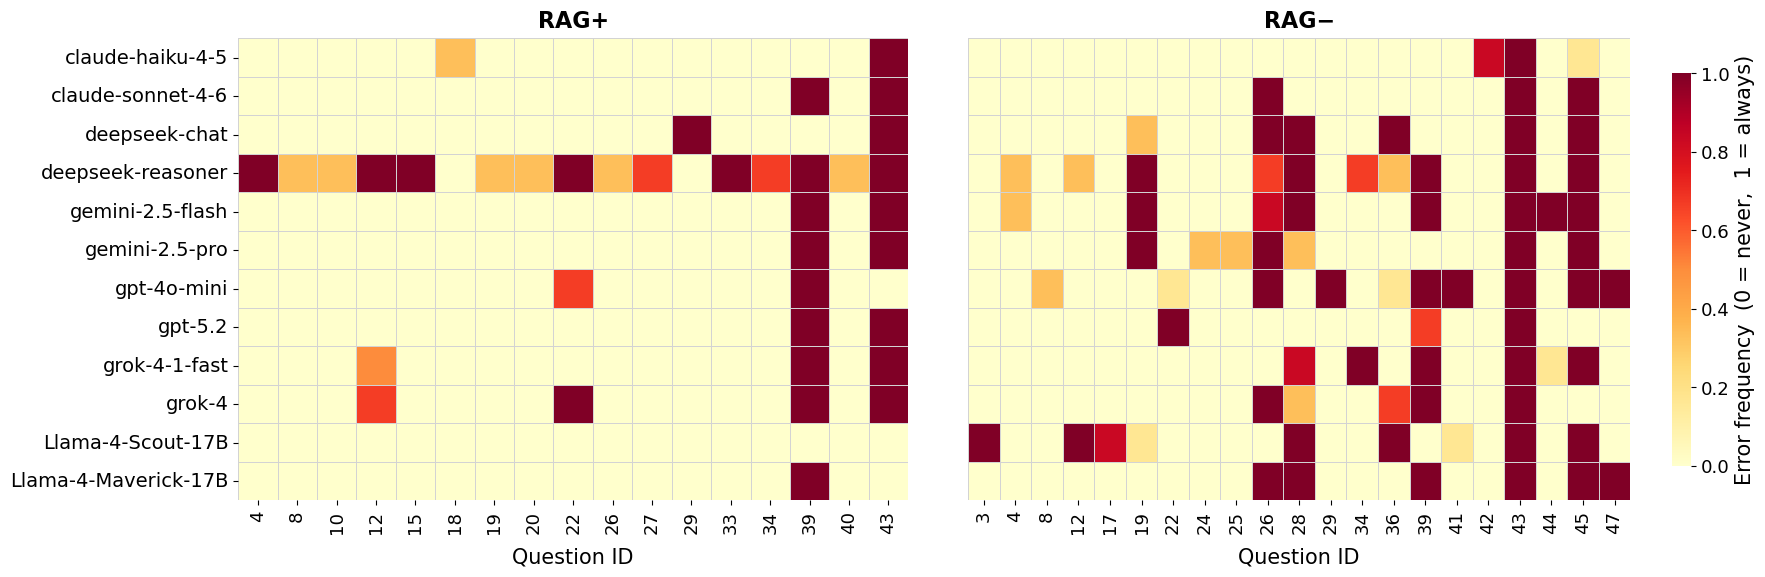


✓ Saved: svet_error_heatmap.png


In [1]:
# ============================================================
# SVET BENCHMARK — Fig. 2: Per-question error frequency heatmap
# All 12 models, RAG+ vs RAG−, aggregated across all temperatures and runs
# ============================================================

import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ─────────────────────────────────────────────────────────────
# 1. LOAD ALL CSV FILES
# ─────────────────────────────────────────────────────────────
DATA_DIR = r"C:\Users\Admin\OneDrive - Université Libre de Bruxelles\Leo\Insta\UMONS\svet paper\part I files"

csv_files = glob.glob(os.path.join(DATA_DIR, "results_*.csv"))
print(f"Found {len(csv_files)} CSV files")

df_all = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)

# Normalize temperature (DeepSeek-reasoner may report as string)
df_all['temperature'] = pd.to_numeric(df_all['temperature'], errors='coerce').fillna(0.0)

# Clean model names (strip vendor prefix and Llama instruct-variant suffixes)
def clean_model_name(name):
    return (name
            .replace('meta-llama/', '')
            .replace('-128E-Instruct', '')
            .replace('-16E-Instruct', ''))

df_all['model_version'] = df_all['model_version'].apply(clean_model_name)

print(f"Total rows: {len(df_all)}")
print(f"Models in data ({df_all['model_version'].nunique()}): "
      f"{sorted(df_all['model_version'].unique())}")

# ─────────────────────────────────────────────────────────────
# 2. ROW ORDER — must match cleaned names exactly
# ─────────────────────────────────────────────────────────────
ROW_ORDER = [
    'claude-haiku-4-5',
    'claude-sonnet-4-6',
    'deepseek-chat',
    'deepseek-reasoner',
    'gemini-2.5-flash',
    'gemini-2.5-pro',
    'gpt-4o-mini',
    'gpt-5.2',
    'grok-4-1-fast',
    'grok-4',
    'Llama-4-Scout-17B',       # ← was 'Llama-4-Scout-17B-16E' (BUG)
    'Llama-4-Maverick-17B',    # ← was 'Llama-4-Maverick-17B-128E' (BUG)
]

# Hard verification — abort if any row missing from the data
missing = [m for m in ROW_ORDER if m not in df_all['model_version'].unique()]
assert not missing, f"Models in ROW_ORDER missing from data: {missing}"
print(f"✓ All {len(ROW_ORDER)} models present in data")

# ─────────────────────────────────────────────────────────────
# 3. BUILD ERROR-FREQUENCY MATRICES
# ─────────────────────────────────────────────────────────────
def build_matrix(df, rag, row_order):
    sub = df[df['rag_condition'] == rag]
    pivot = (
        sub.groupby(['model_version', 'question_id'])
           .agg(wrong=('is_correct', lambda x: (x == 0).sum()),
                total=('is_correct', 'count'))
           .reset_index()
    )
    pivot['error_freq'] = pivot['wrong'] / pivot['total']
    matrix = (pivot
              .pivot(index='model_version',
                     columns='question_id',
                     values='error_freq')
              .fillna(0))
    # Keep only questions where at least one model errored at least once
    matrix = matrix[matrix.columns[matrix.max(axis=0) > 0]]
    matrix = matrix[sorted(matrix.columns, key=int)]
    # Force all 12 rows in fixed order (models with zero errors → all-zero row)
    matrix = matrix.reindex(row_order).fillna(0)
    return matrix

mat_plus  = build_matrix(df_all, 'RAG+', ROW_ORDER)
mat_minus = build_matrix(df_all, 'RAG-', ROW_ORDER)

print(f"\nRAG+ matrix:  {mat_plus.shape[0]} models × {mat_plus.shape[1]} questions")
print(f"RAG− matrix:  {mat_minus.shape[0]} models × {mat_minus.shape[1]} questions")

# Per-model sanity check (questions with any error, summed across runs/temps)
print("\nPer-model error question counts (any-error questions):")
for m in ROW_ORDER:
    n_plus  = (mat_plus.loc[m]  > 0).sum()
    n_minus = (mat_minus.loc[m] > 0).sum()
    print(f"  {m:30s}  RAG+: {n_plus:3d}    RAG−: {n_minus:3d}")

# ─────────────────────────────────────────────────────────────
# 4. PLOT
# ─────────────────────────────────────────────────────────────
n_cols_plus  = mat_plus.shape[1]
n_cols_minus = mat_minus.shape[1]
total_cols   = n_cols_plus + n_cols_minus
cell_size    = 0.45
fig_width    = cell_size * total_cols + 3

fig, axes = plt.subplots(
    1, 2,
    figsize=(fig_width, 6.0),
    gridspec_kw={'wspace': 0.08,
                 'width_ratios': [n_cols_plus, n_cols_minus]}
)

CMAP = 'YlOrRd'
VMIN, VMAX = 0, 1

# Left — RAG+
sns.heatmap(mat_plus, ax=axes[0],
            cmap=CMAP, vmin=VMIN, vmax=VMAX,
            linewidths=0.4, linecolor='lightgrey',
            cbar=False,
            xticklabels=True, yticklabels=True)
axes[0].set_title('RAG+', fontsize=16, fontweight='bold', pad=8)
axes[0].set_xlabel('Question ID', fontsize=15, labelpad=10)
axes[0].set_ylabel('')
axes[0].tick_params(axis='x', labelsize=13, rotation=90)
axes[0].tick_params(axis='y', labelsize=14)

# Right — RAG−
sns.heatmap(mat_minus, ax=axes[1],
            cmap=CMAP, vmin=VMIN, vmax=VMAX,
            linewidths=0.4, linecolor='lightgrey',
            cbar=True,
            cbar_kws={'label': 'Error frequency  (0 = never,  1 = always)',
                      'shrink': 0.85},
            xticklabels=True, yticklabels=False)
axes[1].set_title('RAG\u2212', fontsize=16, fontweight='bold', pad=8)
axes[1].set_xlabel('Question ID', fontsize=15, labelpad=10)
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', labelsize=13, rotation=90)

cbar = axes[1].collections[0].colorbar
cbar.ax.tick_params(labelsize=13)
cbar.set_label('Error frequency  (0 = never,  1 = always)', fontsize=15)

plt.savefig('svet_error_heatmap.png', bbox_inches='tight', dpi=300)
plt.show()
print("\n✓ Saved: svet_error_heatmap.png")

# LATENCY / COST

In [23]:
# ----------------------------
# LOAD .env + CREATE API CLIENTS
# ----------------------------
import os
from dotenv import load_dotenv

from openai import OpenAI
from google import genai
import anthropic

load_dotenv(os.path.join(BASE_DIR, ".env"), override=True)

# Optional sanity checks
required_envs = [
    "OPENAI_API_KEY",
    "GOOGLE_API_KEY",
    "XAI_API_KEY",
    "DEEPSEEK_API_KEY",
    "GROQ_API_KEY",
    "ANTHROPIC_API_KEY",
]

missing_envs = [k for k in required_envs if not os.getenv(k)]
if missing_envs:
    print("Missing in .env:", missing_envs)
else:
    print("All required API keys found in .env ✓")

# OpenAI
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

# Google Gemini
# Your .env uses GOOGLE_API_KEY, so pass it explicitly
gclient = genai.Client(api_key=os.getenv("GOOGLE_API_KEY"))

# xAI Grok
# Using OpenAI-compatible client because your code expects chat.completions.create(...)
xai_client = OpenAI(
    api_key=os.getenv("XAI_API_KEY"),
    base_url="https://api.x.ai/v1",
)

# DeepSeek
# OpenAI-compatible per official docs
ds_client = OpenAI(
    api_key=os.getenv("DEEPSEEK_API_KEY"),
    base_url="https://api.deepseek.com",
)

# Groq via OpenAI-compatible client
groq_client = OpenAI(
    api_key=os.getenv("GROQ_API_KEY"),
    base_url="https://api.groq.com/openai/v1",
)
# Anthropic
claude_client = anthropic.Anthropic(api_key=os.getenv("ANTHROPIC_API_KEY"))

print("Clients created ✓")

All required API keys found in .env ✓
Clients created ✓


Client availability:
 - OpenAI client           : OK
 - Google Gemini client    : OK
 - xAI client              : OK
 - DeepSeek client         : OK
 - Groq client             : OK
 - Anthropic client        : OK

Selected question:
Q01: What does the SVET probe primarily measure above a sample surface?
Correct answer: B
RAG mode: RAG+ | Retrieved chunks: 10

Running single-question benchmark...

[01/12] OpenAI | gpt-4o-mini | Efficient | T=0.0
    latency=2.593s | in=6493 | out=1 | total=6494 | parsed=B
[02/12] OpenAI | gpt-5.2 | Frontier | T=0.0
    latency=0.936s | in=6492 | out=4 | total=6496 | parsed=B
[03/12] Google | gemini-2.5-flash | Efficient | T=0.0
    latency=1.061s | in=6416 | out=1 | total=6417 | parsed=B
[04/12] Google | gemini-2.5-pro | Frontier | T=0.0
    latency=7.655s | in=6416 | out=1 | total=6506 | parsed=B
[05/12] xAI | grok-4-1-fast | Efficient | T=0.0
    latency=2.511s | in=6182 | out=1 | total=6428 | parsed=B
[06/12] xAI | grok-4 | Frontier | T=0.0
    laten

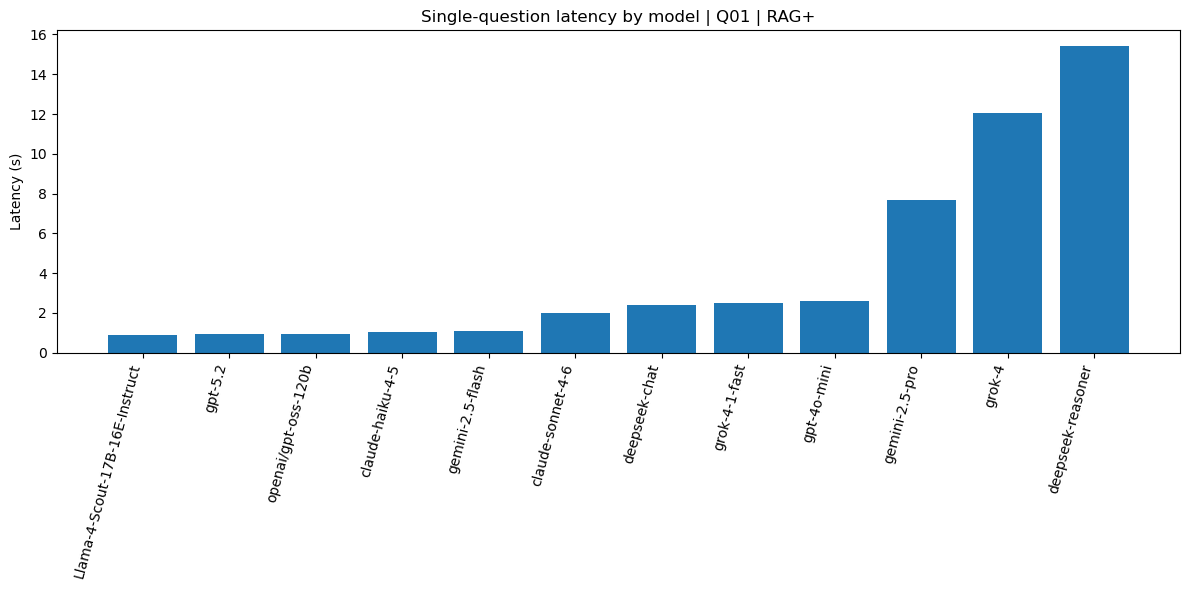

Saved plot -> C:\Users\Admin\OneDrive - Université Libre de Bruxelles\Leo\Insta\UMONS\svet paper\latency_tokens_Q01_RAGplus_20260331_142416.png

Notes:
- Use input_tokens and output_tokens for later cost calculation from each vendor's official pricing page.
- total_tokens is convenient for inspection, but billing is usually split by input vs output.
- If a provider exposes reasoning_tokens or cached_input_tokens, they are recorded separately.
- Failed runs may show missing token fields.


In [39]:
# ============================================================
# SINGLE-QUESTION LATENCY + TOKEN USAGE BENCHMARK
# Q1 across all tested models
# ------------------------------------------------------------
# What this records per run:
# - latency (wall-clock API call time)
# - input tokens
# - output tokens
# - total tokens
# - reasoning tokens (if provider exposes them)
# - cached input tokens (if provider exposes them)
# - finish reason
# - raw output
#
# Recommended default for latency comparison: RAG_MODE = "RAG-"
# because RAG+ includes retrieval/prompt-length effects.
# If you want, switch to RAG+ and the same retrieved context
# will be reused once for all models.
# ============================================================

import os
import re
import json
import time
import math
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timezone

# ----------------------------
# SETTINGS
# ----------------------------
QUESTION_ID = 1
RAG_MODE = "RAG+"              # "RAG-" or "RAG+"
PAUSE_BETWEEN_CALLS = 1.0      # seconds
SAVE_CSV = True
SAVE_PLOT = True

# DeepSeek-Reasoner note:
# - provider default temperature is preserved (not independently set)
# - final answer letter is extracted ONLY from the non-thinking output
# - reasoning content is stored separately if the API returns it
DEEPSEEK_REASONER_MAX_TOKENS = 1024


# ----------------------------
# PRE-FLIGHT CHECKS + FALLBACK REBUILD
# ----------------------------
# This makes the latency cell self-sufficient if the kernel lost:
# - questions
# - build_user_prompt
# - retrieve

BASE_DIR = r"C:\Users\Admin\OneDrive - Université Libre de Bruxelles\Leo\Insta\UMONS\svet paper"
OUTPUT_DIR = BASE_DIR
QUIZ_PATH = os.path.join(BASE_DIR, "SVET QUIZ.txt")
NEW_KB_PATH = os.path.join(BASE_DIR, "embeddings_3072.json")

if "questions" not in globals():
    QUIZ_PATH = os.path.join(BASE_DIR, "SVET QUIZ.txt")

    def parse_quiz(path):
        with open(path, "r", encoding="utf-8") as f:
            text = f.read()

        questions = []
        blocks = re.split(r'\n(?=\d{1,2}\.)', text)

        for block in blocks:
            block = block.strip()
            if not block:
                continue

            q_match   = re.match(r'^(\d{1,2})\.\s+(.*?)(?=\nA\.)', block, re.DOTALL)
            a_match   = re.search(r'A\.\s+(.*?)(?=\nB\.)',         block, re.DOTALL)
            b_match   = re.search(r'B\.\s+(.*?)(?=\nC\.)',         block, re.DOTALL)
            c_match   = re.search(r'C\.\s+(.*?)(?=\nCorrect:)',    block, re.DOTALL)
            ans_match = re.search(r'Correct:\s*([ABC])',           block)

            if not all([q_match, a_match, b_match, c_match, ans_match]):
                continue

            questions.append({
                "question_id": int(q_match.group(1)),
                "question_text": q_match.group(2).strip().replace("\n", " "),
                "option_a": a_match.group(1).strip(),
                "option_b": b_match.group(1).strip(),
                "option_c": c_match.group(1).strip(),
                "correct_answer": ans_match.group(1).strip(),
            })

        return sorted(questions, key=lambda x: x["question_id"])

    questions = parse_quiz(QUIZ_PATH)
    print(f"`questions` rebuilt ✓ ({len(questions)} questions)")

if "build_user_prompt" not in globals():
    def build_user_prompt(q: dict) -> str:
        return (
            f"{q['question_text']}\n\n"
            f"A) {q['option_a']}\n"
            f"B) {q['option_b']}\n"
            f"C) {q['option_c']}\n\n"
            f"Answer:"
        )
    print("`build_user_prompt` rebuilt ✓")

if "retrieve" not in globals():
    with open(NEW_KB_PATH, "r", encoding="utf-8") as f:
        kb = json.load(f)

    texts      = [chunk["text"] for chunk in kb]
    sources    = [chunk["source"] for chunk in kb]
    embeddings = np.array([chunk["embedding"] for chunk in kb], dtype=np.float32)

    def embed_query(text: str) -> np.ndarray:
        result = gclient.models.embed_content(
            model="gemini-embedding-001",
            contents=text,
        )
        return np.array(result.embeddings[0].values, dtype=np.float32)

    def cosine_similarity(a: np.ndarray, b: np.ndarray) -> np.ndarray:
        a_norm = a / (np.linalg.norm(a) + 1e-10)
        b_norm = b / (np.linalg.norm(b, axis=1, keepdims=True) + 1e-10)
        return b_norm @ a_norm

    SIMILARITY_THRESHOLD = 0.3
    RAG_TOP_K = 10

    def retrieve(query: str) -> tuple[str, int]:
        q_emb  = embed_query(query)
        scores = cosine_similarity(q_emb, embeddings)
        above  = np.where(scores > SIMILARITY_THRESHOLD)[0]
        if len(above) == 0:
            return "", 0
        top_idx = above[np.argsort(scores[above])[::-1][:RAG_TOP_K]]
        chunks  = [f"[Source: {sources[i]}]\n{texts[i]}" for i in top_idx]
        return "\n\n---\n\n".join(chunks), len(top_idx)

    print("`retrieve` rebuilt ✓")



required_globals = ["questions", "retrieve", "build_user_prompt"]
missing = [x for x in required_globals if x not in globals()]
if missing:
    raise RuntimeError(
        "Still missing required notebook objects:\n"
        + "\n".join(f" - {m}" for m in missing)
    )

# clients should already exist in your notebook if you ran the provider cells
optional_clients = {
    "OpenAI client": "client",
    "Google Gemini client": "gclient",
    "xAI client": "xai_client",
    "DeepSeek client": "ds_client",
    "Groq client": "groq_client",
    "Anthropic client": "claude_client",
}
print("Client availability:")
for label, name in optional_clients.items():
    print(f" - {label:<24}: {'OK' if name in globals() else 'MISSING'}")

# ----------------------------
# QUESTION SELECTION
# ----------------------------
q = next((x for x in questions if int(x["question_id"]) == QUESTION_ID), None)
if q is None:
    raise ValueError(f"Question ID {QUESTION_ID} not found in `questions`.")

BASE_SYSTEM_PROMPT = globals().get(
    "SYSTEM_PROMPT",
    (
        "You are an expert in the Scanning Vibrating Electrode Technique (SVET), "
        "a specialized electrochemical characterization method used in corrosion research. "
        "Answer the following multiple-choice question by responding ONLY with the letter "
        "of the correct answer (A, B, or C). Do not explain your reasoning."
    )
)

USER_PROMPT = build_user_prompt(q)

# Precompute RAG context ONCE for fairness if RAG+ is selected
if RAG_MODE == "RAG+":
    SHARED_CONTEXT, SHARED_N_CHUNKS = retrieve(q["question_text"])
else:
    SHARED_CONTEXT, SHARED_N_CHUNKS = None, 0

def make_system_prompt(base_system: str, rag_mode: str, context: str | None) -> str:
    if rag_mode == "RAG+" and context:
        return base_system + f"\n\nRelevant context:\n{context}"
    return base_system

SYSTEM_PROMPT_FOR_RUN = make_system_prompt(BASE_SYSTEM_PROMPT, RAG_MODE, SHARED_CONTEXT)

print("\nSelected question:")
print(f"Q{q['question_id']:02d}: {q['question_text']}")
print(f"Correct answer: {q['correct_answer']}")
print(f"RAG mode: {RAG_MODE} | Retrieved chunks: {SHARED_N_CHUNKS}")

# ----------------------------
# HELPERS
# ----------------------------
def safe_get(obj, *path, default=None):
    cur = obj
    for key in path:
        if cur is None:
            return default
        if isinstance(cur, dict):
            cur = cur.get(key, default)
        else:
            cur = getattr(cur, key, default)
    return cur

def normalize_text_content(content):
    if content is None:
        return ""
    if isinstance(content, str):
        return content.strip()
    if isinstance(content, list):
        parts = []
        for item in content:
            if isinstance(item, str):
                if item.strip():
                    parts.append(item.strip())
            elif isinstance(item, dict):
                txt = item.get("text") or item.get("content") or ""
                if str(txt).strip():
                    parts.append(str(txt).strip())
            else:
                txt = getattr(item, "text", None)
                if txt and str(txt).strip():
                    parts.append(str(txt).strip())
        return "\n".join(parts).strip()
    return str(content).strip()

def to_jsonable_str(obj):
    if obj is None:
        return None
    try:
        if hasattr(obj, "model_dump"):
            payload = obj.model_dump()
        elif hasattr(obj, "to_dict"):
            payload = obj.to_dict()
        elif isinstance(obj, dict):
            payload = obj
        else:
            payload = repr(obj)
        return json.dumps(payload, ensure_ascii=False, default=str)
    except Exception:
        return repr(obj)

def parse_mcq_answer(raw: str) -> str:
    raw = (raw or "").strip().upper()
    m = re.search(r"\b([ABC])\b", raw)
    return m.group(1) if m else "PARSE_ERROR"

def parse_reasoner_answer(raw: str) -> str:
    raw = (raw or "").strip()
    if not raw:
        return "PARSE_ERROR"
    try:
        obj = json.loads(raw)
        ans = str(obj.get("answer", "")).strip().upper()
        if ans in {"A", "B", "C"}:
            return ans
    except Exception:
        pass
    return parse_mcq_answer(raw)

def extract_openai_compatible_usage(resp):
    usage = getattr(resp, "usage", None)
    return {
        "input_tokens": safe_get(usage, "prompt_tokens"),
        "output_tokens": safe_get(usage, "completion_tokens"),
        "total_tokens": safe_get(usage, "total_tokens"),
        "reasoning_tokens": (
            safe_get(usage, "completion_tokens_details", "reasoning_tokens")
            or safe_get(usage, "output_tokens_details", "reasoning_tokens")
        ),
        "cached_input_tokens": (
            safe_get(usage, "prompt_tokens_details", "cached_tokens")
            or safe_get(usage, "input_tokens_details", "cached_tokens")
        ),
        "usage_raw_json": to_jsonable_str(usage),
    }

def extract_gemini_usage(resp):
    usage = getattr(resp, "usage_metadata", None)
    return {
        "input_tokens": safe_get(usage, "prompt_token_count"),
        "output_tokens": safe_get(usage, "candidates_token_count"),
        "total_tokens": safe_get(usage, "total_token_count"),
        "reasoning_tokens": None,
        "cached_input_tokens": None,
        "usage_raw_json": to_jsonable_str(usage),
    }

def extract_anthropic_usage(resp):
    usage = getattr(resp, "usage", None)
    inp = safe_get(usage, "input_tokens")
    out = safe_get(usage, "output_tokens")
    total = None
    if inp is not None and out is not None:
        total = inp + out
    return {
        "input_tokens": inp,
        "output_tokens": out,
        "total_tokens": total,
        "reasoning_tokens": None,
        "cached_input_tokens": None,
        "usage_raw_json": to_jsonable_str(usage),
    }

def build_result_row(
    provider,
    model,
    tier,
    temperature_label,
    latency_s,
    finish_reason,
    raw_output,
    parsed_answer,
    usage_dict,
    error=None,
    reasoning_output=None,
):
    return {
        "timestamp_utc": datetime.now(timezone.utc).isoformat(),
        "question_id": q["question_id"],
        "rag_condition": RAG_MODE,
        "n_chunks_retrieved": SHARED_N_CHUNKS,
        "provider": provider,
        "model": model,
        "tier": tier,
        "temperature": temperature_label,
        "latency_s": latency_s,
        "latency_ms": None if latency_s is None else latency_s * 1000.0,
        "input_tokens": usage_dict.get("input_tokens"),
        "output_tokens": usage_dict.get("output_tokens"),
        "total_tokens": usage_dict.get("total_tokens"),
        "reasoning_tokens": usage_dict.get("reasoning_tokens"),
        "cached_input_tokens": usage_dict.get("cached_input_tokens"),
        "finish_reason": finish_reason,
        "raw_output": raw_output,
        "reasoning_output": reasoning_output,
        "parsed_answer": parsed_answer,
        "correct_answer": q["correct_answer"],
        "is_correct": int(parsed_answer == q["correct_answer"]) if parsed_answer not in [None, "PARSE_ERROR"] else 0,
        "error": error,
        "usage_raw_json": usage_dict.get("usage_raw_json"),
    }

# ----------------------------
# MODEL CALLERS
# ----------------------------
def call_openai_model(model: str, temperature):
    start = time.perf_counter()
    try:
        token_param = (
            "max_completion_tokens"
            if ("5.2" in model or "o1" in model or "o3" in model)
            else "max_tokens"
        )
        resp = client.chat.completions.create(
            model=model,
            temperature=temperature,
            **{token_param: 10},
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT_FOR_RUN},
                {"role": "user", "content": USER_PROMPT},
            ],
        )
        latency = time.perf_counter() - start
        raw = normalize_text_content(resp.choices[0].message.content)
        parsed = parse_mcq_answer(raw)
        finish_reason = safe_get(resp, "choices", default=[{}])[0].finish_reason if safe_get(resp, "choices") else None
        usage = extract_openai_compatible_usage(resp)
        return build_result_row("OpenAI", model, "Efficient" if model == "gpt-4o-mini" else "Frontier",
                                str(temperature), latency, finish_reason, raw, parsed, usage)
    except Exception as e:
        latency = time.perf_counter() - start
        return build_result_row("OpenAI", model, "Efficient" if model == "gpt-4o-mini" else "Frontier",
                                str(temperature), latency, None, "", "PARSE_ERROR",
                                {"input_tokens": None, "output_tokens": None, "total_tokens": None,
                                 "reasoning_tokens": None, "cached_input_tokens": None, "usage_raw_json": None},
                                error=str(e))

def call_gemini_model(model: str, temperature, tier: str):
    start = time.perf_counter()
    try:
        cfg = {
            "system_instruction": SYSTEM_PROMPT_FOR_RUN,
            "temperature": temperature,
            "max_output_tokens": 300,
        }

        if model == "gemini-2.5-flash":
            cfg["thinking_config"] = {"thinking_budget": 0}
        elif model == "gemini-2.5-pro":
            cfg["thinking_config"] = {"thinking_budget": 128}

        resp = gclient.models.generate_content(
            model=model,
            contents=USER_PROMPT,
            config=cfg,
        )
        latency = time.perf_counter() - start

        try:
            raw = (resp.text or "").strip()
        except Exception:
            raw = ""

        finish_reason = safe_get(resp, "candidates", default=[{}])[0].finish_reason if safe_get(resp, "candidates") else None

        if not raw:
            raw = f"API_ERROR: empty text (finish_reason={finish_reason})"

        parsed = parse_mcq_answer(raw)
        usage = extract_gemini_usage(resp)

        return build_result_row("Google", model, tier, str(temperature), latency, finish_reason, raw, parsed, usage)

    except Exception as e:
        latency = time.perf_counter() - start
        return build_result_row("Google", model, tier, str(temperature), latency, None, "", "PARSE_ERROR",
                                {"input_tokens": None, "output_tokens": None, "total_tokens": None,
                                 "reasoning_tokens": None, "cached_input_tokens": None, "usage_raw_json": None},
                                error=str(e))
        
def call_xai_model(model: str, temperature, tier: str):
    start = time.perf_counter()
    try:
        resp = xai_client.chat.completions.create(
            model=model,
            temperature=temperature,
            max_tokens=10,
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT_FOR_RUN},
                {"role": "user", "content": USER_PROMPT},
            ],
        )
        latency = time.perf_counter() - start
        raw = normalize_text_content(resp.choices[0].message.content)
        parsed = parse_mcq_answer(raw)
        finish_reason = safe_get(resp, "choices", default=[{}])[0].finish_reason if safe_get(resp, "choices") else None
        usage = extract_openai_compatible_usage(resp)
        return build_result_row("xAI", model, tier, str(temperature), latency, finish_reason, raw, parsed, usage)
    except Exception as e:
        latency = time.perf_counter() - start
        return build_result_row("xAI", model, tier, str(temperature), latency, None, "", "PARSE_ERROR",
                                {"input_tokens": None, "output_tokens": None, "total_tokens": None,
                                 "reasoning_tokens": None, "cached_input_tokens": None, "usage_raw_json": None},
                                error=str(e))

def call_deepseek_chat(model: str, temperature):
    start = time.perf_counter()
    try:
        resp = ds_client.chat.completions.create(
            model=model,
            temperature=temperature,
            max_tokens=10,
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT_FOR_RUN},
                {"role": "user", "content": USER_PROMPT},
            ],
        )
        latency = time.perf_counter() - start
        raw = normalize_text_content(resp.choices[0].message.content)
        parsed = parse_mcq_answer(raw)
        finish_reason = safe_get(resp, "choices", default=[{}])[0].finish_reason if safe_get(resp, "choices") else None
        usage = extract_openai_compatible_usage(resp)
        return build_result_row("DeepSeek", model, "Efficient", str(temperature), latency, finish_reason, raw, parsed, usage)
    except Exception as e:
        latency = time.perf_counter() - start
        return build_result_row("DeepSeek", model, "Efficient", str(temperature), latency, None, "", "PARSE_ERROR",
                                {"input_tokens": None, "output_tokens": None, "total_tokens": None,
                                 "reasoning_tokens": None, "cached_input_tokens": None, "usage_raw_json": None},
                                error=str(e))

def _extract_reasoning_content_from_message(msg):
    rc = getattr(msg, "reasoning_content", None)
    if rc:
        return rc
    extra = getattr(msg, "model_extra", None) or {}
    if isinstance(extra, dict):
        return extra.get("reasoning_content", "") or ""
    return ""

def call_deepseek_reasoner():
    start = time.perf_counter()
    try:
        reasoner_system = (
            "You are an expert in the Scanning Vibrating Electrode Technique (SVET), "
            "a specialized electrochemical characterization method used in corrosion research. "
            "Return STRICT JSON only: {\"answer\":\"A\"} where answer is A, B, or C."
        )
        if RAG_MODE == "RAG+" and SHARED_CONTEXT:
            reasoner_system += f"\n\nRelevant context:\n{SHARED_CONTEXT}"

        resp = ds_client.chat.completions.create(
            model="deepseek-reasoner",
            max_tokens=DEEPSEEK_REASONER_MAX_TOKENS,
            response_format={"type": "json_object"},
            stream=False,
            messages=[
                {"role": "system", "content": reasoner_system},
                {"role": "user", "content": USER_PROMPT},
            ],
        )
        latency = time.perf_counter() - start

        msg = resp.choices[0].message
        final_output = normalize_text_content(msg.content)     # non-thinking output only
        reasoning_output = (_extract_reasoning_content_from_message(msg) or "").strip()
        parsed = parse_reasoner_answer(final_output)
        finish_reason = safe_get(resp, "choices", default=[{}])[0].finish_reason if safe_get(resp, "choices") else None
        usage = extract_openai_compatible_usage(resp)

        err = None
        if not final_output:
            err = "No non-thinking final output returned; parsed from final output only."

        return build_result_row(
            "DeepSeek",
            "deepseek-reasoner",
            "Frontier",
            "default",
            latency,
            finish_reason,
            final_output,
            parsed,
            usage,
            error=err,
            reasoning_output=reasoning_output,
        )
    except Exception as e:
        latency = time.perf_counter() - start
        return build_result_row("DeepSeek", "deepseek-reasoner", "Frontier", "default", latency, None, "",
                                "PARSE_ERROR",
                                {"input_tokens": None, "output_tokens": None, "total_tokens": None,
                                 "reasoning_tokens": None, "cached_input_tokens": None, "usage_raw_json": None},
                                error=str(e),
                                reasoning_output=None)

def call_groq_llama(model: str, tier: str, temperature):
    start = time.perf_counter()
    try:
        provider_name = "Groq" if model == "openai/gpt-oss-120b" else "Meta/Groq"

        # Special handling for GPT-OSS 120B: force strict JSON output
        if model == "openai/gpt-oss-120b":
            import requests
        
            payload = {
                "model": model,
                "messages": [
                    {
                        "role": "user",
                        "content": (
                            f"{SYSTEM_PROMPT_FOR_RUN}\n\n"
                            f"{USER_PROMPT}\n\n"
                            "Respond with exactly ONE capital letter only: A, B, or C.\n"
                            "Do not explain.\n"
                            "Do not output JSON.\n"
                            "Do not output any other text."
                        )
                    }
                ],
                "temperature": float(temperature),
                "max_completion_tokens": 64,
                "reasoning_effort": "low",
                "include_reasoning": False,
                "stream": False
            }
        
            headers = {
                "Authorization": f"Bearer {os.getenv('GROQ_API_KEY')}",
                "Content-Type": "application/json",
            }
        
            http_start = time.perf_counter()
            r = requests.post(
                "https://api.groq.com/openai/v1/chat/completions",
                headers=headers,
                json=payload,
                timeout=60
            )
            latency = time.perf_counter() - http_start
        
            if not r.ok:
                return build_result_row(
                    provider_name, model, tier, str(temperature), latency, None, "", "PARSE_ERROR",
                    {
                        "input_tokens": None,
                        "output_tokens": None,
                        "total_tokens": None,
                        "reasoning_tokens": None,
                        "cached_input_tokens": None,
                        "usage_raw_json": None,
                    },
                    error=r.text
                )
        
            data = r.json()
            raw = data["choices"][0]["message"]["content"].strip()
            parsed = parse_mcq_answer(raw)
            finish_reason = data["choices"][0].get("finish_reason")
        
            usage_obj = data.get("usage", {})
            usage = {
                "input_tokens": usage_obj.get("prompt_tokens"),
                "output_tokens": usage_obj.get("completion_tokens"),
                "total_tokens": usage_obj.get("total_tokens"),
                "reasoning_tokens": (usage_obj.get("completion_tokens_details", {}) or {}).get("reasoning_tokens"),
                "cached_input_tokens": (usage_obj.get("prompt_tokens_details", {}) or {}).get("cached_tokens"),
                "usage_raw_json": json.dumps(usage_obj, ensure_ascii=False),
            }
        
            return build_result_row(
                provider_name, model, tier, str(temperature),
                latency, finish_reason, raw, parsed, usage
            )

        # Default handling for Groq-hosted Llama models
        resp = groq_client.chat.completions.create(
            model=model,
            temperature=temperature,
            max_completion_tokens=10,
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT_FOR_RUN},
                {"role": "user", "content": USER_PROMPT},
            ],
        )

        latency = time.perf_counter() - start
        raw = normalize_text_content(resp.choices[0].message.content)
        parsed = parse_mcq_answer(raw)
        finish_reason = safe_get(resp, "choices", default=[{}])[0].finish_reason if safe_get(resp, "choices") else None
        usage = extract_openai_compatible_usage(resp)

        return build_result_row(
            provider_name, model, tier, str(temperature),
            latency, finish_reason, raw, parsed, usage
        )

    except Exception as e:
        latency = time.perf_counter() - start
        provider_name = "Groq" if model == "openai/gpt-oss-120b" else "Meta/Groq"
        return build_result_row(
            provider_name, model, tier, str(temperature), latency, None, "", "PARSE_ERROR",
            {
                "input_tokens": None,
                "output_tokens": None,
                "total_tokens": None,
                "reasoning_tokens": None,
                "cached_input_tokens": None,
                "usage_raw_json": None,
            },
            error=str(e)
        )

def call_claude(model: str, tier: str, temperature):
    backoffs = [3, 8, 15]

    for attempt in range(len(backoffs) + 1):
        start = time.perf_counter()
        try:
            resp = claude_client.messages.create(
                model=model,
                max_tokens=10,
                temperature=temperature,
                system=SYSTEM_PROMPT_FOR_RUN,
                messages=[{"role": "user", "content": USER_PROMPT}],
            )
            latency = time.perf_counter() - start

            text_parts = []
            for block in getattr(resp, "content", []):
                txt = getattr(block, "text", None)
                if txt and str(txt).strip():
                    text_parts.append(str(txt).strip())
            raw = "\n".join(text_parts).strip()

            parsed = parse_mcq_answer(raw)
            finish_reason = getattr(resp, "stop_reason", None)
            usage = extract_anthropic_usage(resp)

            return build_result_row("Anthropic", model, tier, str(temperature), latency, finish_reason, raw, parsed, usage)

        except Exception as e:
            latency = time.perf_counter() - start
            err = str(e)

            is_last = attempt == len(backoffs)
            is_overload = "529" in err or "overloaded" in err.lower()

            if (not is_overload) or is_last:
                return build_result_row("Anthropic", model, tier, str(temperature), latency, None, "", "PARSE_ERROR",
                                        {"input_tokens": None, "output_tokens": None, "total_tokens": None,
                                         "reasoning_tokens": None, "cached_input_tokens": None, "usage_raw_json": None},
                                        error=err)

            time.sleep(backoffs[attempt])

# ----------------------------
# MODEL LIST
# ----------------------------
model_specs = [
    {"provider": "OpenAI",    "model": "gpt-4o-mini",                                      "tier": "Efficient", "temperature": 0.0,       "runner": "openai"},
    {"provider": "OpenAI",    "model": "gpt-5.2",                                          "tier": "Frontier",  "temperature": 0.0,       "runner": "openai"},
    {"provider": "Google",    "model": "gemini-2.5-flash",                                 "tier": "Efficient", "temperature": 0.0,       "runner": "gemini"},
    {"provider": "Google",    "model": "gemini-2.5-pro",                                   "tier": "Frontier",  "temperature": 0.0,       "runner": "gemini"},
    {"provider": "xAI",       "model": "grok-4-1-fast",                                    "tier": "Efficient", "temperature": 0.0,       "runner": "xai"},
    {"provider": "xAI",       "model": "grok-4",                                           "tier": "Frontier",  "temperature": 0.0,       "runner": "xai"},
    {"provider": "DeepSeek",  "model": "deepseek-chat",                                    "tier": "Efficient", "temperature": 0.0,       "runner": "deepseek_chat"},
    {"provider": "DeepSeek",  "model": "deepseek-reasoner",                                "tier": "Frontier",  "temperature": "default", "runner": "deepseek_reasoner"},
    {"provider": "Meta/Groq", "model": "meta-llama/Llama-4-Scout-17B-16E-Instruct",        "tier": "Efficient", "temperature": 0.0, "runner": "groq_llama"},
    {"provider": "Groq", "model": "openai/gpt-oss-120b", "tier": "Frontier", "temperature": 0.0, "runner": "groq_llama"},
    {"provider": "Anthropic", "model": "claude-haiku-4-5",                                 "tier": "Efficient", "temperature": 0.0,       "runner": "claude"},
    {"provider": "Anthropic", "model": "claude-sonnet-4-6",                                "tier": "Frontier",  "temperature": 0.0,       "runner": "claude"},
]

# ----------------------------
# EXECUTION
# ----------------------------
results = []

print("\nRunning single-question benchmark...\n")
for i, spec in enumerate(model_specs, start=1):
    provider = spec["provider"]
    model = spec["model"]
    tier = spec["tier"]
    temp = spec["temperature"]
    runner = spec["runner"]

    print(f"[{i:02d}/{len(model_specs)}] {provider} | {model} | {tier} | T={temp}")

    if runner == "openai":
        row = call_openai_model(model, temp)
    elif runner == "gemini":
        row = call_gemini_model(model, temp, tier)
    elif runner == "xai":
        row = call_xai_model(model, temp, tier)
    elif runner == "deepseek_chat":
        row = call_deepseek_chat(model, temp)
    elif runner == "deepseek_reasoner":
        row = call_deepseek_reasoner()
    elif runner == "groq_llama":
        row = call_groq_llama(model, tier, temp)
    elif runner == "claude":
        row = call_claude(model, tier, temp)
    else:
        row = build_result_row(
            provider, model, tier, str(temp), None, None, "", "PARSE_ERROR",
            {"input_tokens": None, "output_tokens": None, "total_tokens": None,
             "reasoning_tokens": None, "cached_input_tokens": None, "usage_raw_json": None},
            error=f"Unknown runner: {runner}"
        )

    results.append(row)

    latency_str = "NA" if row["latency_s"] is None else f"{row['latency_s']:.3f}s"
    tok_str = (
        f"in={row['input_tokens']} | out={row['output_tokens']} | total={row['total_tokens']}"
    )
    parse_str = row["parsed_answer"]
    err_str = f" | ERROR={row['error']}" if row["error"] else ""
    print(f"    latency={latency_str} | {tok_str} | parsed={parse_str}{err_str}")

    if i < len(model_specs):
        time.sleep(PAUSE_BETWEEN_CALLS)

df_latency = pd.DataFrame(results)

# nicer display names
def pretty_model_name(m):
    if m.startswith("meta-llama/"):
        return m.split("/", 1)[1]
    return m

df_latency["model_display"] = df_latency["model"].apply(pretty_model_name)

# sort for inspection
df_sorted_latency = df_latency.sort_values("latency_s", na_position="last").reset_index(drop=True)

print("\n==================== LATENCY RANKING ====================")
print(
    df_sorted_latency[
        ["provider", "model_display", "tier", "temperature",
         "latency_s", "input_tokens", "output_tokens", "total_tokens",
         "reasoning_tokens", "parsed_answer", "correct_answer", "is_correct", "error"]
    ].to_string(index=False)
)

print("\n==================== COST-READY TOKEN TABLE ====================")
print(
    df_latency[
        ["provider", "model_display", "temperature", "input_tokens", "output_tokens",
         "total_tokens", "reasoning_tokens", "cached_input_tokens"]
    ].to_string(index=False)
)

# ----------------------------
# SAVE CSV
# ----------------------------
timestamp_tag = datetime.now().strftime("%Y%m%d_%H%M%S")
csv_name = f"latency_tokens_Q{QUESTION_ID:02d}_{RAG_MODE.replace('+','plus').replace('-','minus')}_{timestamp_tag}.csv"
OUTPUT_DIR = r"C:\Users\Admin\OneDrive - Université Libre de Bruxelles\Leo\Insta\UMONS\svet paper"
csv_path = os.path.join(OUTPUT_DIR, csv_name)

if SAVE_CSV:
    df_latency.to_csv(csv_path, index=False)
    print(f"\nSaved CSV -> {csv_path}")

# ----------------------------
# PLOT
# ----------------------------
if SAVE_PLOT:
    plot_df = df_sorted_latency.dropna(subset=["latency_s"]).copy()
    if len(plot_df) > 0:
        plt.figure(figsize=(12, 6))
        plt.bar(plot_df["model_display"], plot_df["latency_s"])
        plt.xticks(rotation=75, ha="right")
        plt.ylabel("Latency (s)")
        plt.title(f"Single-question latency by model | Q{QUESTION_ID:02d} | {RAG_MODE}")
        plt.tight_layout()

        plot_name = f"latency_tokens_Q{QUESTION_ID:02d}_{RAG_MODE.replace('+','plus').replace('-','minus')}_{timestamp_tag}.png"
        plot_path = os.path.join(OUTPUT_DIR, plot_name)
        plt.savefig(plot_path, dpi=200, bbox_inches="tight")
        plt.show()
        print(f"Saved plot -> {plot_path}")

# ----------------------------
# OPTIONAL SUMMARY HELPERS
# ----------------------------
print("\nNotes:")
print("- Use input_tokens and output_tokens for later cost calculation from each vendor's official pricing page.")
print("- total_tokens is convenient for inspection, but billing is usually split by input vs output.")
print("- If a provider exposes reasoning_tokens or cached_input_tokens, they are recorded separately.")
print("- Failed runs may show missing token fields.")

In [2]:
import matplotlib.ticker



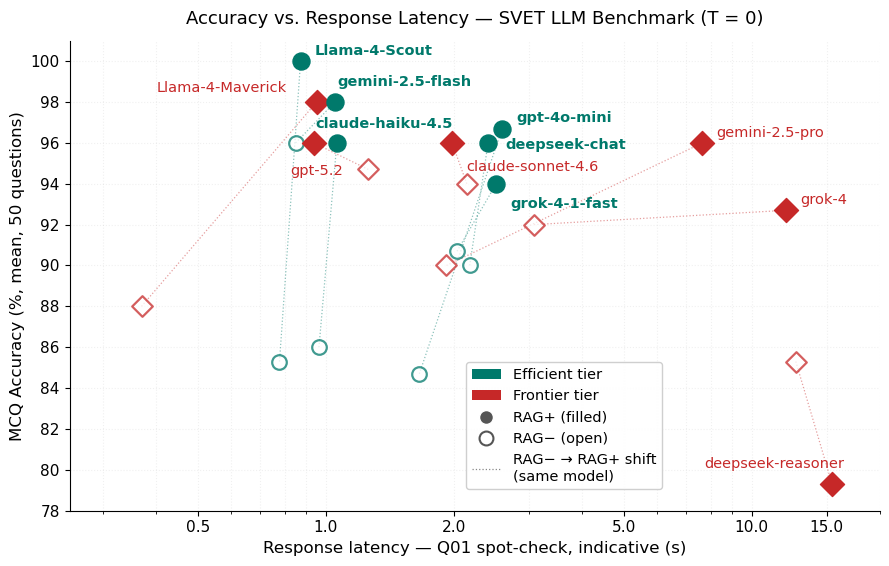

Saved: accuracy_vs_latency_SVET.png


In [115]:
"""
Accuracy vs. Latency — SVET LLM Benchmark (T = 0)
Log-scale x-axis, legend outside, nudges tuned for log layout.
"""

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.ticker

# ── DATA ──────────────────────────────────────────────────────────────────────
# (tier, lat_RAGminus, lat_RAGplus, acc_RAGminus, acc_RAGplus)
models = {
    "gpt-4o-mini"       : ("Efficient", 1.657,  2.593,  84.7,  96.7),
    "gpt-5.2"           : ("Frontier",  1.257,  0.936,  94.7,  96.0),
    "gemini-2.5-flash"  : ("Efficient", 0.963,  1.061,  86.0,  96.0),
    "gemini-2.5-pro"    : ("Frontier",  1.919,  7.655,  90.0,  96.0),
    "grok-4-1-fast"     : ("Efficient", 2.032,  2.511,  90.7,  94.0),
    "grok-4"            : ("Frontier",  3.080, 12.051,  92.0,  92.7),
    "deepseek-chat"     : ("Efficient", 2.176,  2.403,  90.0,  96.0),
    "deepseek-reasoner" : ("Frontier", 12.686, 15.437,  85.3,  79.3),
    "Llama-4-Scout"     : ("Efficient", 0.778,  0.872,  85.3, 100.0),
    "Llama-4-Maverick" : ("Frontier",  0.369,  0.951,  88.0,  98.0),
    "claude-haiku-4.5"  : ("Efficient", 0.849,  1.051,  96.0,  98.0),
    "claude-sonnet-4.6" : ("Frontier",  2.142,  1.978,  94.0,  96.0),
}

COLOR = {"Efficient": "#00796B", "Frontier": "#C62828"}
MARKER = {"Efficient": "o",       "Frontier": "D"}

# Nudges tuned for log-scale x-axis
# (multiplier on x for dx, absolute dy in accuracy units)
# dx is a multiplier: label_x = lat_p * dx_mult
# positive dy = above point, negative = below
NUDGE = {
    #                        x_mult   dy
    "Llama-4-Scout"     : (  1.08,   0.50),   # top-left, room above
    "claude-haiku-4.5"  : (  0.90,  -1.1),   # just below Llama-Scout
    "Llama-4-Maverick" : (  0.42,   0.70),   # left of its point (frontier, ~0.95s)
    "gpt-5.2"           : (  0.88,  -1.40),   # below claude-haiku cluster
    "gemini-2.5-flash"  : (  1,   2.99),   # left of point (0.96 acc, 1.06s)
    "gpt-4o-mini"       : (  1.08,   0.50),   # right of point (96.7, 2.59s)
    "claude-sonnet-4.6" : (  1.08,  -1.20),   # below gpt-4o-mini
    "deepseek-chat"     : (  1.1,   -0.1),   # right of point (96, 2.4s)
    "grok-4-1-fast"     : (  1.08,  -1.00),   # below deepseek-chat
    "gemini-2.5-pro"    : (  1.08,   0.50),   # right of point (96, 7.65s)
    "grok-4"            : (  1.08,   0.50),   # right of point (92.7, 12s)
    "deepseek-reasoner" : (  0.5,  1),   # below grok-4 region
}

# ── FIGURE ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

for name, (tier, lat_m, lat_p, acc_m, acc_p) in models.items():
    c  = COLOR[tier]
    mk = MARKER[tier]
    x_mult, dy = NUDGE[name]

    # Dotted connector
    ax.plot([lat_m, lat_p], [acc_m, acc_p],
            color=c, lw=0.9, ls=":", alpha=0.45, zorder=2)

    # RAG− open marker
    ax.scatter(lat_m, acc_m, marker=mk, s=110,
               edgecolors=c, facecolors="white",
               linewidths=1.6, zorder=3, alpha=0.75)

    # RAG+ filled marker
    ax.scatter(lat_p, acc_p, marker=mk, s=150,
               color=c, zorder=4)

    # Label at RAG+ point
    ax.text(lat_p * x_mult, acc_p + dy, name,
            fontsize=10.5, color=c,
            fontweight="bold" if tier == "Efficient" else "normal",
            va="center")

# ── LOG SCALE ─────────────────────────────────────────────────────────────────
ax.set_xscale('log')
ax.set_xlim(0.25, 20.0)
ax.set_xticks([0.5, 1, 2, 5, 10, 15])
ax.get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())

# ── LEGEND (outside right) ────────────────────────────────────────────────────
leg = [
    mpatches.Patch(facecolor=COLOR["Efficient"], label="Efficient tier"),
    mpatches.Patch(facecolor=COLOR["Frontier"],  label="Frontier tier"),
    mlines.Line2D([], [], marker="o", color="w",
                  markerfacecolor="#555", markersize=10, label="RAG+ (filled)"),
    mlines.Line2D([], [], marker="o", color="w",
                  markerfacecolor="white", markeredgecolor="#555",
                  markeredgewidth=1.5, markersize=10, label="RAG− (open)"),
    mlines.Line2D([], [], color="#888", lw=0.9, ls=":",
                  label="RAG− → RAG+ shift\n(same model)"),
]
ax.legend(handles=leg, fontsize=10.5,
          loc="lower center", bbox_to_anchor=(0.61, 0.03),
          framealpha=0.93, edgecolor="#ccc")

# ── AXES ──────────────────────────────────────────────────────────────────────
ax.set_xlabel("Response latency — Q01 spot-check, indicative (s)", fontsize=12)
ax.set_ylabel("MCQ Accuracy (%, mean, 50 questions)", fontsize=12)
ax.set_title("Accuracy vs. Response Latency — SVET LLM Benchmark (T = 0)",
             fontsize=13, pad=12)
ax.set_ylim(78, 101)
ax.set_yticks(range(78, 101, 2))
ax.tick_params(axis='both', labelsize=11)
ax.grid(True, alpha=0.18, linestyle=":", which="both")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig("accuracy_vs_latency_SVET.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: accuracy_vs_latency_SVET.png")

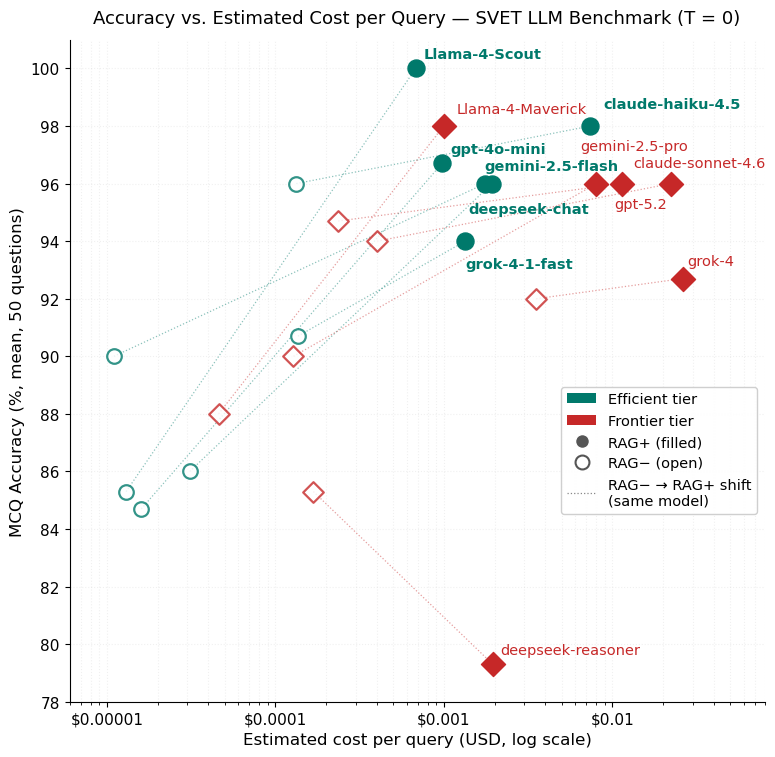

Saved: accuracy_vs_cost_SVET.png


In [153]:
"""
Accuracy vs. Estimated Cost per Query — SVET LLM Benchmark (T = 0)
===================================================================
Same visual grammar as the latency figure:
  - filled marker = RAG+, open marker = RAG−
  - dotted connector = RAG− → RAG+ shift for the same model
  - blue/teal = Efficient tier, red = Frontier tier
  - log-scale x-axis (cost spans ~4 orders of magnitude)

Cost source: per-query estimates from token counts × provider pricing.
grok-4 cost is estimated (no confirmed static pricing page).
Embedding cost excluded (not in CSVs; negligible vs. RAG context injection cost).
Llama-4-Maverick / gpt-oss-120b excluded (cost exists but accuracy slot ambiguous).
"""

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.ticker

# ── DATA ──────────────────────────────────────────────────────────────────────
# (tier, cost_RAGminus_USD, cost_RAGplus_USD, acc_RAGminus, acc_RAGplus)
models = {
    "gpt-4o-mini"      : ("Efficient", 0.000016, 0.000975,  84.7,  96.7),
    "gpt-5.2"          : ("Frontier",  0.000236, 0.011417,  94.7,  96.0),
    "gemini-2.5-flash" : ("Efficient", 0.000031, 0.001927,  86.0,  96.0),
    "gemini-2.5-pro"   : ("Frontier",  0.000128, 0.008030,  90.0,  96.0),
    "grok-4-1-fast"    : ("Efficient", 0.000136, 0.001337,  90.7,  94.0),
    "grok-4"          : ("Frontier",  0.003529, 0.026133,  92.0,  92.7),
    "deepseek-chat"    : ("Efficient", 0.000011, 0.001754,  90.0,  96.0),
    "deepseek-reasoner": ("Frontier",  0.000168, 0.001949,  85.3,  79.3),
    "Llama-4-Scout"    : ("Efficient", 0.000013, 0.000680,  85.3, 100.0),
    "Llama-4-Maverick" : ("Frontier",  0.000046, 0.000997,  88.0,  98.0),
    "claude-haiku-4.5" : ("Efficient", 0.000133, 0.007399,  96.0,  98.0),
    "claude-sonnet-4.6": ("Frontier",  0.000402, 0.022200,  94.0,  96.0),
}

COLOR  = {"Efficient": "#00796B", "Frontier": "#C62828"}
MARKER = {"Efficient": "o",       "Frontier": "D"}

# Nudges: (x_multiplier, dy) — tuned for log-scale x-axis
NUDGE = {
    "gpt-4o-mini"      : (1.12,  0.50),
    "gpt-5.2"          : (0.9, -0.70),
    "gemini-2.5-flash" : (0.9,  0.6),
    "gemini-2.5-pro"   : (0.8,  1.3),
    "grok-4-1-fast"    : (1, -0.8),
    "grok-4"          : (1.06,  0.6),
    "deepseek-chat"    : (0.8, -0.9),
    "deepseek-reasoner": (1.10,  0.50),
    "Llama-4-Scout"    : (1.12,  0.50),
    "Llama-4-Maverick" : (1.20, 0.6),
    "claude-haiku-4.5" : (1.20, 0.75),
    "claude-sonnet-4.6": (0.6,  0.70),
}

# ── FIGURE ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 8))

for name, (tier, cost_m, cost_p, acc_m, acc_p) in models.items():
    c  = COLOR[tier]
    mk = MARKER[tier]
    x_mult, dy = NUDGE[name]

    # Dotted connector
    ax.plot([cost_m, cost_p], [acc_m, acc_p],
            color=c, lw=0.9, ls=":", alpha=0.45, zorder=2)

    # RAG− open marker
    ax.scatter(cost_m, acc_m, marker=mk, s=110,
               edgecolors=c, facecolors="white",
               linewidths=1.6, zorder=3, alpha=0.80)

    # RAG+ filled marker
    ax.scatter(cost_p, acc_p, marker=mk, s=150,
               color=c, zorder=4)

    # Label at RAG+ point
    ax.text(cost_p * x_mult, acc_p + dy, name,
            fontsize=10.5, color=c,
            fontweight="bold" if tier == "Efficient" else "normal",
            va="center")

# ── LOG SCALE ─────────────────────────────────────────────────────────────────
ax.set_xscale("log")
ax.set_xlim(6e-6, 8e-2)
ax.set_xticks([1e-5, 1e-4, 1e-3, 1e-2])
ax.get_xaxis().set_major_formatter(
    matplotlib.ticker.FuncFormatter(
        lambda x, _: {1e-5: "$0.00001", 1e-4: "$0.0001",
                      1e-3: "$0.001",   1e-2: "$0.01"}[x]
    )
)

# ── LEGEND ────────────────────────────────────────────────────────────────────
leg = [
    mpatches.Patch(facecolor=COLOR["Efficient"], label="Efficient tier"),
    mpatches.Patch(facecolor=COLOR["Frontier"],  label="Frontier tier"),
    mlines.Line2D([], [], marker="o", color="w",
                  markerfacecolor="#555", markersize=10, label="RAG+ (filled)"),
    mlines.Line2D([], [], marker="o", color="w",
                  markerfacecolor="white", markeredgecolor="#555",
                  markeredgewidth=1.5, markersize=10, label="RAG− (open)"),
    mlines.Line2D([], [], color="#888", lw=0.9, ls=":",
                  label="RAG− → RAG+ shift\n(same model)"),
]
ax.legend(handles=leg, fontsize=10.5,
          loc="center right", bbox_to_anchor=(1.00, 0.38),
          framealpha=0.93, edgecolor="#ccc")

# ── AXES ──────────────────────────────────────────────────────────────────────
ax.set_xlabel("Estimated cost per query (USD, log scale)", fontsize=12)
ax.set_ylabel("MCQ Accuracy (%, mean, 50 questions)", fontsize=12)
ax.set_title("Accuracy vs. Estimated Cost per Query — SVET LLM Benchmark (T = 0)",
             fontsize=13, pad=12)
ax.set_ylim(78, 101)
ax.set_yticks(range(78, 101, 2))
ax.tick_params(axis='both', labelsize=11)
ax.grid(True, alpha=0.18, linestyle=":", which="both")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig("accuracy_vs_cost_SVET.png", dpi=180, bbox_inches="tight")
plt.show()
print("Saved: accuracy_vs_cost_SVET.png")

*llama scout rag+ aggregated results file was not stored correctly (rerunned below)

In [51]:
LLAMA_MODEL = "meta-llama/Llama-4-Scout-17B-16E-Instruct"

In [47]:
from pathlib import Path

BASE_DIR = Path(r"C:\Users\Admin\OneDrive - Université Libre de Bruxelles\Leo\Insta\UMONS\svet paper\part I files")

LLAMA_PLUS_PATH  = BASE_DIR / "results_llama_Llama-4-Scout-17B-16E-Instruct_T0_RAGplus.csv"
LLAMA_MINUS_PATH = BASE_DIR / "results_llama_Llama-4-Scout-17B-16E-Instruct_T0_RAGminus.csv"

In [49]:
def summarize(df, label):
    accs = df.groupby("run_number")["is_correct"].mean().values * 100
    return {
        "condition": label,
        "mean"     : accs.mean(),
        "std"      : accs.std(ddof=1),
        "run_accs" : [round(a, 1) for a in accs]
    }

In [56]:
df_llama_minus = pd.read_csv(LLAMA_MINUS_PATH)
df_llama_plus  = pd.read_csv(LLAMA_PLUS_PATH)

r_minus = summarize(df_llama_minus, "RAG−")
r_plus  = summarize(df_llama_plus,  "RAG+")
delta   = r_plus["mean"] - r_minus["mean"]

print(f"{'='*50}")
print(f"Model     : {LLAMA_MODEL}")
print(f"Temp      : {0} | N=3 | top_k={10} | threshold={0.3}")
print(f"{'─'*50}")
print(f"{'Condition':<10} {'Mean':>6}  {'±SD':>6}  {'Per-run':>22}")
print(f"{'─'*50}")
for r in [r_minus, r_plus]:
    print(f"{r['condition']:<10} {r['mean']:>5.1f}%  "
          f"±{r['std']:>4.1f}%  {str(r['run_accs']):>22}")
print(f"{'─'*50}")
print(f"{'Δ RAG':<10} {delta:>+5.1f} pp")
print(f"{'='*50}")

q_minus  = df_llama_minus.groupby("question_id")["is_correct"].mean()
q_plus   = df_llama_plus.groupby("question_id") ["is_correct"].mean()
q_delta  = (q_plus - q_minus).reset_index()
q_delta.columns = ["question_id", "delta"]

improved  = q_delta[q_delta["delta"] >  0]
degraded  = q_delta[q_delta["delta"] <  0]
unchanged = q_delta[q_delta["delta"] == 0]

print(f"\n─── Per-question RAG impact ─────────────────")
print(f"Improved  (+) : {len(improved):>2}  Qs → {sorted(improved['question_id'].tolist())}")
print(f"Degraded  (−) : {len(degraded):>2}  Qs → {sorted(degraded['question_id'].tolist())}")
print(f"Unchanged (=) : {len(unchanged):>2}  Qs")

print(f"\n─── Master table rows ───────────────────────")
for r in [r_minus, r_plus]:
    print(f"| {LLAMA_MODEL.split('/')[-1]} | {r['condition']} | {0} | 3 | "
          f"{r['mean']:.1f}% ± {r['std']:.1f}% |")

Model     : meta-llama/Llama-4-Scout-17B-16E-Instruct
Temp      : 0 | N=3 | top_k=10 | threshold=0.3
──────────────────────────────────────────────────
Condition    Mean     ±SD                 Per-run
──────────────────────────────────────────────────
RAG−        85.3%  ± 1.2%  [np.float64(86.0), np.float64(86.0), np.float64(84.0)]
RAG+       100.0%  ± 0.0%  [np.float64(100.0), np.float64(100.0), np.float64(100.0)]
──────────────────────────────────────────────────
Δ RAG      +14.7 pp

─── Per-question RAG impact ─────────────────
Improved  (+) :  9  Qs → [3, 12, 17, 19, 28, 36, 41, 43, 45]
Degraded  (−) :  0  Qs → []
Unchanged (=) : 41  Qs

─── Master table rows ───────────────────────
| Llama-4-Scout-17B-16E-Instruct | RAG− | 0 | 3 | 85.3% ± 1.2% |
| Llama-4-Scout-17B-16E-Instruct | RAG+ | 0 | 3 | 100.0% ± 0.0% |
